# HFHI / Adaptation Fund — SIG, télédétection et aide à la décision
## Jacqueville – Grand-Bassam, Côte d'Ivoire

**Notebook maître — collecte, préparation, analyses, cartographie, graphiques et exports**

Ce notebook structure la contribution SIG/télédétection à l'étude d'aide à la décision sur les **opportunités de moyens de subsistance résilients** dans les 10 communautés ciblées par les TDR.

### Questions opérationnelles couvertes

1. Où sont les communautés et quels sont leurs contextes spatiaux ?
2. Quelle est l'occupation/couverture du sol récente ?
3. Où la pression foncière et les contraintes biophysiques sont-elles les plus fortes ?
4. Quels espaces sont **potentiellement mobilisables sur le plan spatial/biophysique** ?
5. Où se trouvent les zones humides/mangroves potentielles et quelles dynamiques observe-t-on ?
6. Quelles zones sont davantage exposées aux inondations et aux dynamiques de l'eau ?
7. Quelles tendances climatiques (pluie/température) sont pertinentes pour les moyens de subsistance ?
8. Quelle est l'accessibilité routière et commerciale ?
9. Où les options de moyens de subsistance paraissent-elles spatialement les plus favorables ?
10. Comment prioriser les communautés/sites pour les vérifications de terrain et la matrice d'opportunités ?

> **Important :** ce notebook est un outil de **screening spatial et d'aide à la décision**. Il ne remplace pas les procédures cadastrales, juridiques, environnementales ou hydrauliques formelles.

## 0. Architecture méthodologique

Le compromis retenu est :

- **Google Earth Engine + geemap** pour les gros volumes raster, séries temporelles et composites satellitaires ;
- **GeoPandas/Shapely** pour les données vectorielles, buffers, contrôles géométriques et sorties SIG ;
- **OSMnx/NetworkX** pour OpenStreetMap, les réseaux routiers et les temps/distances d'accès ;
- **Matplotlib** pour les figures reproductibles du rapport ;
- **GeoPackage / GeoJSON / GeoTIFF / CSV** pour assurer l'interopérabilité avec QGIS/ArcGIS ;
- **UTM 30N (EPSG:32630)** pour les distances/surfaces métriques ; **WGS84 (EPSG:4326)** pour les échanges web/GEE ;
- données brutes conservées séparément des données intermédiaires et finales.

### Niveau de preuve

Chaque résultat doit être classé comme :
- **observé** : données de terrain / données administratives ou projet validées ;
- **estimé** : produit dérivé d'une source documentée ;
- **proxy** : approximation spatiale à confirmer ;
- **à valider** : hypothèse non suffisante pour une décision d'investissement.

Les cartes de disponibilité foncière, mangrove et inondation produites ici doivent être présentées comme des **screenings**, sauf si des données officielles supplémentaires sont intégrées.

## Correspondance directe avec les livrables des TDR

Le workflow est organisé pour alimenter les quatre livrables de la mission :

| Livrable | Échéance TDR | Contribution SIG/télédétection |
|---|---:|---|
| **L1 — Note de cadrage, méthodologie, outils de collecte, grille d'analyse et plan de travail** | Fin S1 | AOI, protocole GPS, inventaire des données, méthode GEE/OSM/MCE, critères et limites |
| **L2 — Note de faisabilité foncière ciblée** | Fin S3 | occupation du sol, contraintes spatiales, potentiel biophysique à investiguer, accessibilité, risques, fiches/sites terrain |
| **L3 — Matrice opérationnelle des opportunités** | Fin S5 | scores spatiaux, surfaces favorables, résilience climatique, accès, sensibilité écosystémique, niveau de confiance |
| **L4 — Rapport final et PPT** | Fin S6 | atlas, graphiques, tableaux, synthèse des priorités, limites, recommandations |

### Séquençage recommandé

- **S1 :** cadrage, validation des localités, AOI, collecte des données, formulaires terrain ;
- **S2 :** Sentinel-2, occupation du sol, OSM, préparation du terrain ;
- **S2–S3 :** terrain et screening foncier spatial ;
- **S3–S4 :** eau, mangroves, inondation, climat, accessibilité ;
- **S4–S5 :** analyses multicritères et matrice spatiale ;
- **S5–S6 :** validation, analyse de sensibilité, exports, rédaction et atlas.

## Journal des modifications (revue du 2026-09-03)

Corrections et compléments apportés à ce notebook :

1. **Section 15 (distance aux marchés/routes)** : `geemap.gdf_to_ee()` sur une couche de points levait
   `Unrecognized arguments {'geodesic'} to function: GeometryConstructors.MultiPoint` avec les versions
   récentes de l'API Earth Engine. Remplacé par une construction directe `ee.Geometry.MultiPoint(...)`
   (nouvelle fonction `points_gdf_to_ee_fc`), réutilisée aussi pour la couche ressources coco (17.1).
2. **Section 18 (scores moyens par communauté)** : le calcul enchaînait cinq `.map()` imbriqués avant un
   unique `getInfo()`, ce qui provoquait `EEException: Computation timed out`. Remplacé par un
   `reduceRegions()` par image (traitement batch natif, beaucoup plus léger côté serveur), avec repli
   automatique (échelle/`tileScale` ajustés) en cas de nouvel échec.
3. **Section 22 (échantillonnage de validation)** : généralisé de l'exemple unique (maraîchage, en
   commentaire) à une fonction couvrant l'ensemble des options d'aptitude, avec export systématique en
   GeoPackage par option.
4. **Section 26 (analyse de sensibilité des poids)** : la fonction générique était préparée mais jamais
   appliquée. Complétée par `sensitivity_for_option()`, qui perturbe les poids (±15 % par défaut),
   recalcule le score par communauté pour chaque scénario et mesure la stabilité du classement
   (corrélation de rang de Spearman) — disponible pour les 5 options.
5. **Nouvelle Partie F bis — Rédaction assistée des résultats** : génère automatiquement, à partir des
   tables déjà calculées plus haut dans le notebook, un premier jet de texte de résultats en français,
   exporté vers `04_report/sections/resultats_SIG_redaction_auto.md`.

> **Non ré-exécuté dans cet environnement de revue.** Ce notebook nécessite une authentification Google
> Earth Engine valide, les données terrain/vecteurs listées en section 4, et un accès réseau à
> `earthengine.googleapis.com` / OpenStreetMap — indisponibles ici. Les corrections ci-dessus ont donc
> été établies **par lecture du code et des messages d'erreur déjà enregistrés dans les sorties du
> fichier d'origine**, pas par ré-exécution bout en bout. Relancer l'ensemble du notebook dans votre
> environnement habituel (Colab ou poste local avec identifiants EE) avant de considérer les résultats
> comme définitifs, et avant de vous fier au texte généré par la Partie F bis.

## 1. Installation de l'environnement

Pour un environnement local, privilégier **Python 3.11 ou 3.12** et un environnement conda/mamba dédié.

Décommenter et exécuter la cellule suivante si nécessaire. Dans Google Colab, `earthengine-api` est généralement déjà installé, mais les autres bibliothèques peuvent devoir être ajoutées.

In [1]:
# Installation optionnelle — décommenter si nécessaire.
# ! pip install -U \
#   earthengine-api geemap geopandas pyogrio shapely rasterio rioxarray xarray \
#   osmnx networkx scipy scikit-learn pandas numpy matplotlib folium mapclassify \
#   openpyxl pyyaml python-dotenv tqdm --quiet

In [2]:
! pip install SciencePlots --quiet

In [3]:
# ! pip install "numpy<2.3" scipy --upgrade --force-reinstall --quiet


In [1]:
from __future__ import annotations

import os
import sys
import json
import math
import shutil
import warnings
import platform
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from shapely.geometry import Point, Polygon, MultiPolygon
from shapely.ops import unary_union
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)

try:
    import ee
    import geemap
except ImportError:
    ee = None
    geemap = None

try:
    import osmnx as ox
    import networkx as nx
except ImportError:
    ox = None
    nx = None

print("Python :", sys.version.split()[0])
print("Plateforme :", platform.platform())
print("GeoPandas :", gpd.__version__)
print("Pandas :", pd.__version__)
print("NumPy :", np.__version__)
if ee is not None:
    print("Earth Engine API :", getattr(ee, "__version__", "inconnu"))
if geemap is not None:
    print("geemap :", getattr(geemap, "__version__", "inconnu"))
if ox is not None:
    print("OSMnx :", getattr(ox, "__version__", "inconnu"))

Python : 3.12.13
Plateforme : Windows-11-10.0.26200-SP0
GeoPandas : 1.1.3
Pandas : 3.0.2
NumPy : 2.4.4
Earth Engine API : 1.7.22
geemap : 0.37.2
OSMnx : 2.1.1


## 2. Configuration générale

Modifier en priorité :

- `EE_PROJECT` : identifiant du projet Google Cloud autorisé pour Earth Engine ;
- les dates d'analyse ;
- les rayons de contexte et statistiques ;
- les seuils de screening si les données terrain conduisent à les ajuster.

Ne jamais stocker de secrets dans le notebook. Utiliser des variables d'environnement ou un fichier `.env` non versionné.

In [2]:
PROJECT_NAME = "HFHI_resilience_cotiere_SIG"
CURRENT = Path.cwd()

# Si le notebook est lance depuis le dossier projet, on le conserve.
# Sinon, un sous-dossier projet est cree.
ROOT = CURRENT if CURRENT.name == PROJECT_NAME else CURRENT / PROJECT_NAME

WGS84 = "EPSG:4326"
METRIC_CRS = "EPSG:32630"  # UTM 30N, adapte a Jacqueville / Grand-Bassam

# Chargement optionnel d'un fichier .env (racine du dossier de travail ou son parent),
# sans dependance externe. Une variable deja presente dans l'environnement systeme
# garde la priorite (setdefault).
for _env_path in (CURRENT / ".env", CURRENT.parent / ".env"):
    if _env_path.exists():
        for _line in _env_path.read_text(encoding="utf-8").splitlines():
            _line = _line.strip()
            if _line and not _line.startswith("#") and "=" in _line:
                _k, _, _v = _line.partition("=")
                os.environ.setdefault(_k.strip(), _v.strip())
        break

# Earth Engine : renseigne via variable d'environnement EE_PROJECT (ou fichier .env ci-dessus)
EE_PROJECT = os.getenv("EE_PROJECT", "CHANGE_ME_WITH_YOUR_GCP_PROJECT")

TODAY = pd.Timestamp.utcnow().date()
END_DATE = TODAY.isoformat()
LAST_COMPLETE_YEAR = TODAY.year - 1

# Periodes principales
S2_RECENT_START = "2024-01-01"
S2_BASELINE_START = "2017-01-01"
S2_BASELINE_END = "2019-12-31"

CLIMATE_START = "1991-01-01"
CLIMATE_BASELINE_END = "2020-12-31"

# Emprises
COMMUNITY_CONTEXT_BUFFER_KM = 7.5
COMMUNITY_STATS_BUFFER_KM = 3.0
ZONE_CONTEXT_BUFFER_KM = 5.0

# GEE / imagerie
CLOUD_QA_BAND = "cs_cdf"
CLOUD_CLEAR_THRESHOLD = 0.60
REPORT_RASTER_SCALE_M = 20
DEM_SCALE_M = 30

# Cartographie
FIG_DPI = 220
MAP_FIGSIZE = (11, 8)

print("Racine du projet :", ROOT)
print("Projet Earth Engine (EE_PROJECT) :", EE_PROJECT)
print("Date de fin d'analyse :", END_DATE)
print("Derniere annee complete pour les tendances :", LAST_COMPLETE_YEAR)

Racine du projet : C:\Users\Ordinateur\OneDrive\DR NOUFOU - HFHCI - OPPORTUNITÉS DE MOYENS DE SUBSISTANCE\HFHI_resilience_cotiere_SIG
Projet Earth Engine (EE_PROJECT) : ee-kanicetcyrille
Date de fin d'analyse : 2026-08-31
Derniere annee complete pour les tendances : 2025


C:\Users\Ordinateur\AppData\Local\Temp\ipykernel_63352\896154449.py:26: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  TODAY = pd.Timestamp.utcnow().date()


In [3]:
FOLDERS = {
    "config": ROOT / "00_config",
    "raw_vectors": ROOT / "01_data" / "raw" / "vectors",
    "raw_rasters": ROOT / "01_data" / "raw" / "rasters",
    "raw_field": ROOT / "01_data" / "raw" / "field",
    "raw_osm": ROOT / "01_data" / "raw" / "osm",
    "interim": ROOT / "01_data" / "interim",
    "processed": ROOT / "01_data" / "processed",
    "notebooks": ROOT / "02_notebooks",
    "maps": ROOT / "03_outputs" / "maps",
    "figures": ROOT / "03_outputs" / "figures",
    "tables": ROOT / "03_outputs" / "tables",
    "gis": ROOT / "03_outputs" / "gis",
    "gee_exports": ROOT / "03_outputs" / "gee_exports",
    "report_sections": ROOT / "04_report" / "sections",
    "report_annexes": ROOT / "04_report" / "annexes",
    "logs": ROOT / "05_logs",
}

for folder in FOLDERS.values():
    folder.mkdir(parents=True, exist_ok=True)

for key, value in FOLDERS.items():
    print(f"{key:16s} -> {value}")

config           -> C:\Users\Ordinateur\OneDrive\DR NOUFOU - HFHCI - OPPORTUNITÉS DE MOYENS DE SUBSISTANCE\HFHI_resilience_cotiere_SIG\00_config
raw_vectors      -> C:\Users\Ordinateur\OneDrive\DR NOUFOU - HFHCI - OPPORTUNITÉS DE MOYENS DE SUBSISTANCE\HFHI_resilience_cotiere_SIG\01_data\raw\vectors
raw_rasters      -> C:\Users\Ordinateur\OneDrive\DR NOUFOU - HFHCI - OPPORTUNITÉS DE MOYENS DE SUBSISTANCE\HFHI_resilience_cotiere_SIG\01_data\raw\rasters
raw_field        -> C:\Users\Ordinateur\OneDrive\DR NOUFOU - HFHCI - OPPORTUNITÉS DE MOYENS DE SUBSISTANCE\HFHI_resilience_cotiere_SIG\01_data\raw\field
raw_osm          -> C:\Users\Ordinateur\OneDrive\DR NOUFOU - HFHCI - OPPORTUNITÉS DE MOYENS DE SUBSISTANCE\HFHI_resilience_cotiere_SIG\01_data\raw\osm
interim          -> C:\Users\Ordinateur\OneDrive\DR NOUFOU - HFHCI - OPPORTUNITÉS DE MOYENS DE SUBSISTANCE\HFHI_resilience_cotiere_SIG\01_data\interim
processed        -> C:\Users\Ordinateur\OneDrive\DR NOUFOU - HFHCI - OPPORTUNITÉS DE MOYEN

### Arborescence produite

```text
HFHI_resilience_cotiere_SIG/
├── 00_config/
├── 01_data/
│   ├── raw/
│   │   ├── vectors/
│   │   ├── rasters/
│   │   ├── field/
│   │   └── osm/
│   ├── interim/
│   └── processed/
├── 02_notebooks/
├── 03_outputs/
│   ├── maps/
│   ├── figures/
│   ├── tables/
│   ├── gis/
│   └── gee_exports/
├── 04_report/
│   ├── sections/
│   └── annexes/
└── 05_logs/
```

**Règle :** ne jamais modifier les données de `01_data/raw`. Toute correction passe par `interim` ou `processed`.

In [4]:
# =====================================================================
# Mise en forme "Nature" des figures + helper de rendu statique des cartes
# ---------------------------------------------------------------------
# Largeurs normalisees Nature : 1 colonne = 89 mm (3.50 in),
# 2 colonnes = 183 mm (7.20 in), hauteur max = 247 mm (9.72 in).
import io
import re
import math
import urllib.request

import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

try:
    import scienceplots  # noqa: F401  (installe via `pip install SciencePlots`)
    plt.style.use(["science", "nature", "no-latex"])
    _NATURE_STYLE = "scienceplots:nature"
except Exception as _e:  # repli sans dependance
    _NATURE_STYLE = "manual-nature"
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "TeX Gyre Heros", "DejaVu Sans"],
        "mathtext.fontset": "dejavusans",
        "axes.prop_cycle": plt.cycler(
            color=["#0C5DA5", "#00B945", "#FF9500", "#FF2C00",
                   "#845B97", "#474747", "#9e9e9e"]),
    })

# Reglages imposes dans tous les cas (dimensions, polices, traits fins Nature)
plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
    "font.size": 7,
    "axes.titlesize": 8,
    "axes.labelsize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6,
    "legend.frameon": False,
    "axes.linewidth": 0.5,
    "grid.linewidth": 0.4,
    "lines.linewidth": 1.0,
    "lines.markersize": 3,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "xtick.major.size": 2.5,
    "ytick.major.size": 2.5,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# Dimensions reutilisables (pouces)
NATURE_COL1      = (3.50, 2.60)   # simple colonne
NATURE_COL1_5    = (4.75, 3.60)   # colonne et demie (cartes statiques)
NATURE_COL2      = (7.20, 4.50)   # double colonne
NATURE_COL2_TALL = (7.20, 6.20)   # double colonne, matrice / heatmap

# On aligne les parametres du notebook sur la norme Nature
FIG_DPI = 300
MAP_FIGSIZE = (7.20, 6.20)

print("Style figures :", _NATURE_STYLE, "| FIG_DPI =", FIG_DPI)


def _slug(txt):
    return re.sub(r"[^a-z0-9]+", "_", str(txt).lower()).strip("_") or "couche"


def _ee_bbox(region_geom):
    ring = ee.Geometry(region_geom).bounds().coordinates().getInfo()[0]
    xs = [p[0] for p in ring]
    ys = [p[1] for p in ring]
    return min(xs), min(ys), max(xs), max(ys)  # w, s, e, n


def _nice_scale_km(width_km):
    """Longueur ronde (km) pour la barre d'echelle, environ 1/4 de la largeur de la carte."""
    target = width_km / 4
    for step in (0.5, 1, 2, 5, 10, 20, 25, 50, 100, 200, 250, 500, 1000):
        if step >= target:
            return step
    return 1000


def _fit_figsize(w, s, e, n, base_width=NATURE_COL1_5[0], min_h=2.4, max_h=5.5):
    """Hauteur de figure adaptee au rapport largeur/hauteur reel (km) de l'emprise,
    pour eviter le vide genere par une figure carree forcee sur une emprise tres
    allongee (ex. Jacqueville + Grand-Bassam, ~70 km l'un de l'autre)."""
    lat_mid = (s + n) / 2
    km_per_deg_lon = 111.320 * math.cos(math.radians(lat_mid))
    width_km = max((e - w) * km_per_deg_lon, 1e-6)
    height_km = (n - s) * 111.320
    h = base_width * (height_km / width_km)
    return (base_width, min(max(h, min_h), max_h))


def add_scalebar_geo(ax, lat_deg, right_margin=0.04, bottom_margin=0.06, fontsize=5):
    """Barre d'echelle pour des axes en degres lon/lat (add_scalebar suppose des axes
    metriques). Longueur choisie automatiquement et convertie en degres via la
    distance reelle a la latitude de la carte, ancree en bas a droite pour ne pas
    chevaucher la legende (en bas a gauche)."""
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
    km_per_deg_lon = 111.320 * math.cos(math.radians(lat_deg))
    width_km = (xlim[1] - xlim[0]) * km_per_deg_lon
    length_km = _nice_scale_km(width_km)
    length_deg = length_km / km_per_deg_lon if km_per_deg_lon > 0 else 0
    x1 = xlim[1] - (xlim[1] - xlim[0]) * right_margin
    x0 = x1 - length_deg
    y0 = ylim[0] + (ylim[1] - ylim[0]) * bottom_margin
    ax.plot([x0, x1], [y0, y0], color="black", lw=2, solid_capstyle="butt", zorder=6)
    ax.text((x0 + x1) / 2, y0 + (ylim[1] - ylim[0]) * 0.015, f"{length_km:g} km",
            ha="center", va="bottom", fontsize=fontsize, zorder=6)


def render_static_ee_map(layers, region_geom, title, out_png, points=None,
                         dims=1400, **_ignored):
    """Rendu statique des cartes Earth Engine : UNE couche = UNE figure.

    layers : liste de tuples (ee.Image, vis_params | None, libelle[, cat_labels]).
      - vis_params None            -> image deja visualisable (ex. .style()).
      - palette + min/max continus -> barre de couleur continue.
      - palette + min/max entiers  -> barre de couleur discrete (classes).
      - cat_labels (4e element)     -> etiquettes des classes sur la barre.
      - palette seule (couche masquee) -> vignette de legende monochrome.
      - bands (composite RGB)      -> mention RGB dans la legende.
    Chaque figure porte : titre, axes lon/lat avec graticule leger, fleche nord,
    barre d'echelle, legende des localites, et la legende propre a la couche.
    Retourne la liste des PNG ecrits.
    """
    if ee is None:
        print("Earth Engine indisponible : rendu statique ignore.")
        return []

    w, s, e, n = _ee_bbox(region_geom)
    region = ee.Geometry.BBox(w, s, e, n)
    lat_mid = (s + n) / 2
    figsize = _fit_figsize(w, s, e, n)
    pts = points.to_crs(WGS84) if points is not None else None
    out_png = Path(out_png)
    out_png.parent.mkdir(parents=True, exist_ok=True)
    multi = len(layers) > 1
    written = []

    for k, layer in enumerate(layers, 1):
        image, vis, label = layer[0], layer[1], layer[2]
        cat_labels = layer[3] if len(layer) > 3 else None
        vis = dict(vis) if vis else {}

        fig, ax = plt.subplots(figsize=figsize)
        try:
            vis_img = image if not vis else ee.Image(image).visualize(**vis)
            url = vis_img.getThumbURL({"region": region, "dimensions": dims,
                                       "format": "png"})
            arr = plt.imread(io.BytesIO(urllib.request.urlopen(url).read()))
            ax.imshow(arr, extent=[w, e, s, n], origin="upper")
        except Exception as exc:  # une couche qui echoue ne bloque pas les autres
            ax.text(0.5, 0.5, f"Rendu indisponible\n{exc}", ha="center",
                    va="center", fontsize=5, transform=ax.transAxes)

        ax.set_xlim(w, e)
        ax.set_ylim(s, n)
        ax.grid(True, linestyle="--", linewidth=0.3, color="0.6", alpha=0.35, zorder=1)
        add_north_arrow(ax, x=0.90, y=0.78, size=7)
        add_scalebar_geo(ax, lat_mid)

        handles = []
        if pts is not None:
            ax.scatter(pts.geometry.x, pts.geometry.y, s=7, c="red",
                       edgecolors="white", linewidths=0.3, zorder=5)
            handles.append(Line2D([0], [0], marker="o", linestyle="",
                                  markerfacecolor="red", markeredgecolor="white",
                                  markersize=4, label="Localites (n=10)"))

        pal = vis.get("palette")
        has_range = ("min" in vis) and ("max" in vis)
        if pal and isinstance(pal, (list, tuple)) and len(pal) > 1 and has_range:
            pal_hex = ["#" + str(c).lstrip("#") for c in pal]
            vmin, vmax = float(vis["min"]), float(vis["max"])
            discrete = cat_labels is not None or (
                float(vmax - vmin + 1) == len(pal_hex) and vmax <= 12)
            if discrete:
                cmap = mcolors.ListedColormap(pal_hex)
                norm = mcolors.BoundaryNorm(np.arange(len(pal_hex) + 1) - 0.5, cmap.N)
                sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
                cb = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.03,
                                  ticks=range(len(pal_hex)))
                cb.ax.set_yticklabels(
                    list(cat_labels) if cat_labels else
                    [str(int(vmin + t)) for t in range(len(pal_hex))],
                    fontsize=5)
            else:
                cmap = mcolors.LinearSegmentedColormap.from_list("vis", pal_hex)
                sm = plt.cm.ScalarMappable(
                    cmap=cmap, norm=mcolors.Normalize(vmin=vmin, vmax=vmax))
                cb = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.03)
            cb.set_label(label, fontsize=6)
            cb.ax.tick_params(labelsize=5)
        elif pal:
            handles.append(Patch(facecolor="#" + str(pal[0]).lstrip("#"),
                                 edgecolor="none", label=label))
        elif "bands" in vis:
            handles.append(Patch(facecolor="none", edgecolor="none",
                                 label="Composite RGB = " + "/".join(vis["bands"])))
        else:
            handles.append(Patch(facecolor="none", edgecolor="0.3", label=label))

        if handles:
            ax.legend(handles=handles, loc="lower left", fontsize=5,
                      frameon=True, framealpha=0.85)

        ax.set_title(f"{title}\n{label}" if multi else title, fontsize=8)
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        ax.tick_params(labelsize=5)
        ax.set_aspect("equal")
        fig.text(0.005, 0.005,
                 f"{PROJECT_NAME} | Google Earth Engine | CRS {WGS84} | "
                 f"{pd.Timestamp.utcnow().date().isoformat()} | rendu de screening",
                 fontsize=4.5, color="dimgray")
        fig.tight_layout(rect=[0, 0.03, 1, 1])

        target = out_png
        if multi:
            target = out_png.with_name(
                f"{out_png.stem}_{k:02d}_{_slug(label)}{out_png.suffix}")
        fig.savefig(target, dpi=FIG_DPI, bbox_inches="tight")
        plt.show()
        written.append(target)
        print("Carte statique :", target)
    return written

Style figures : scienceplots:nature | FIG_DPI = 300


## 3. Chargement et contrôle des 10 localités cibles

Le notebook cherche d'abord le GeoJSON fourni. S'il n'est pas disponible, il utilise une table embarquée de secours.

Les coordonnées de certaines localités, notamment **Attoutou B** et **Vitré 2**, doivent être validées lors du cadrage/terrain avant toute analyse foncière fine.

In [5]:
LOCALITIES_FILENAME = "localites_cibles_HFHI_Jacqueville_Grand_Bassam.geojson"

fallback_localities = [
    {"nom_tdr":"Taboth","nom_canonique":"Taboth","zone_tdr":"Jacqueville","longitude":-4.32882,"latitude":5.25754,"niveau_confiance":"élevé"},
    {"nom_tdr":"Attoutou B","nom_canonique":"Attoutou A / Attoutou","zone_tdr":"Jacqueville","longitude":-4.57220,"latitude":5.22119,"niveau_confiance":"moyen"},
    {"nom_tdr":"Koko","nom_canonique":"Koko (Kokoh)","zone_tdr":"Jacqueville","longitude":-4.39464,"latitude":5.25817,"niveau_confiance":"élevé"},
    {"nom_tdr":"Tefredji","nom_canonique":"Téfredji","zone_tdr":"Jacqueville","longitude":-4.69807,"latitude":5.21480,"niveau_confiance":"élevé"},
    {"nom_tdr":"Tiémien","nom_canonique":"Tiémé","zone_tdr":"Jacqueville","longitude":-4.64555,"latitude":5.21895,"niveau_confiance":"élevé"},
    {"nom_tdr":"Grand Jack","nom_canonique":"Grand-Jacques","zone_tdr":"Jacqueville","longitude":-4.46753,"latitude":5.19693,"niveau_confiance":"élevé"},
    {"nom_tdr":"Quartier France","nom_canonique":"Quartier France","zone_tdr":"Grand-Bassam","longitude":-3.73680,"latitude":5.19649,"niveau_confiance":"élevé"},
    {"nom_tdr":"Mondoukou","nom_canonique":"Mondoukou","zone_tdr":"Grand-Bassam","longitude":-3.68083,"latitude":5.18688,"niveau_confiance":"élevé"},
    {"nom_tdr":"Vitré 2","nom_canonique":"Vitré Deux (Vitré II)","zone_tdr":"Grand-Bassam","longitude":-3.80025,"latitude":5.27802,"niveau_confiance":"moyen"},
    {"nom_tdr":"Azuretti","nom_canonique":"Azuretti","zone_tdr":"Grand-Bassam","longitude":-3.77938,"latitude":5.20346,"niveau_confiance":"élevé"},
]

candidates = [
    CURRENT / LOCALITIES_FILENAME,
    CURRENT / "data" / LOCALITIES_FILENAME,
    ROOT / LOCALITIES_FILENAME,
    Path("/mnt/data") / LOCALITIES_FILENAME,
    FOLDERS["raw_vectors"] / LOCALITIES_FILENAME,
]

source_geojson = next((p for p in candidates if p.exists()), None)

if source_geojson:
    localites = gpd.read_file(source_geojson)
    print("GeoJSON chargé :", source_geojson)
else:
    df_fallback = pd.DataFrame(fallback_localities)
    localites = gpd.GeoDataFrame(
        df_fallback,
        geometry=gpd.points_from_xy(df_fallback.longitude, df_fallback.latitude),
        crs=WGS84,
    )
    print("ATTENTION : utilisation des coordonnées de secours embarquées.")

if localites.crs is None:
    localites = localites.set_crs(WGS84)
else:
    localites = localites.to_crs(WGS84)

# Copie de référence dans raw
raw_localities_path = FOLDERS["raw_vectors"] / LOCALITIES_FILENAME
localites.to_file(raw_localities_path, driver="GeoJSON")

required_cols = {"nom_tdr", "zone_tdr"}
missing = required_cols - set(localites.columns)
assert not missing, f"Colonnes manquantes : {missing}"
assert len(localites) == 10, f"10 localités attendues, {len(localites)} trouvées."
assert localites.geometry.is_valid.all(), "Géométries invalides détectées."

display(localites[["nom_tdr", "nom_canonique", "zone_tdr", "niveau_confiance"]])

GeoJSON chargé : C:\Users\Ordinateur\OneDrive\DR NOUFOU - HFHCI - OPPORTUNITÉS DE MOYENS DE SUBSISTANCE\data\localites_cibles_HFHI_Jacqueville_Grand_Bassam.geojson


,nom_tdr,nom_canonique,zone_tdr,niveau_confiance
0,Taboth,Taboth,Jacqueville,élevé
1,Attoutou B,Attoutou A / Attoutou,Jacqueville,moyen
2,Koko,Koko (Kokoh),Jacqueville,élevé
3,Tefredji,Téfredji,Jacqueville,élevé
4,Tiémien,Tiémé,Jacqueville,élevé
5,Grand Jack,Grand-Jacques,Jacqueville,élevé
6,Quartier France,Quartier France,Grand-Bassam,élevé
7,Mondoukou,Mondoukou,Grand-Bassam,élevé
8,Vitré 2,Vitré Deux (Vitré II),Grand-Bassam,moyen
9,Azuretti,Azuretti,Grand-Bassam,élevé


In [6]:
# Passage en projection métrique
localites_utm = localites.to_crs(METRIC_CRS)

# Buffers statistiques par communauté
community_stats = localites_utm.copy()
community_stats["buffer_km"] = COMMUNITY_STATS_BUFFER_KM
community_stats.geometry = community_stats.geometry.buffer(COMMUNITY_STATS_BUFFER_KM * 1000)

# Buffers de contexte plus larges
community_context = localites_utm.copy()
community_context["buffer_km"] = COMMUNITY_CONTEXT_BUFFER_KM
community_context.geometry = community_context.geometry.buffer(COMMUNITY_CONTEXT_BUFFER_KM * 1000)

# Emprises par zone TDR
zones = community_context.dissolve(by="zone_tdr", as_index=False)
zones.geometry = zones.geometry.buffer(ZONE_CONTEXT_BUFFER_KM * 1000)

# Emprise régionale multipartite : ne pas prendre un grand convex hull entre les deux zones
region_geom = unary_union(zones.geometry)
region = gpd.GeoDataFrame({"name":["region_HFHI"]}, geometry=[region_geom], crs=METRIC_CRS)

aoi_gpkg = FOLDERS["processed"] / "aoi_hfhi.gpkg"
for layer_name, gdf in {
    "localites": localites_utm,
    "community_stats": community_stats,
    "community_context": community_context,
    "zones": zones,
    "region": region,
}.items():
    gdf.to_file(aoi_gpkg, layer=layer_name, driver="GPKG")

print("AOI enregistrées :", aoi_gpkg)

AOI enregistrées : C:\Users\Ordinateur\OneDrive\DR NOUFOU - HFHCI - OPPORTUNITÉS DE MOYENS DE SUBSISTANCE\HFHI_resilience_cotiere_SIG\01_data\processed\aoi_hfhi.gpkg


### 3.1 Rattachement administratif — département / sous-préfecture

Les TDR ciblent d'abord des **communautés/localités**. Pour les cartes de contexte et les tableaux, ajouter néanmoins la hiérarchie administrative :

`département → sous-préfecture → localité → site`

Le notebook n'invente pas ces rattachements. Il attend une couche officielle ou validée dans :

`01_data/raw/vectors/admin_boundaries.gpkg`

La couche doit contenir, si possible, les champs `departement` et `sous_prefecture`. À défaut, adapter les noms de colonnes avant la jointure.

In [7]:
ADMIN_FILE = FOLDERS["raw_vectors"] / "admin_boundaries.gpkg"

if ADMIN_FILE.exists():
    admin = gpd.read_file(ADMIN_FILE)
    if admin.crs is None:
        raise ValueError("La couche administrative n'a pas de CRS.")
    admin = admin.to_crs(WGS84)

    localites_admin = gpd.sjoin(
        localites.to_crs(WGS84),
        admin,
        how="left",
        predicate="within"
    )

    cols = [c for c in ["nom_tdr","zone_tdr","departement","sous_prefecture"] if c in localites_admin.columns]
    display(localites_admin[cols])

    localites_admin.to_file(
        FOLDERS["processed"] / "localites_rattachement_administratif.gpkg",
        driver="GPKG"
    )
else:
    print(
        "Couche administrative officielle non fournie. "
        "Ajouter admin_boundaries.gpkg avant la version finale du rapport."
    )

Couche administrative officielle non fournie. Ajouter admin_boundaries.gpkg avant la version finale du rapport.


C:\Users\Ordinateur\AppData\Local\Temp\ipykernel_63352\1489896467.py:36: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  f"Production : {pd.Timestamp.utcnow().date().isoformat()}"


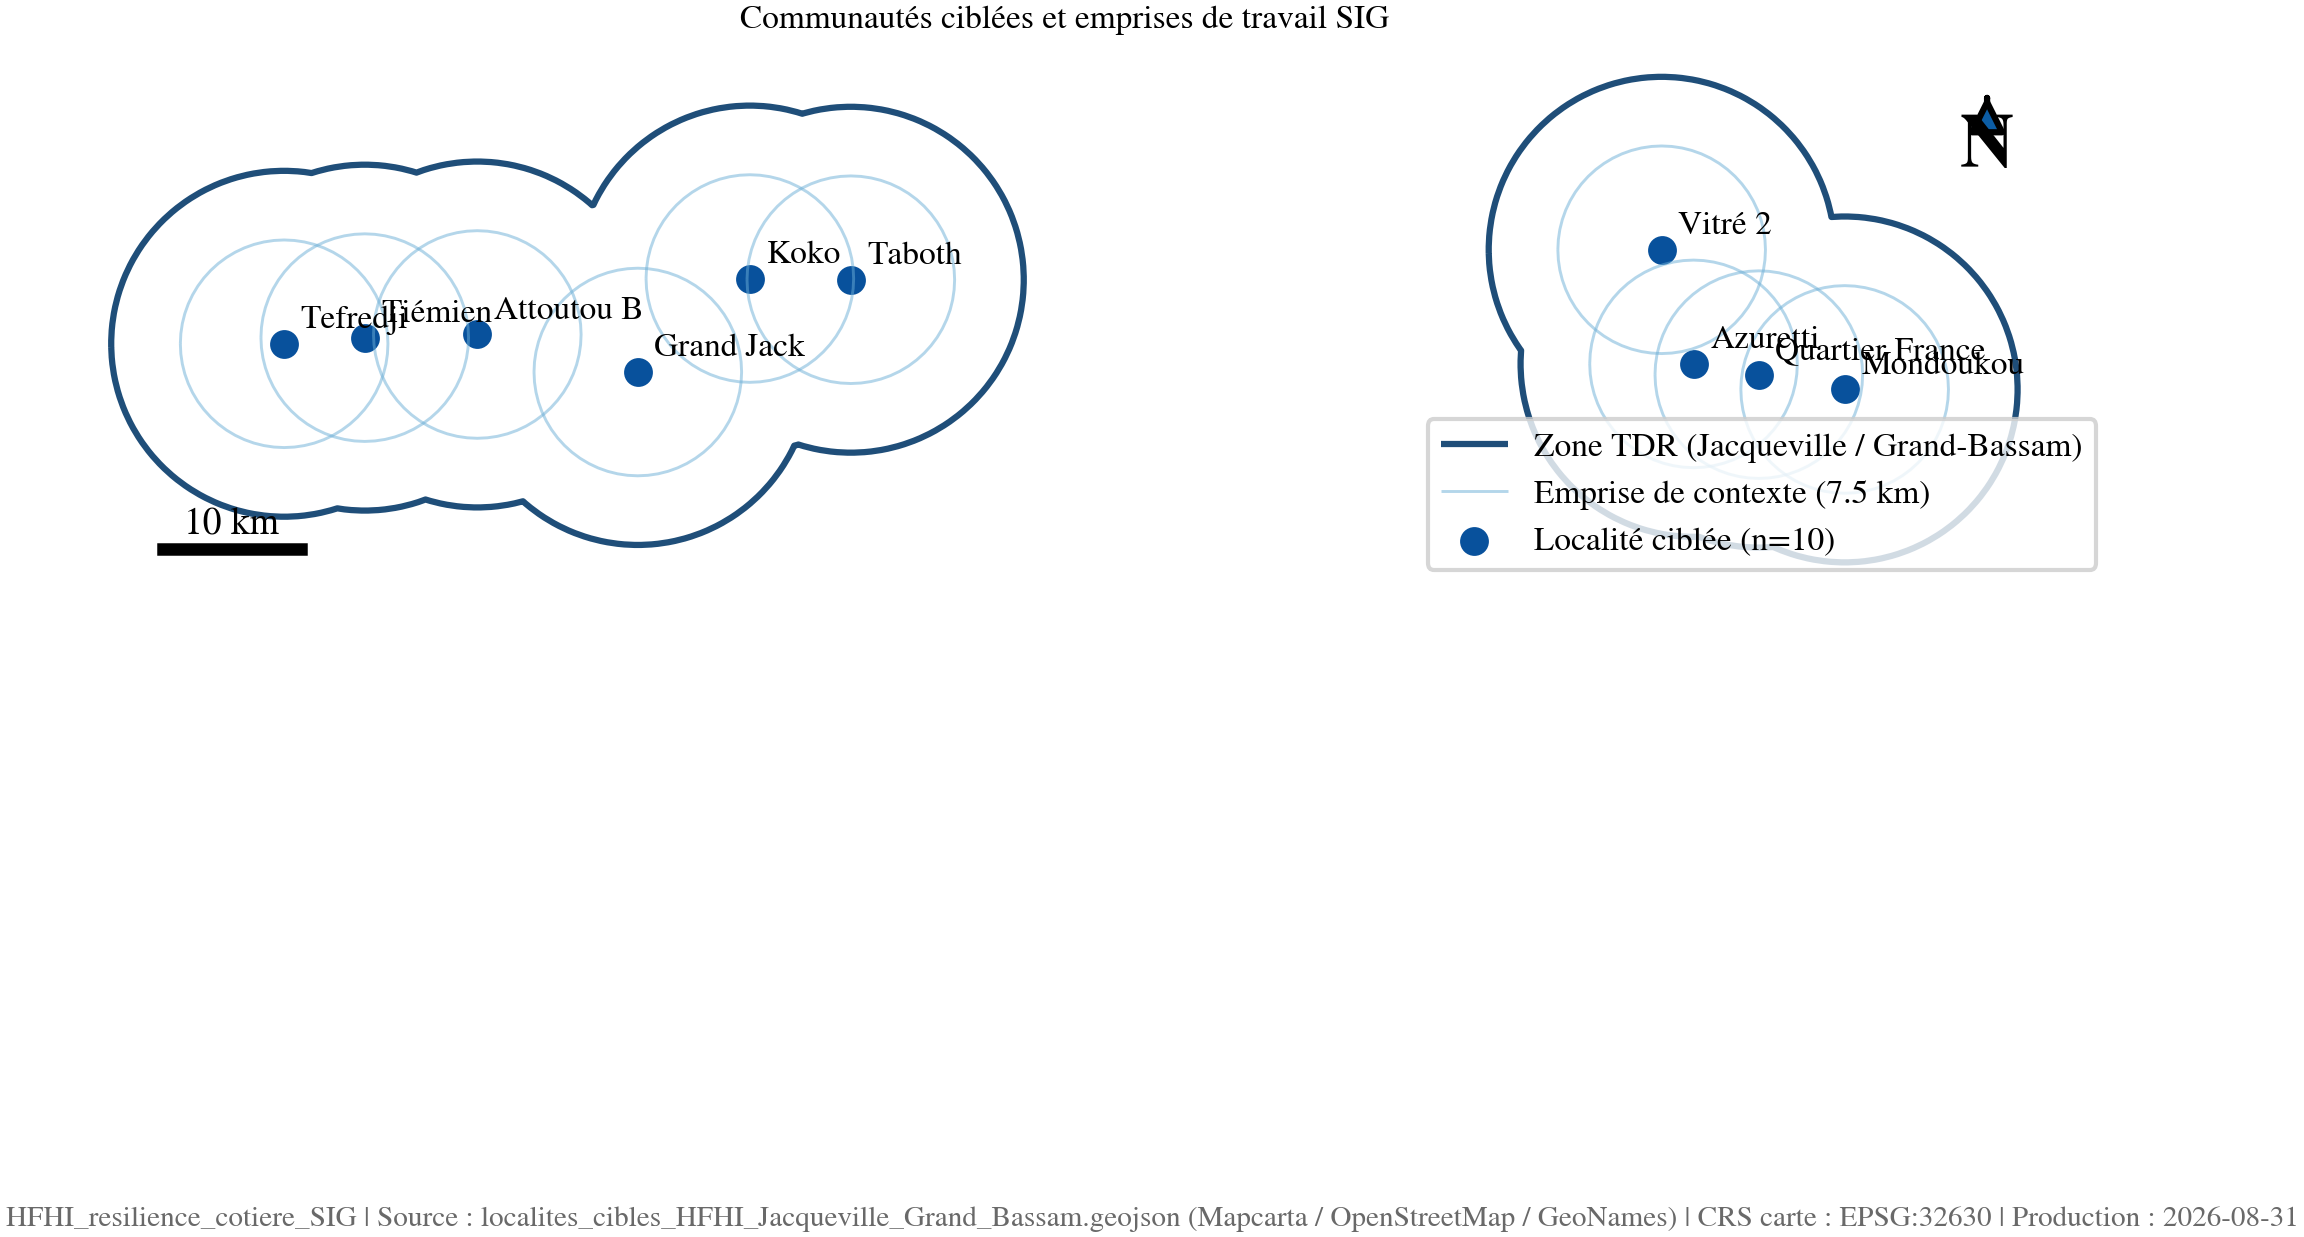

C:\Users\Ordinateur\OneDrive\DR NOUFOU - HFHCI - OPPORTUNITÉS DE MOYENS DE SUBSISTANCE\HFHI_resilience_cotiere_SIG\03_outputs\maps\01_localites_et_emprises.png


In [8]:
def add_north_arrow(ax, x=0.94, y=0.92, size=18):
    ax.annotate(
        "N", xy=(x, y), xytext=(x, y-0.10),
        xycoords="axes fraction",
        ha="center", va="center",
        fontsize=size, fontweight="bold",
        arrowprops=dict(arrowstyle="-|>", lw=1.5)
    )

def add_scalebar(ax, length_km=10, location=(0.07, 0.07)):
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    x0 = xlim[0] + (xlim[1]-xlim[0]) * location[0]
    y0 = ylim[0] + (ylim[1]-ylim[0]) * location[1]
    length_m = length_km * 1000
    ax.plot([x0, x0 + length_m], [y0, y0], color="black", lw=3)
    ax.text(x0 + length_m/2, y0 + (ylim[1]-ylim[0])*0.015,
            f"{length_km:g} km", ha="center", va="bottom", fontsize=9)

fig, ax = plt.subplots(figsize=MAP_FIGSIZE)
zones.boundary.plot(ax=ax, linewidth=1.5, color="#1f4e79", label="Zone TDR (Jacqueville / Grand-Bassam)")
community_context.boundary.plot(ax=ax, linewidth=0.7, alpha=0.5, color="#6baed6", label=f"Emprise de contexte ({COMMUNITY_CONTEXT_BUFFER_KM:g} km)")
localites_utm.plot(ax=ax, markersize=35, color="#08519c", label="Localité ciblée (n=10)")

for _, row in localites_utm.iterrows():
    ax.annotate(row["nom_tdr"], (row.geometry.x, row.geometry.y),
                xytext=(4,4), textcoords="offset points", fontsize=8)

add_north_arrow(ax)
add_scalebar(ax, 10)
ax.legend(loc="lower right", fontsize=8, frameon=True)

caption = (
    f"{PROJECT_NAME} | Source : localites_cibles_HFHI_Jacqueville_Grand_Bassam.geojson "
    f"(Mapcarta / OpenStreetMap / GeoNames) | CRS carte : {METRIC_CRS} | "
    f"Production : {pd.Timestamp.utcnow().date().isoformat()}"
)
fig.text(0.01, 0.01, caption, fontsize=7, color="dimgray", ha="left", va="bottom")
ax.set_title("Communautés ciblées et emprises de travail SIG")
ax.set_axis_off()
fig.tight_layout()

out = FOLDERS["maps"] / "01_localites_et_emprises.png"
fig.savefig(out, dpi=FIG_DPI, bbox_inches="tight")
plt.show()
print(out)

## 4. Inventaire des données

Le tableau suivant constitue le registre minimal de provenance. Il doit être complété avec la date réelle de téléchargement, la version, la licence et les données HFHI reçues.

In [12]:
data_inventory = pd.DataFrame([
    ["Sentinel-2 L2A harmonisé", "COPERNICUS/S2_SR_HARMONIZED", "GEE", "10–60 m", "2017–présent", "Composites, indices, eau, végétation", "estimé"],
    ["Cloud Score+ Sentinel-2", "GOOGLE/CLOUD_SCORE_PLUS/V1/S2_HARMONIZED", "GEE", "10 m", "2015–présent", "Masque nuages/ombres/haze", "estimé"],
    ["Dynamic World V1", "GOOGLE/DYNAMICWORLD/V1", "GEE", "10 m", "2015–présent", "Occupation du sol + probabilités", "estimé"],
    ["Copernicus DEM GLO-30 2024_1", "COPERNICUS/DEM/GLO30_2024_1", "GEE", "30 m", "statique", "Altitude, pente", "estimé"],
    ["JRC Global Surface Water v1.4", "JRC/GSW1_4/GlobalSurfaceWater", "GEE", "30 m", "1984–2021", "Occurrence/changement de l'eau", "estimé"],
    ["JRC Yearly Water History v1.4", "JRC/GSW1_4/YearlyHistory", "GEE", "30 m", "1984–2021", "Dynamique annuelle de l'eau", "estimé"],
    ["CHIRPS Daily", "UCSB-CHG/CHIRPS/DAILY", "GEE", "~5.5 km", "1981–présent", "Pluie", "estimé"],
    ["ERA5-Land Monthly Aggregated", "ECMWF/ERA5_LAND/MONTHLY_AGGR", "GEE", "~9 km", "1950–présent", "Température", "estimé"],
    ["GHSL Built Surface 10m", "JRC/GHSL/P2023A/GHS_BUILT_S_10m/2018", "GEE", "10 m", "2018", "Pression bâtie", "estimé"],
    ["GHSL Population", "JRC/GHSL/P2023A/GHS_POP/2025", "GEE", "100 m", "2025 projection", "Population / demande potentielle", "estimé"],
    ["OpenStreetMap", "Overpass via OSMnx", "OSM", "vectoriel", "courant", "Routes, marchés, équipements", "observé/contributif"],
    ["Global Mangrove Watch ou couche officielle équivalente", "OPTIONNEL À AJOUTER", "externe", "variable", "selon version", "Validation mangroves", "à valider"],
    ["Données foncières/cadastrales", "HFHI / autorités / communautés", "projet", "parcelle", "courant", "Statut, droits, conflits, disponibilité réelle", "observé"],
    ["Enquête terrain géoréférencée", "Kobo/QField/Survey123", "terrain", "site", "mission", "Validation des sites/opportunités", "observé"],
], columns=["dataset", "id_source", "plateforme", "resolution", "periode", "usage", "niveau_preuve"])

inventory_path = FOLDERS["config"] / "data_inventory.csv"
data_inventory.to_csv(inventory_path, index=False, encoding="utf-8-sig")
display(data_inventory)
print(inventory_path)

,dataset,id_source,plateforme,resolution,periode,usage,niveau_preuve
0,Sentinel-2 L2A harmonisé,COPERNICUS/S2_SR_HARMONIZED,GEE,10–60 m,2017–présent,"Composites, indices, eau, végétation",estimé
1,Cloud Score+ Sentinel-2,GOOGLE/CLOUD_SCORE_PLUS/V1/S2_HARMONIZED,GEE,10 m,2015–présent,Masque nuages/ombres/haze,estimé
2,Dynamic World V1,GOOGLE/DYNAMICWORLD/V1,GEE,10 m,2015–présent,Occupation du sol + probabilités,estimé
3,Copernicus DEM GLO-30 2024_1,COPERNICUS/DEM/GLO30_2024_1,GEE,30 m,statique,"Altitude, pente",estimé
4,JRC Global Surface Water v1.4,JRC/GSW1_4/GlobalSurfaceWater,GEE,30 m,1984–2021,Occurrence/changement de l'eau,estimé
5,JRC Yearly Water History v1.4,JRC/GSW1_4/YearlyHistory,GEE,30 m,1984–2021,Dynamique annuelle de l'eau,estimé
6,CHIRPS Daily,UCSB-CHG/CHIRPS/DAILY,GEE,~5.5 km,1981–présent,Pluie,estimé
7,ERA5-Land Monthly Aggregated,ECMWF/ERA5_LAND/MONTHLY_AGGR,GEE,~9 km,1950–présent,Température,estimé
8,GHSL Built Surface 10m,JRC/GHSL/P2023A/GHS_BUILT_S_10m/2018,GEE,10 m,2018,Pression bâtie,estimé
9,GHSL Population,JRC/GHSL/P2023A/GHS_POP/2025,GEE,100 m,2025 projection,Population / demande potentielle,estimé


c:\Users\Ordinateur\OneDrive\DR NOUFOU - HFHCI - OPPORTUNITÉS DE MOYENS DE SUBSISTANCE\HFHI_resilience_cotiere_SIG\00_config\data_inventory.csv


## 5. Initialisation Google Earth Engine

Depuis 2025, l'API Python Earth Engine nécessite l'authentification puis l'initialisation avec un **projet Google Cloud** autorisé.

1. créer/identifier le projet Cloud ;
2. activer Earth Engine pour ce projet ;
3. mettre l'identifiant dans la variable d'environnement `EE_PROJECT` ou dans la cellule de configuration ;
4. exécuter la cellule suivante.

La cellule n'authentifie que si l'initialisation échoue.

In [13]:
# import subprocess
# import sys

# subprocess.check_call(
#     [sys.executable, "-m", "pip", "install", "--quiet", "--upgrade", "earthengine-api", "geemap"]
# )
# print("earthengine-api et geemap installés.")

In [14]:
# ! pip install --upgrade earthengine-api geemap  --quiet

In [9]:
if ee is None or geemap is None:
    raise ImportError("Installez earthengine-api et geemap avant de poursuivre.")

if not EE_PROJECT or EE_PROJECT == "CHANGE_ME_WITH_YOUR_GCP_PROJECT":
    raise ValueError(
        "Renseignez EE_PROJECT avec votre identifiant de projet Google Cloud "
        "autorise pour Earth Engine."
    )

try:
    ee.Initialize(project=EE_PROJECT)
    print("Earth Engine initialise.")
except Exception as exc:
    print("Initialisation directe impossible :", exc)
    print("Lancement de l'authentification...")
    ee.Authenticate()
    ee.Initialize(project=EE_PROJECT)
    print("Earth Engine authentifie et initialise.")

print(ee.String("Connexion Earth Engine OK").getInfo())

Earth Engine initialise.


Connexion Earth Engine OK


In [10]:
# Conversion des vecteurs locaux en objets Earth Engine
ee_localites = geemap.gdf_to_ee(localites.to_crs(WGS84))
ee_stats = geemap.gdf_to_ee(community_stats.to_crs(WGS84))
ee_zones = geemap.gdf_to_ee(zones.to_crs(WGS84))
ee_region = geemap.gdf_to_ee(region.to_crs(WGS84))

region_geometry = ee_region.geometry()

Map = geemap.Map()
Map.centerObject(ee_region, 9)
Map.add_basemap("HYBRID")
Map.addLayer(ee_zones.style(**{"color":"yellow","fillColor":"00000000","width":2}), {}, "Zones de contexte")
Map.addLayer(ee_localites.style(**{"color":"red","pointSize":6}), {}, "10 localités")
Map

Map(center=[5.226528750906937, -4.218459326783267], controls=(WidgetControl(options=['position', 'transparent_…

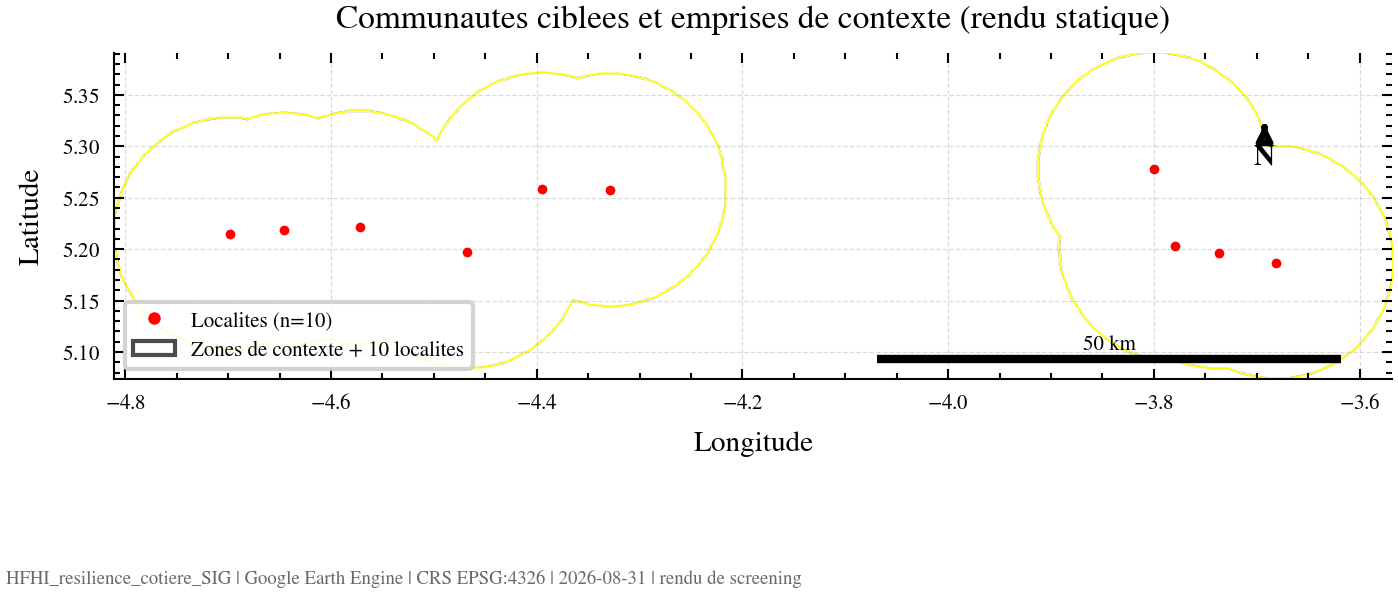

Carte statique : C:\Users\Ordinateur\OneDrive\DR NOUFOU - HFHCI - OPPORTUNITÉS DE MOYENS DE SUBSISTANCE\HFHI_resilience_cotiere_SIG\03_outputs\maps\00_zones_localites_ee_static.png


[WindowsPath('C:/Users/Ordinateur/OneDrive/DR NOUFOU - HFHCI - OPPORTUNITÉS DE MOYENS DE SUBSISTANCE/HFHI_resilience_cotiere_SIG/03_outputs/maps/00_zones_localites_ee_static.png')]

In [11]:
# --- Rendu statique de la carte interactive ci-dessus ---
render_static_ee_map(
    [(ee_zones.style(**{"color": "yellow", "fillColor": "00000000", "width": 2}),
      None, "Zones de contexte + 10 localites")],
    region_geometry,
    "Communautes ciblees et emprises de contexte (rendu statique)",
    FOLDERS["maps"] / "00_zones_localites_ee_static.png",
    points=localites,
)

# PARTIE A — Imagerie optique et occupation du sol

## 6. Sentinel-2 : composite propre et indices spectraux

Le compromis retenu utilise :

- `COPERNICUS/S2_SR_HARMONIZED` pour la réflectance de surface ;
- `Cloud Score+` et la bande `cs_cdf` pour filtrer les pixels peu exploitables ;
- seuil initial `0.60`, à contrôler visuellement ;
- médiane temporelle pour limiter le bruit résiduel.

Indices produits : **NDVI, EVI, NDMI, NDWI, MNDWI, NDBI, BSI**.

In [18]:
S2_SR = "COPERNICUS/S2_SR_HARMONIZED"
CLOUD_SCORE = "GOOGLE/CLOUD_SCORE_PLUS/V1/S2_HARMONIZED"

S2_KEEP = ["B2","B3","B4","B5","B6","B7","B8","B8A","B11","B12"]

def get_s2_collection(start_date, end_date, geometry, clear_threshold=CLOUD_CLEAR_THRESHOLD):
    s2 = (
        ee.ImageCollection(S2_SR)
        .filterBounds(geometry)
        .filterDate(start_date, end_date)
    )
    cs = (
        ee.ImageCollection(CLOUD_SCORE)
        .filterBounds(geometry)
        .filterDate(start_date, end_date)
    )

    linked = s2.linkCollection(cs, [CLOUD_QA_BAND])

    def prep(img):
        clear = img.select(CLOUD_QA_BAND).gte(clear_threshold)
        refl = img.select(S2_KEEP).multiply(0.0001)
        return (
            refl.updateMask(clear)
            .copyProperties(img, img.propertyNames())
        )

    return linked.map(prep)

def add_spectral_indices(img):
    ndvi = img.normalizedDifference(["B8","B4"]).rename("NDVI")
    ndmi = img.normalizedDifference(["B8","B11"]).rename("NDMI")
    ndwi = img.normalizedDifference(["B3","B8"]).rename("NDWI")
    mndwi = img.normalizedDifference(["B3","B11"]).rename("MNDWI")
    ndbi = img.normalizedDifference(["B11","B8"]).rename("NDBI")
    evi = img.expression(
        "2.5 * ((NIR - RED) / (NIR + 6*RED - 7.5*BLUE + 1))",
        {"NIR": img.select("B8"), "RED": img.select("B4"), "BLUE": img.select("B2")}
    ).rename("EVI")
    bsi = img.expression(
        "((SWIR + RED) - (NIR + BLUE)) / ((SWIR + RED) + (NIR + BLUE))",
        {"SWIR": img.select("B11"), "RED": img.select("B4"), "NIR": img.select("B8"), "BLUE": img.select("B2")}
    ).rename("BSI")
    return img.addBands([ndvi, evi, ndmi, ndwi, mndwi, ndbi, bsi])

s2_recent_col = get_s2_collection(S2_RECENT_START, END_DATE, region_geometry)
s2_recent = s2_recent_col.map(add_spectral_indices).median().clip(region_geometry)

print("Nombre de scènes Sentinel-2 candidates :", s2_recent_col.size().getInfo())

Nombre de scènes Sentinel-2 candidates : 1207


In [19]:
Map_s2 = geemap.Map()
Map_s2.centerObject(ee_region, 9)
Map_s2.add_basemap("SATELLITE")
Map_s2.addLayer(
    s2_recent,
    {"bands":["B4","B3","B2"], "min":0.02, "max":0.30, "gamma":1.1},
    "Sentinel-2 RGB"
)
Map_s2.addLayer(s2_recent.select("NDVI"), {"min":-0.2,"max":0.85}, "NDVI", False)
Map_s2.addLayer(s2_recent.select("MNDWI"), {"min":-0.5,"max":0.7}, "MNDWI", False)
Map_s2.addLayer(s2_recent.select("NDBI"), {"min":-0.5,"max":0.5}, "NDBI", False)
Map_s2.addLayer(ee_localites.style(**{"color":"red","pointSize":5}), {}, "Localités")
Map_s2

Map(center=[5.226528750906934, -4.2184593267832655], controls=(WidgetControl(options=['position', 'transparent…

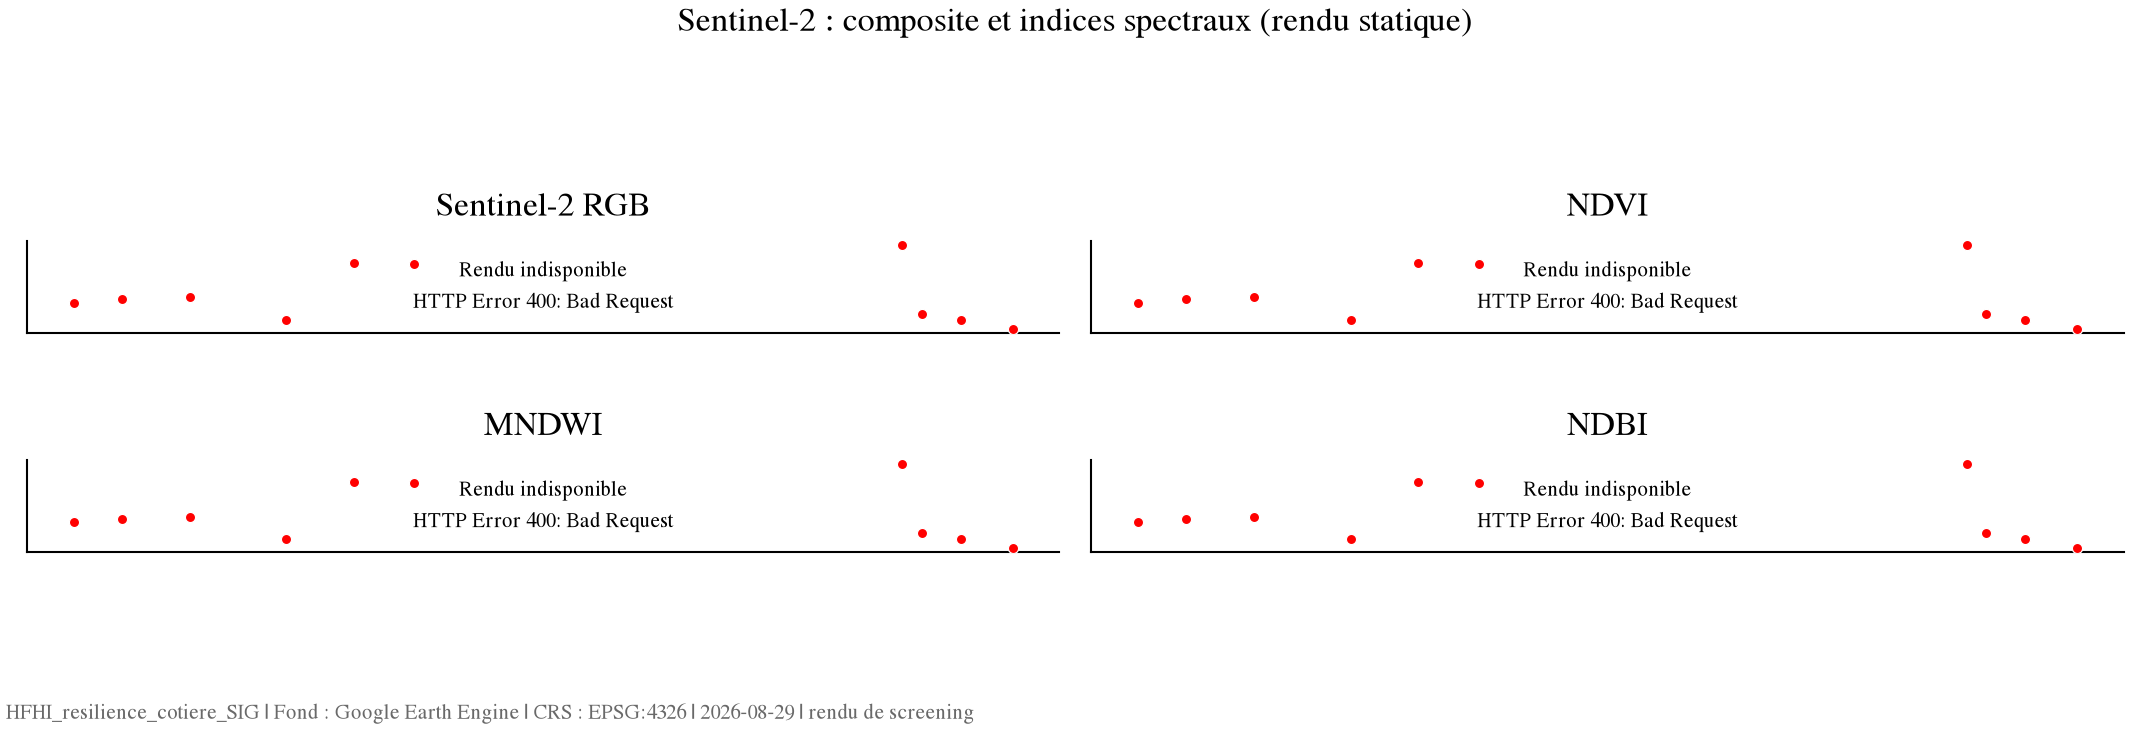

Carte statique : c:\Users\Ordinateur\OneDrive\DR NOUFOU - HFHCI - OPPORTUNITÉS DE MOYENS DE SUBSISTANCE\HFHI_resilience_cotiere_SIG\03_outputs\maps\02_sentinel2_indices_static.png


WindowsPath('c:/Users/Ordinateur/OneDrive/DR NOUFOU - HFHCI - OPPORTUNITÉS DE MOYENS DE SUBSISTANCE/HFHI_resilience_cotiere_SIG/03_outputs/maps/02_sentinel2_indices_static.png')

In [20]:
# --- Rendu statique de la carte interactive ci-dessus ---
render_static_ee_map(
    [
        (s2_recent, {"bands": ["B4", "B3", "B2"], "min": 0.02, "max": 0.30, "gamma": 1.1}, "Sentinel-2 RGB"),
        (s2_recent.select("NDVI"), {"min": -0.2, "max": 0.85, "palette": ["white", "#397d49"]}, "NDVI"),
        (s2_recent.select("MNDWI"), {"min": -0.5, "max": 0.7, "palette": ["#8c510a", "white", "#2166ac"]}, "MNDWI"),
        (s2_recent.select("NDBI"), {"min": -0.5, "max": 0.5, "palette": ["white", "#c4281b"]}, "NDBI"),
    ],
    region_geometry, "Sentinel-2 : composite et indices spectraux (rendu statique)",
    FOLDERS["maps"] / "02_sentinel2_indices_static.png",
    points=localites,
)

In [21]:
def export_ee_image_local(image, filename, region_geom, scale, crs=METRIC_CRS):
    '''
    Export direct pour une emprise modérée.
    Pour une très grande emprise, utiliser la fonction Drive ci-dessous.
    '''
    filename = Path(filename)
    filename.parent.mkdir(parents=True, exist_ok=True)
    geemap.ee_export_image(
        image=image,
        filename=str(filename),
        scale=scale,
        region=region_geom,
        crs=crs,
        file_per_band=False,
    )
    return filename

def export_ee_image_drive(image, description, folder, region_geom, scale, crs=METRIC_CRS):
    task = ee.batch.Export.image.toDrive(
        image=image,
        description=description,
        folder=folder,
        region=region_geom,
        scale=scale,
        crs=crs,
        maxPixels=1e13,
    )
    task.start()
    print("Tâche Drive lancée :", description)
    return task

# Exemple (à exécuter au besoin) :
# export_ee_image_local(
#     s2_recent.select(["B4","B3","B2","NDVI","MNDWI"]),
#     FOLDERS["gee_exports"] / "sentinel2_recent.tif",
#     region_geometry,
#     scale=20
# )

## 7. Dynamic World : occupation du sol et incertitude

Dynamic World fournit 9 classes à 10 m et les probabilités de classe. On utilise :

- la **classe modale** pour une lecture cartographique ;
- la **moyenne des probabilités** pour qualifier l'incertitude ;
- `1 - max(probabilité moyenne)` comme **proxy d'incertitude**.

Cette classification doit être confrontée aux observations terrain, en particulier pour les mosaïques agricoles, cocoteraies et zones humides côtières.

In [22]:
DW_ID = "GOOGLE/DYNAMICWORLD/V1"
DW_CLASSES = [
    "water", "trees", "grass", "flooded_vegetation", "crops",
    "shrub_and_scrub", "built", "bare", "snow_and_ice"
]
DW_LABELS_FR = {
    0:"Eau", 1:"Arbres", 2:"Herbacées", 3:"Végétation inondée",
    4:"Cultures", 5:"Arbustes/broussailles", 6:"Bâti", 7:"Sol nu", 8:"Neige/glace"
}

dw_recent_col = (
    ee.ImageCollection(DW_ID)
    .filterBounds(region_geometry)
    .filterDate(S2_RECENT_START, END_DATE)
)

dw_label = dw_recent_col.select("label").mode().rename("dw_label").clip(region_geometry)
dw_probs = dw_recent_col.select(DW_CLASSES).mean().clip(region_geometry)
dw_confidence = dw_probs.reduce(ee.Reducer.max()).rename("dw_confidence")
dw_uncertainty = ee.Image(1).subtract(dw_confidence).rename("dw_uncertainty")

print("Images Dynamic World :", dw_recent_col.size().getInfo())

Images Dynamic World : 322


In [23]:
DW_PALETTE = [
    "419bdf", "397d49", "88b053", "7a87c6", "e49635",
    "dfc35a", "c4281b", "a59b8f", "b39fe1"
]

Map_dw = geemap.Map()
Map_dw.centerObject(ee_region, 9)
Map_dw.add_basemap("HYBRID")
Map_dw.addLayer(dw_label, {"min":0, "max":8, "palette":DW_PALETTE}, "Occupation du sol")
Map_dw.addLayer(dw_uncertainty, {"min":0, "max":0.7}, "Incertitude DW", False)
Map_dw.addLayer(ee_localites.style(**{"color":"white","pointSize":5}), {}, "Localités")
Map_dw

Map(center=[5.226528750906934, -4.2184593267832655], controls=(WidgetControl(options=['position', 'transparent…

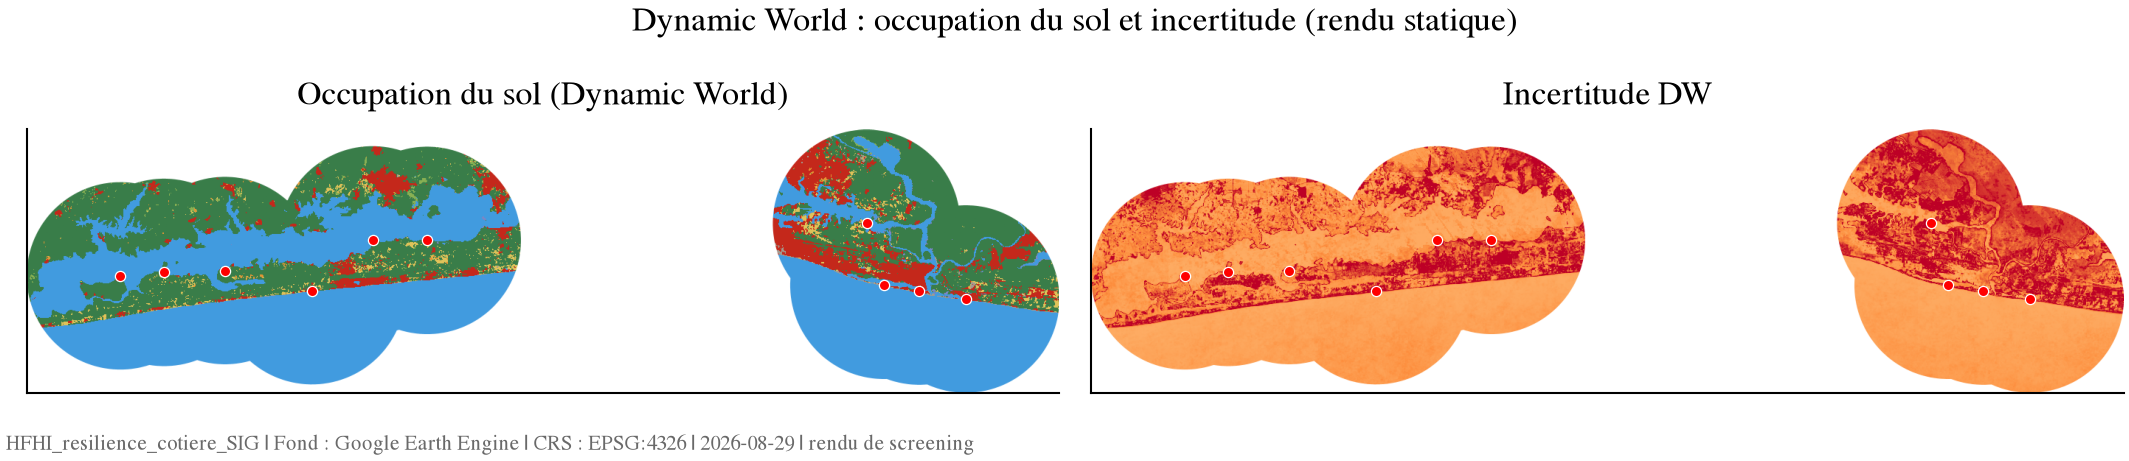

Carte statique : c:\Users\Ordinateur\OneDrive\DR NOUFOU - HFHCI - OPPORTUNITÉS DE MOYENS DE SUBSISTANCE\HFHI_resilience_cotiere_SIG\03_outputs\maps\03_dynamic_world_static.png


WindowsPath('c:/Users/Ordinateur/OneDrive/DR NOUFOU - HFHCI - OPPORTUNITÉS DE MOYENS DE SUBSISTANCE/HFHI_resilience_cotiere_SIG/03_outputs/maps/03_dynamic_world_static.png')

In [24]:
# --- Rendu statique de la carte interactive ci-dessus ---
render_static_ee_map(
    [
        (dw_label, {"min": 0, "max": 8, "palette": DW_PALETTE}, "Occupation du sol (Dynamic World)",
         ["Eau", "Arbres", "Herbe", "Veg. inondee", "Cultures", "Arbustes",
          "Bati", "Sol nu", "Neige/glace"]),
        (dw_uncertainty, {"min": 0, "max": 0.7, "palette": ["#ffffcc", "#fd8d3c", "#bd0026"]}, "Incertitude DW"),
    ],
    region_geometry, "Dynamic World : occupation du sol et incertitude (rendu statique)",
    FOLDERS["maps"] / "03_dynamic_world_static.png",
    points=localites,
)

In [25]:
def grouped_class_area_fc(class_image, features, scale=10, class_band="class"):
    area_class = (
        ee.Image.pixelArea().divide(1e6).rename("area_km2")
        .addBands(class_image.rename(class_band).toInt())
    )
    reducer = ee.Reducer.sum().group(groupField=1, groupName="class")

    def one_feature(ft):
        d = area_class.reduceRegion(
            reducer=reducer,
            geometry=ft.geometry(),
            scale=scale,
            maxPixels=1e10,
            tileScale=4,
        )
        return ft.set("class_areas", d.get("groups"))

    return features.map(one_feature)

def nested_class_areas_to_df(fc, name_field="nom_tdr"):
    info = fc.getInfo()["features"]
    rows = []
    for feat in info:
        props = feat["properties"]
        groups = props.get("class_areas") or []
        for g in groups:
            rows.append({
                name_field: props.get(name_field),
                "zone_tdr": props.get("zone_tdr"),
                "class_id": int(g["class"]),
                "area_km2": float(g["sum"]),
            })
    df = pd.DataFrame(rows)
    if not df.empty:
        df["classe"] = df["class_id"].map(DW_LABELS_FR)
    return df

dw_area_fc = grouped_class_area_fc(dw_label, ee_stats, scale=10)
dw_area = nested_class_areas_to_df(dw_area_fc)

dw_area_path = FOLDERS["tables"] / "occupation_sol_aires_par_communaute.csv"
dw_area.to_csv(dw_area_path, index=False, encoding="utf-8-sig")
display(dw_area.head())

,nom_tdr,zone_tdr,class_id,area_km2,classe
0,Taboth,Jacqueville,0,13.801723,Eau
1,Taboth,Jacqueville,1,11.187834,Arbres
2,Taboth,Jacqueville,2,0.153037,Herbacées
3,Taboth,Jacqueville,3,0.067367,Végétation inondée
4,Taboth,Jacqueville,4,0.286470,Cultures


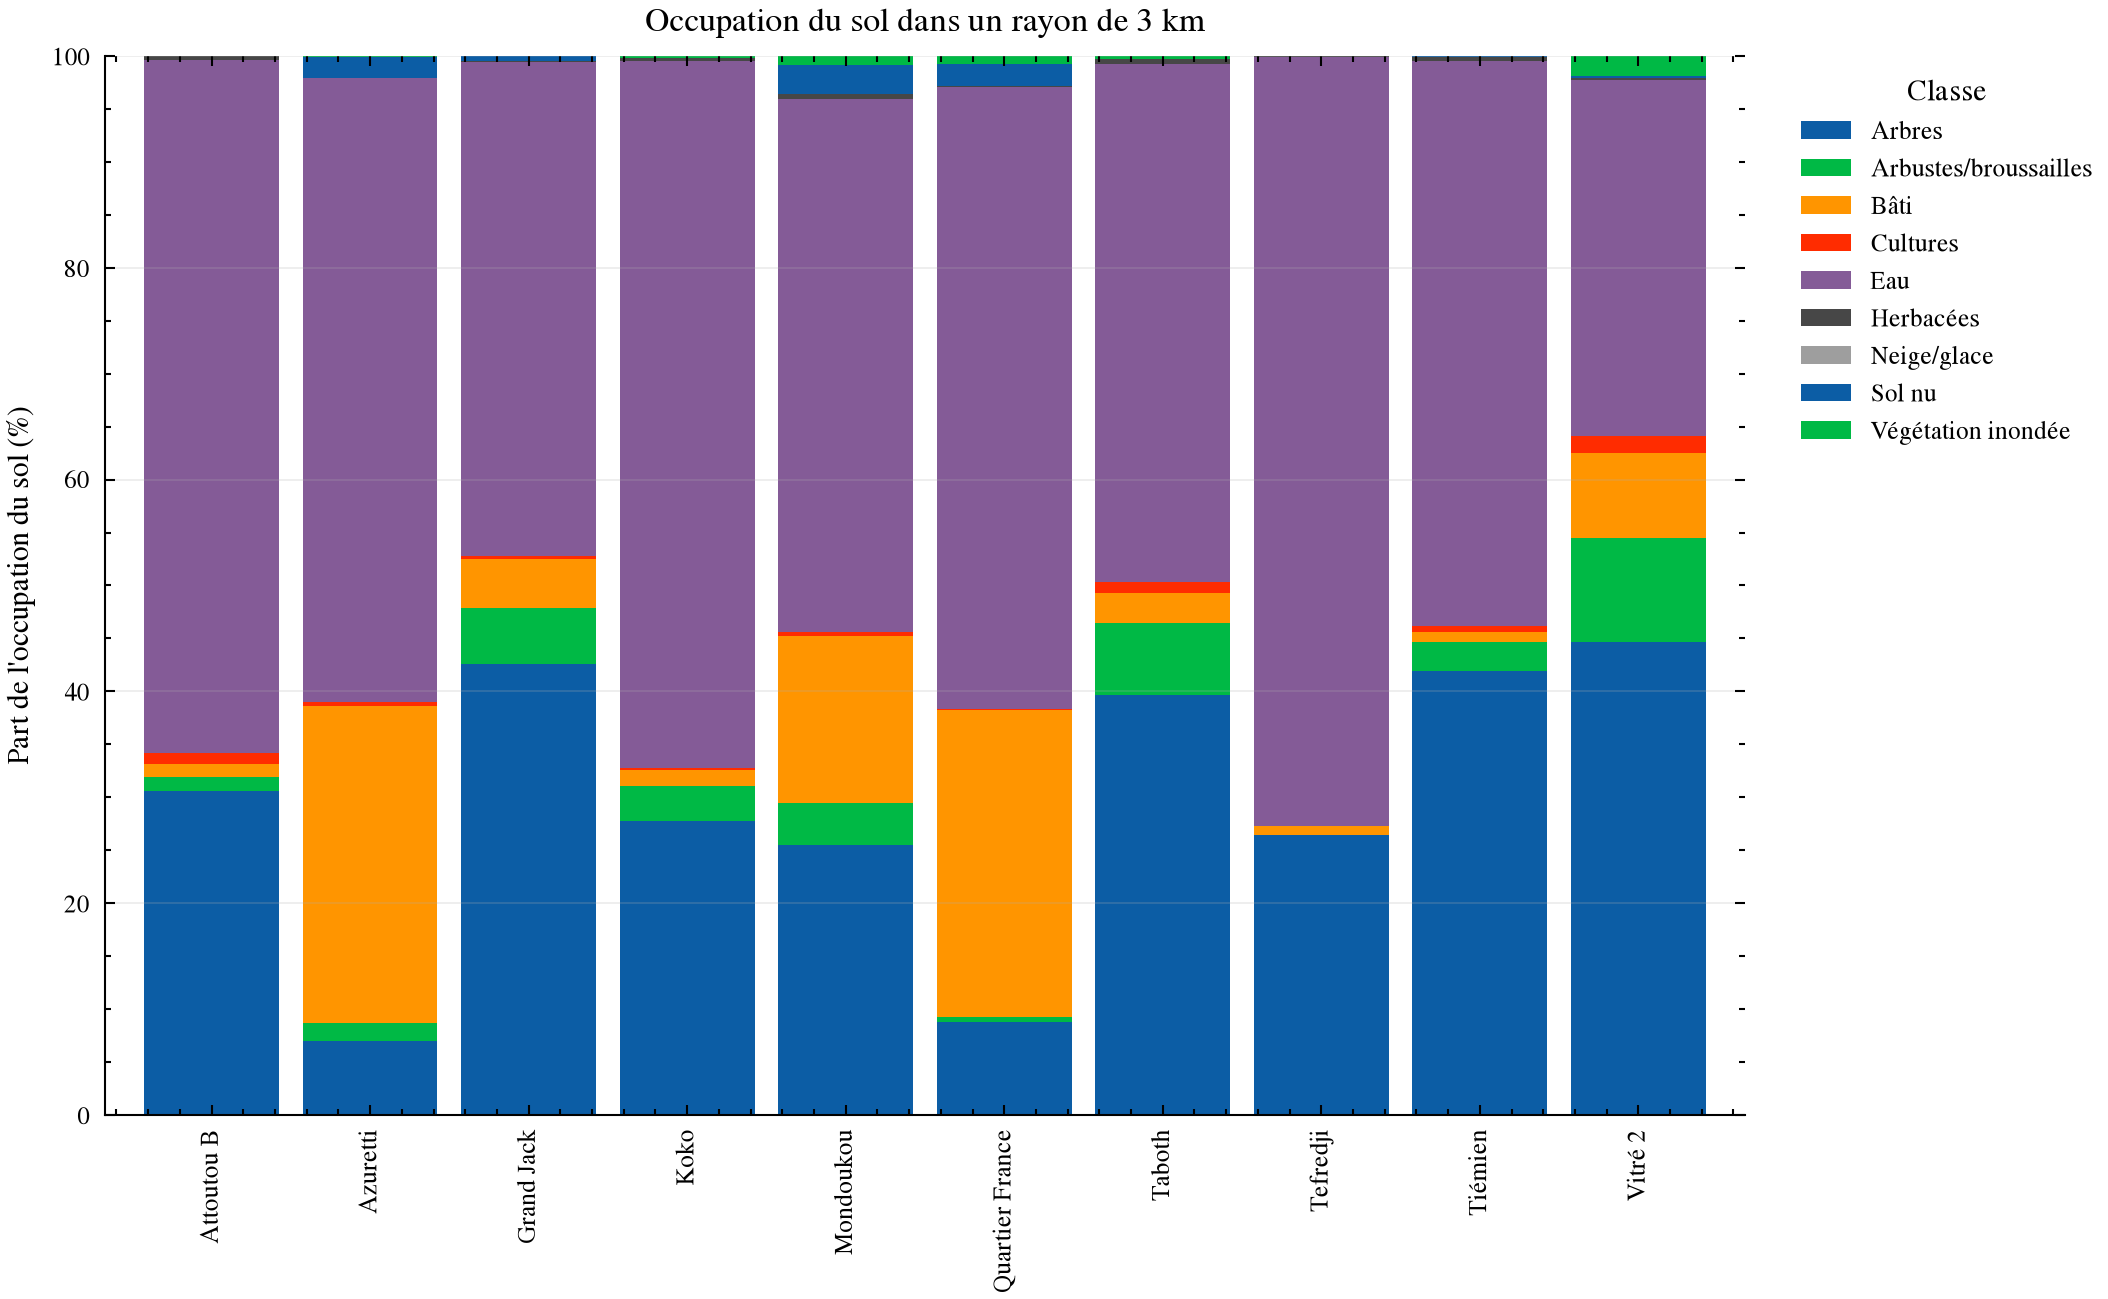

c:\Users\Ordinateur\OneDrive\DR NOUFOU - HFHCI - OPPORTUNITÉS DE MOYENS DE SUBSISTANCE\HFHI_resilience_cotiere_SIG\03_outputs\figures\02_occupation_sol_par_communaute.png


In [26]:
# Graphe : part relative des classes dans le buffer statistique de chaque communauté.
pivot = dw_area.pivot_table(
    index="nom_tdr", columns="classe", values="area_km2", aggfunc="sum", fill_value=0
)
share = pivot.div(pivot.sum(axis=1), axis=0) * 100

ax = share.plot(kind="bar", stacked=True, figsize=NATURE_COL2, width=0.85)
ax.set_ylabel("Part de l'occupation du sol (%)")
ax.set_xlabel("")
ax.set_title(f"Occupation du sol dans un rayon de {COMMUNITY_STATS_BUFFER_KM:g} km")
ax.legend(title="Classe", bbox_to_anchor=(1.02,1), loc="upper left")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()

out = FOLDERS["figures"] / "02_occupation_sol_par_communaute.png"
plt.savefig(out, dpi=FIG_DPI, bbox_inches="tight")
plt.show()
print(out)

,nom_tdr,zone_tdr,dw_uncertainty_mean
8,Vitré 2,Grand-Bassam,0.515586
0,Taboth,Jacqueville,0.439600
7,Mondoukou,Grand-Bassam,0.431345
5,Grand Jack,Jacqueville,0.399569
4,Tiémien,Jacqueville,0.395833
2,Koko,Jacqueville,0.377937
9,Azuretti,Grand-Bassam,0.364530
1,Attoutou B,Jacqueville,0.358280
6,Quartier France,Grand-Bassam,0.354655
3,Tefredji,Jacqueville,0.313304


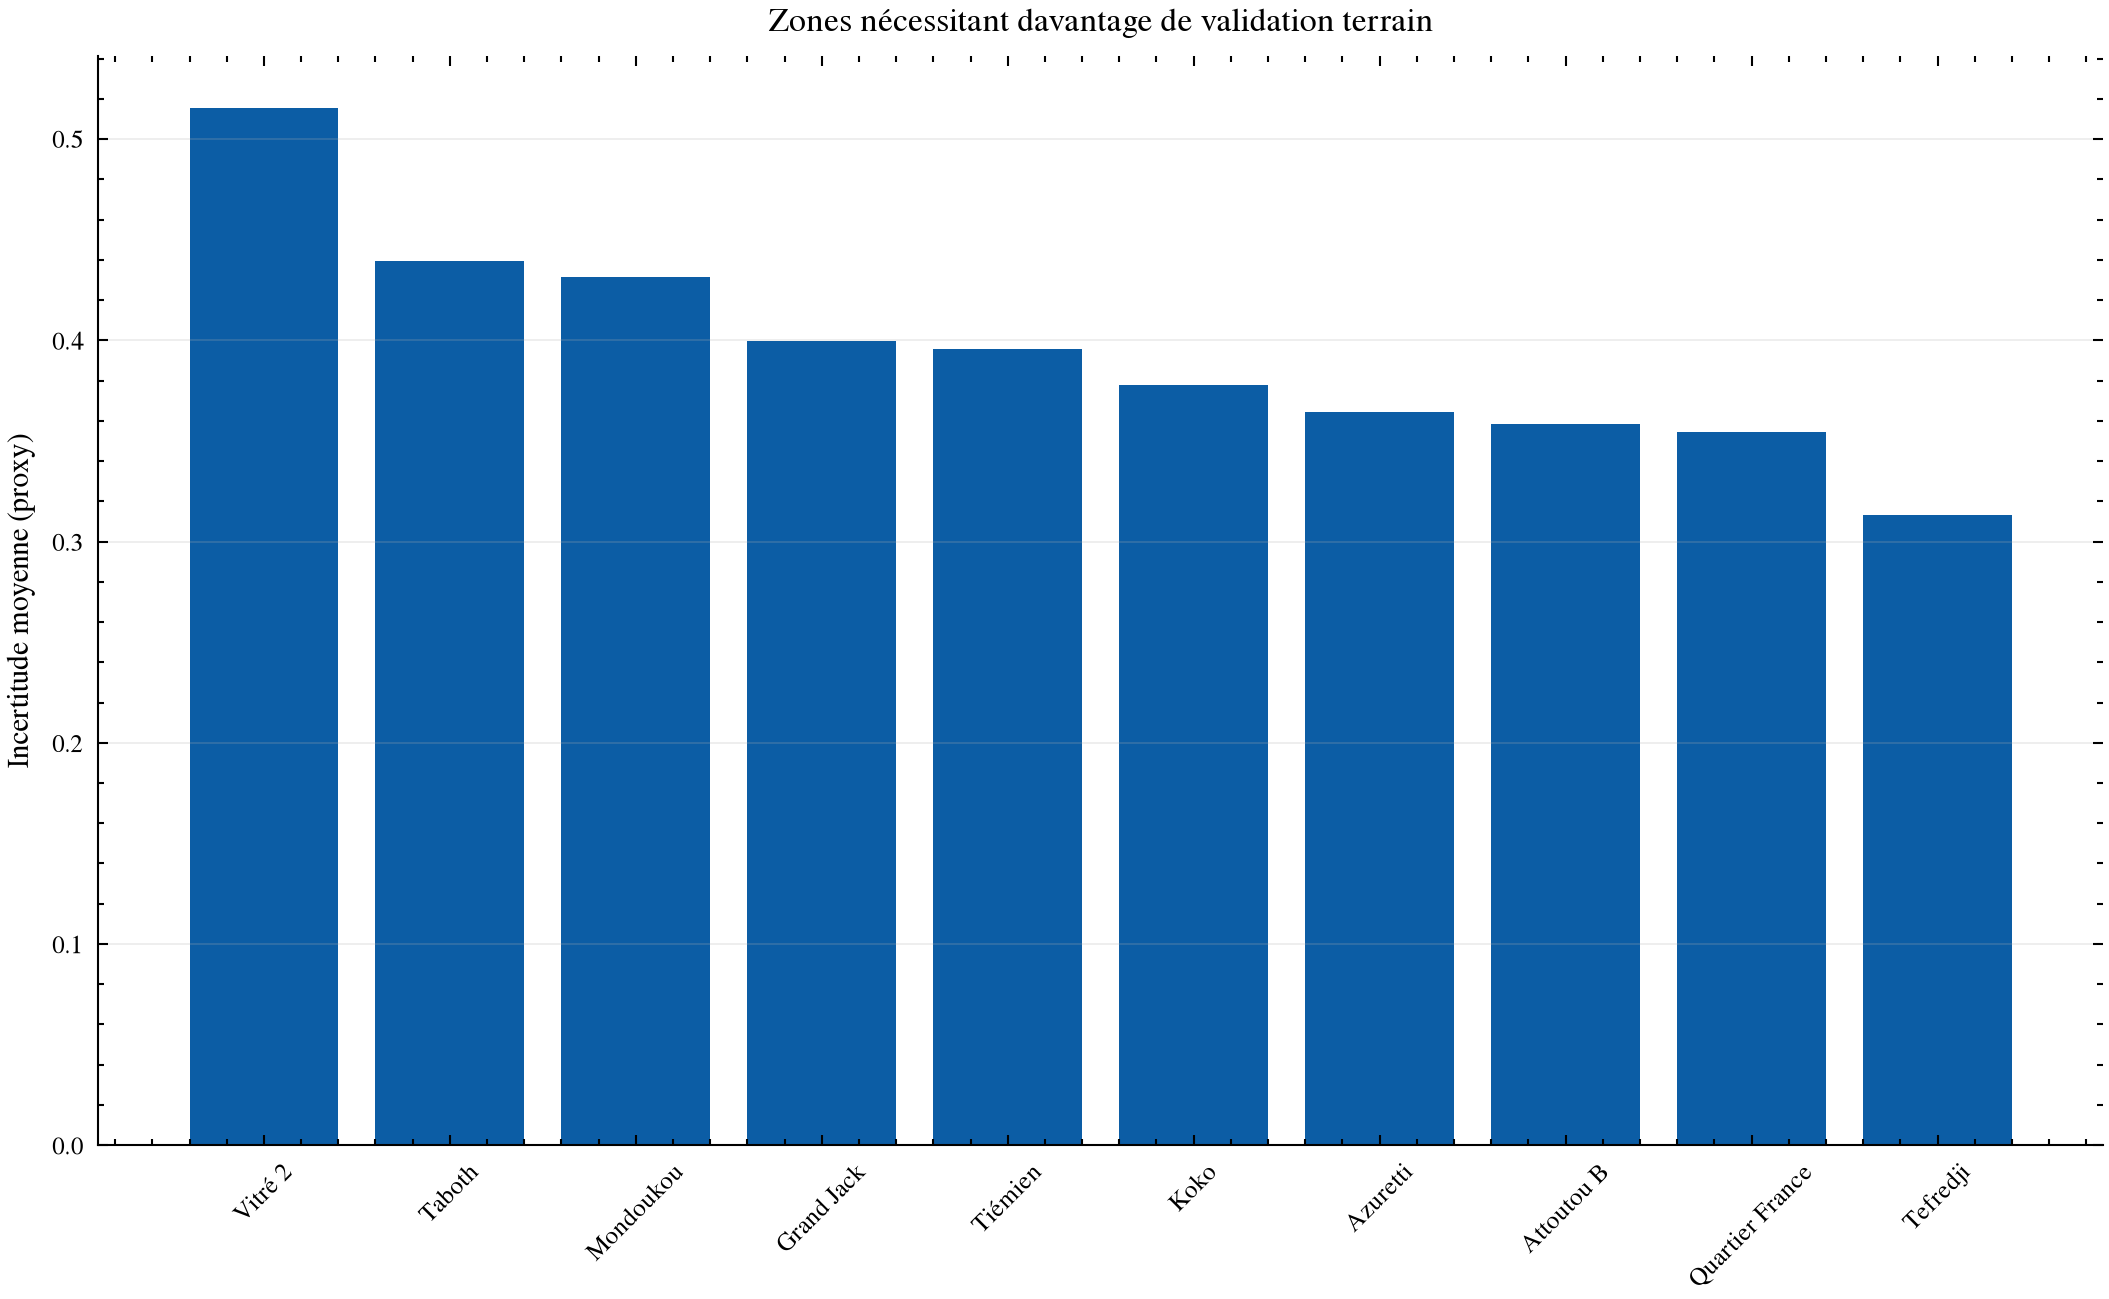

In [27]:
def reduce_mean_over_features(image, features, band_name, scale):
    def reducer_fn(ft):
        val = image.select(band_name).reduceRegion(
            ee.Reducer.mean(), ft.geometry(), scale,
            maxPixels=1e9, tileScale=4
        ).get(band_name)
        return ft.set(f"{band_name}_mean", val)
    return features.map(reducer_fn)

unc_fc = reduce_mean_over_features(dw_uncertainty, ee_stats, "dw_uncertainty", 10)
unc_info = unc_fc.getInfo()["features"]
unc_df = pd.DataFrame([f["properties"] for f in unc_info])
unc_df = unc_df[["nom_tdr","zone_tdr","dw_uncertainty_mean"]].sort_values("dw_uncertainty_mean", ascending=False)

display(unc_df)

fig, ax = plt.subplots(figsize=NATURE_COL2)
ax.bar(unc_df["nom_tdr"], unc_df["dw_uncertainty_mean"])
ax.set_ylabel("Incertitude moyenne (proxy)")
ax.set_title("Zones nécessitant davantage de validation terrain")
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(FOLDERS["figures"] / "03_incertitude_dynamic_world.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

### 7.1 Classification supervisée optionnelle après terrain

Si vous disposez de points/polygones d'apprentissage avec une colonne `class_id`, le bloc suivant permet une classification Random Forest dans Earth Engine.

**Ne pas l'utiliser avant d'avoir des observations terrain suffisamment représentatives.** La séparation aléatoire simple fournie ici est une base ; pour un résultat scientifique final, préférer une validation spatialement indépendante.

In [28]:
TRAINING_FILE = FOLDERS["raw_field"] / "training_landcover.gpkg"

def supervised_landcover_rf(training_file=TRAINING_FILE):
    if not Path(training_file).exists():
        print("Pas de fichier d'apprentissage :", training_file)
        return None

    training_gdf = gpd.read_file(training_file).to_crs(WGS84)
    assert "class_id" in training_gdf.columns, "La colonne class_id est requise."

    training_ee = geemap.gdf_to_ee(training_gdf)
    predictors = ["B2","B3","B4","B5","B6","B7","B8","B8A","B11","B12",
                  "NDVI","EVI","NDMI","MNDWI","NDBI","BSI"]

    sample = s2_recent.select(predictors).sampleRegions(
        collection=training_ee,
        properties=["class_id"],
        scale=10,
        geometries=True
    ).randomColumn("random", seed=42)

    train = sample.filter(ee.Filter.lt("random", 0.7))
    test = sample.filter(ee.Filter.gte("random", 0.7))

    classifier = ee.Classifier.smileRandomForest(
        numberOfTrees=300,
        seed=42
    ).train(
        features=train,
        classProperty="class_id",
        inputProperties=predictors
    )

    classified = s2_recent.select(predictors).classify(classifier).rename("class_id")

    validated = test.classify(classifier)
    cm = validated.errorMatrix("class_id", "classification")
    print("Matrice de confusion :", cm.getInfo())
    print("Accuracy :", cm.accuracy().getInfo())
    print("Kappa :", cm.kappa().getInfo())

    return classified, classifier, cm

# classified_rf = supervised_landcover_rf()

# PARTIE B — Faisabilité foncière spatiale et écosystèmes

## 8. Screening de pression foncière et potentiel spatial

Le résultat n'est **pas** une carte de propriété ni de disponibilité juridique.

Le masque conservateur exclut initialement :
- eau permanente ;
- bâti ;
- zones à forte probabilité de végétation inondée ;
- végétation arborée dense ;
- pentes supérieures à un seuil paramétrable.

Le résultat représente uniquement des espaces où une vérification foncière de terrain peut être priorisée.

In [29]:
# DEM préparé ici car la pente est utilisée dans le screening foncier.
DEM_ID = "COPERNICUS/DEM/GLO30_2024_1"
dem_ic = ee.ImageCollection(DEM_ID).select("DEM")
dem_native_proj = dem_ic.first().projection()
dem = dem_ic.mosaic().setDefaultProjection(dem_native_proj).clip(region_geometry).rename("elevation")
slope = ee.Terrain.slope(dem).rename("slope")

jrc_gsw = ee.Image("JRC/GSW1_4/GlobalSurfaceWater")
water_occurrence = jrc_gsw.select("occurrence").unmask(0).clip(region_geometry)

ghsl_built = ee.Image("JRC/GHSL/P2023A/GHS_BUILT_S_10m/2018").select("built_surface").clip(region_geometry)

water_mask = (
    dw_probs.select("water").gt(0.45)
    .Or(water_occurrence.gt(75))
)
built_mask = (
    dw_probs.select("built").gt(0.35)
    .Or(ghsl_built.gt(10))
)
flooded_veg_mask = dw_probs.select("flooded_vegetation").gt(0.35)
dense_tree_mask = dw_probs.select("trees").gt(0.65)
steep_mask = slope.gt(5)

constraint_count = (
    water_mask.add(built_mask).add(flooded_veg_mask).add(dense_tree_mask).add(steep_mask)
).rename("constraint_count")

spatial_candidate = (
    water_mask.Not()
    .And(built_mask.Not())
    .And(flooded_veg_mask.Not())
    .And(dense_tree_mask.Not())
    .And(steep_mask.Not())
    .rename("spatial_candidate")
)

Map_land = geemap.Map()
Map_land.centerObject(ee_region, 9)
Map_land.add_basemap("SATELLITE")
Map_land.addLayer(constraint_count, {"min":0,"max":5}, "Nombre de contraintes", False)
Map_land.addLayer(spatial_candidate.selfMask(), {"palette":["00ff66"]}, "Potentiel spatial à vérifier")
Map_land.addLayer(ee_localites.style(**{"color":"red","pointSize":5}), {}, "Localités")
Map_land

Map(center=[5.226528750906934, -4.2184593267832655], controls=(WidgetControl(options=['position', 'transparent…

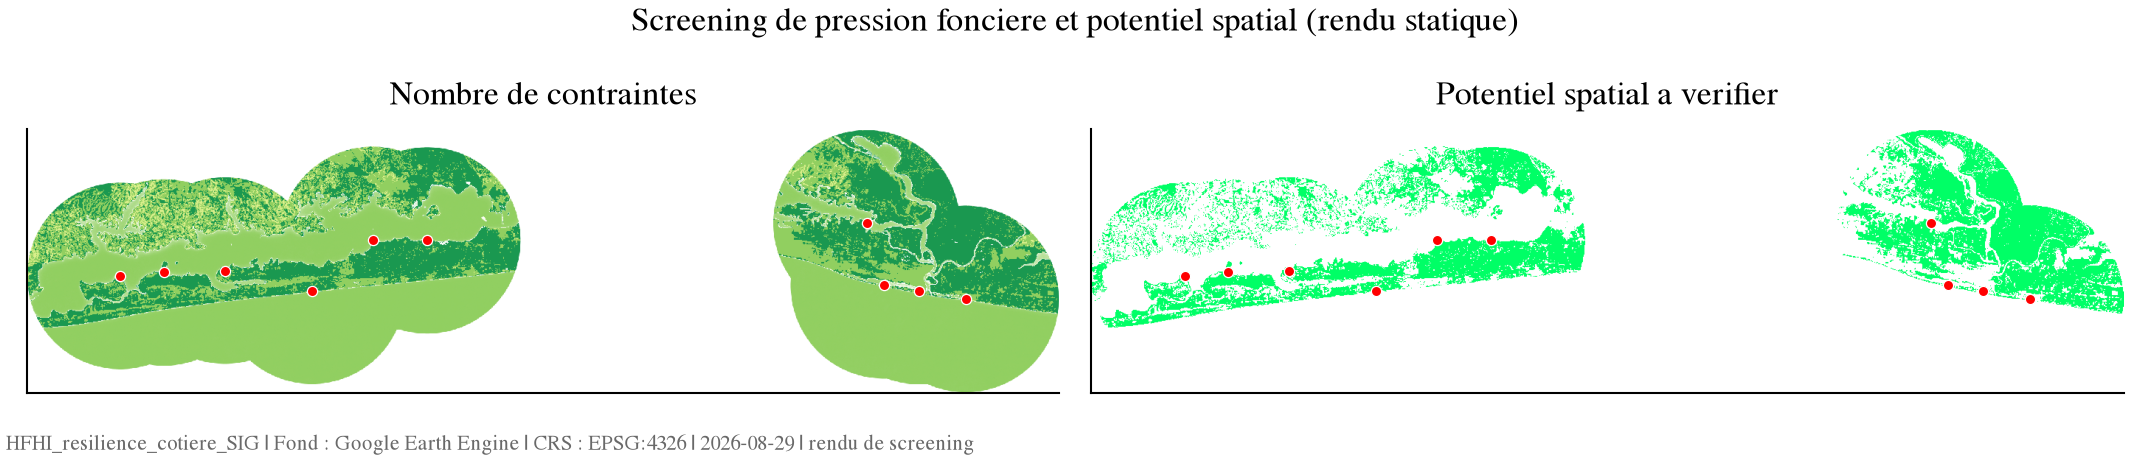

Carte statique : c:\Users\Ordinateur\OneDrive\DR NOUFOU - HFHCI - OPPORTUNITÉS DE MOYENS DE SUBSISTANCE\HFHI_resilience_cotiere_SIG\03_outputs\maps\04_screening_foncier_static.png


WindowsPath('c:/Users/Ordinateur/OneDrive/DR NOUFOU - HFHCI - OPPORTUNITÉS DE MOYENS DE SUBSISTANCE/HFHI_resilience_cotiere_SIG/03_outputs/maps/04_screening_foncier_static.png')

In [30]:
# --- Rendu statique de la carte interactive ci-dessus ---
render_static_ee_map(
    [
        (constraint_count, {"min": 0, "max": 5,
         "palette": ["#1a9850", "#91cf60", "#d9ef8b", "#fee08b", "#fc8d59", "#d73027"]}, "Nombre de contraintes"),
        (spatial_candidate.selfMask(), {"palette": ["#00ff66"]}, "Potentiel spatial a verifier"),
    ],
    region_geometry, "Screening de pression fonciere et potentiel spatial (rendu statique)",
    FOLDERS["maps"] / "04_screening_foncier_static.png",
    points=localites,
)

In [31]:
def binary_area_table(binary_image, features, name, scale=20):
    area = ee.Image.pixelArea().divide(10000).updateMask(binary_image).rename("area_ha")
    def fn(ft):
        a = area.reduceRegion(
            ee.Reducer.sum(), ft.geometry(), scale,
            maxPixels=1e10, tileScale=4
        ).get("area_ha")
        total = ee.Image.pixelArea().divide(10000).rename("total_ha").reduceRegion(
            ee.Reducer.sum(), ft.geometry(), scale,
            maxPixels=1e10, tileScale=4
        ).get("total_ha")
        return ft.set({f"{name}_ha": a, "total_ha": total})
    out = features.map(fn).getInfo()["features"]
    return pd.DataFrame([f["properties"] for f in out])

candidate_df = binary_area_table(spatial_candidate, ee_stats, "candidate", 20)
candidate_df["candidate_ha"] = pd.to_numeric(candidate_df["candidate_ha"], errors="coerce").fillna(0)
candidate_df["share_candidate_pct"] = 100 * candidate_df["candidate_ha"] / candidate_df["total_ha"]

candidate_df[["nom_tdr","zone_tdr","candidate_ha","share_candidate_pct"]].to_csv(
    FOLDERS["tables"] / "screening_potentiel_spatial.csv",
    index=False, encoding="utf-8-sig"
)
display(candidate_df[["nom_tdr","zone_tdr","candidate_ha","share_candidate_pct"]]
        .sort_values("share_candidate_pct", ascending=False))

,nom_tdr,zone_tdr,candidate_ha,share_candidate_pct
8,Vitré 2,Grand-Bassam,1422.910643,50.376408
0,Taboth,Jacqueville,1075.690960,38.096549
7,Mondoukou,Grand-Bassam,937.196819,33.178504
5,Grand Jack,Jacqueville,889.904642,31.520445
4,Tiémien,Jacqueville,813.083158,28.804303
2,Koko,Jacqueville,777.586724,27.540404
1,Attoutou B,Jacqueville,582.781930,20.644141
3,Tefredji,Jacqueville,380.234672,13.470930
6,Quartier France,Grand-Bassam,356.226495,12.611369
9,Azuretti,Grand-Bassam,354.664626,12.556330


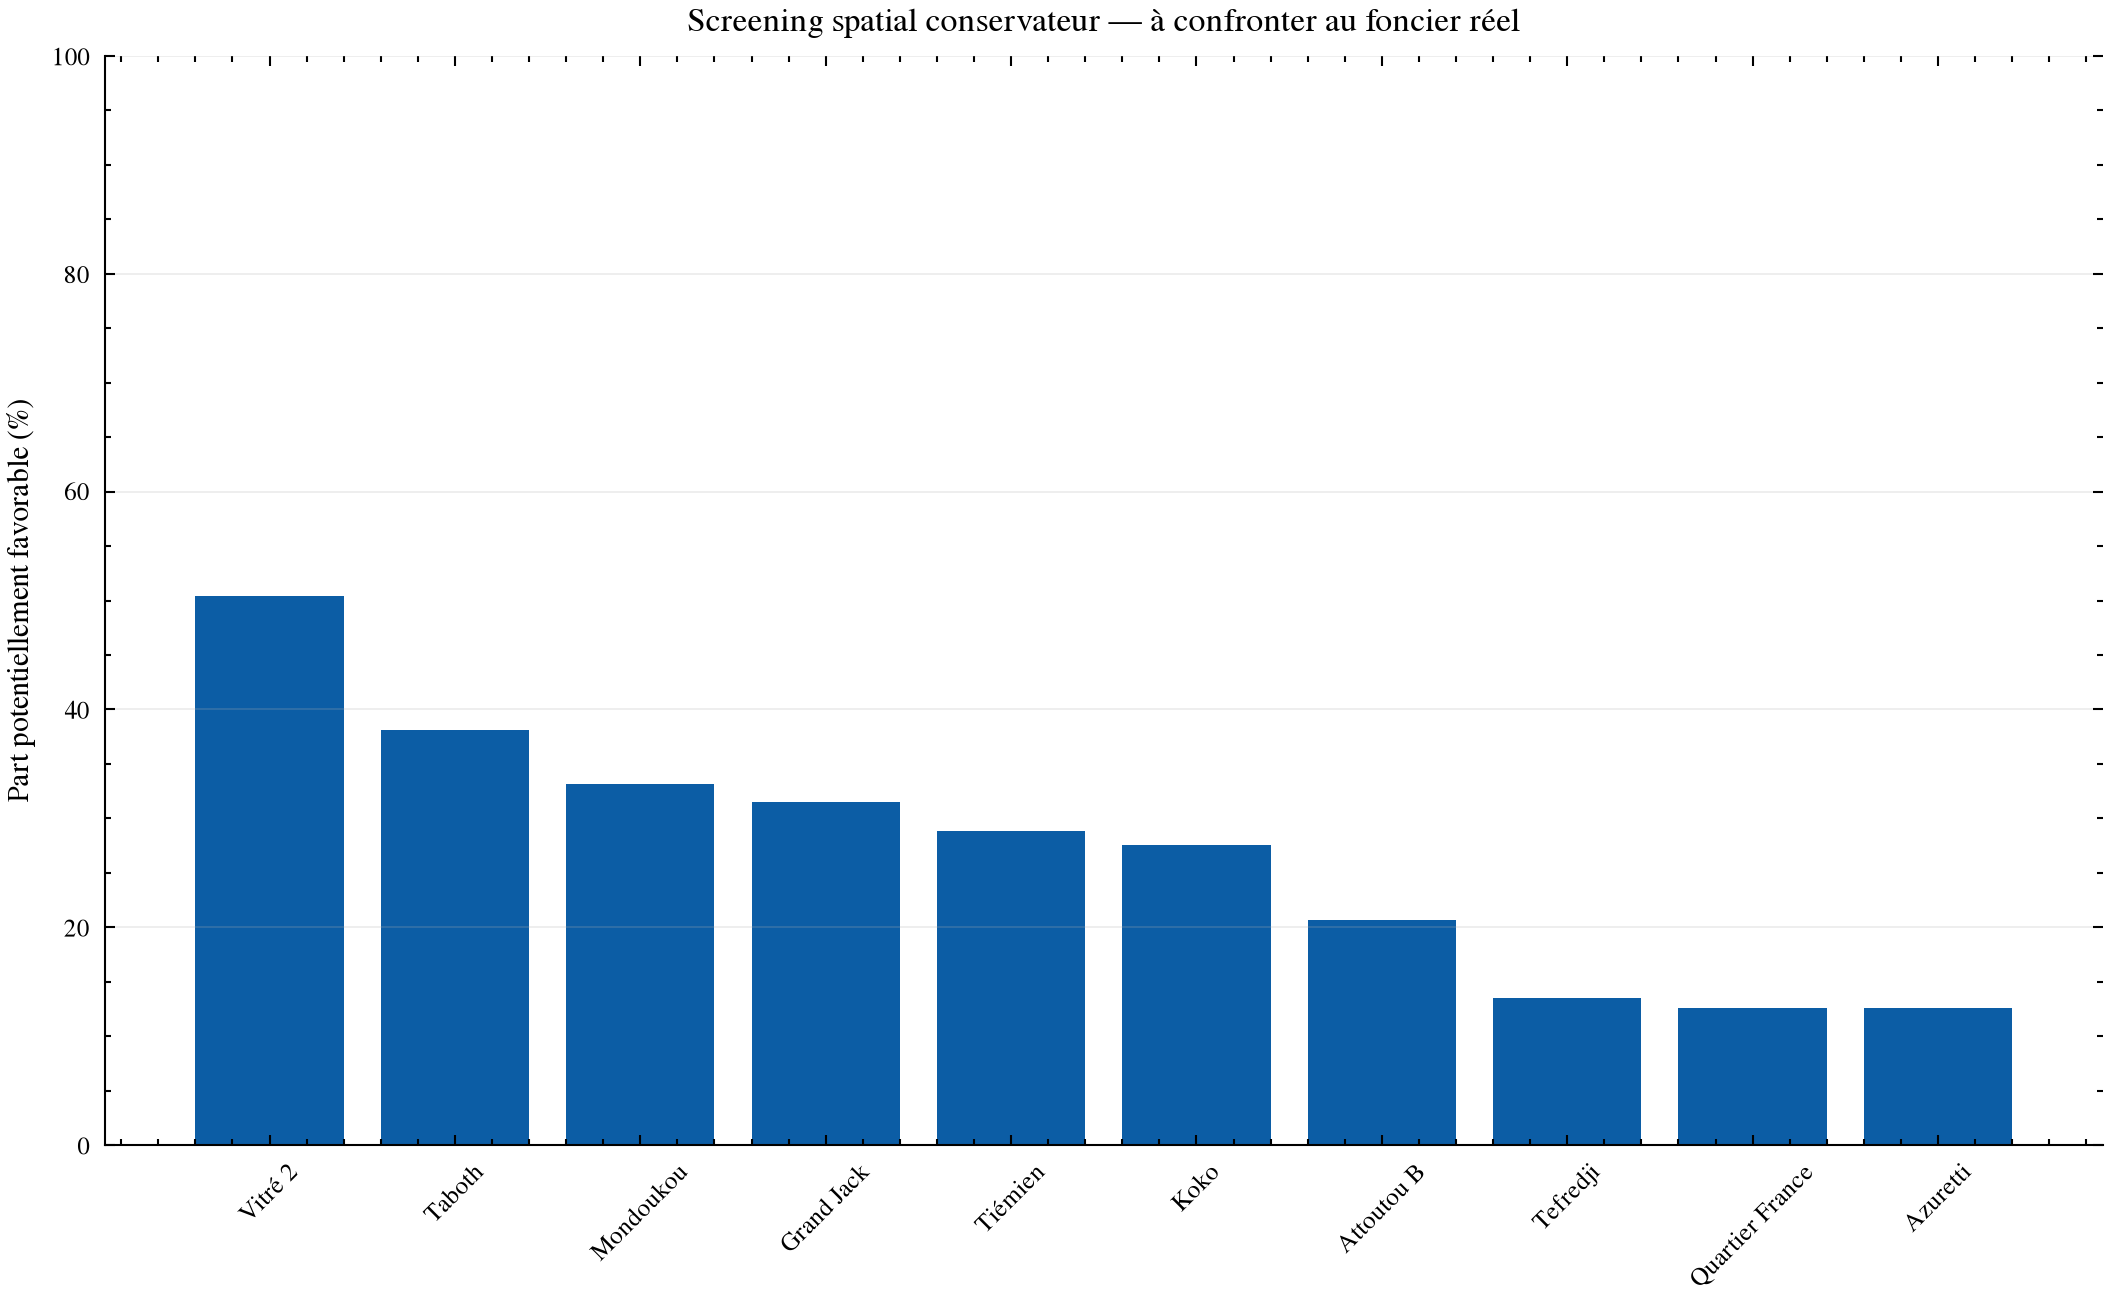

In [32]:
plot_df = candidate_df.sort_values("share_candidate_pct", ascending=False)

fig, ax = plt.subplots(figsize=NATURE_COL2)
ax.bar(plot_df["nom_tdr"], plot_df["share_candidate_pct"])
ax.set_ylabel("Part potentiellement favorable (%)")
ax.set_title("Screening spatial conservateur — à confronter au foncier réel")
ax.tick_params(axis="x", rotation=45)
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(FOLDERS["figures"] / "04_potentiel_spatial_screening.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

## 9. Mangroves / zones humides : proxy et validation

En l'absence d'une couche officielle de mangroves intégrée au projet, on construit un **proxy** combinant :

- probabilité `flooded_vegetation` de Dynamic World ;
- probabilité `trees` ;
- proximité d'une eau permanente.

Ce proxy doit être remplacé ou validé par une couche de référence (Global Mangrove Watch, inventaire national, donnée projet ou terrain).

In [33]:
def distance_to_binary_mask(mask, max_distance_m, band_name):
    source = ee.Image(mask).unmask(0).gt(0)
    kernel = ee.Kernel.euclidean(radius=max_distance_m, units="meters")
    return (
        source.distance(kernel, skipMasked=False)
        .unmask(max_distance_m)
        .rename(band_name)
    )

permanent_water = water_occurrence.gt(80)
dist_water_3000 = distance_to_binary_mask(permanent_water, 3000, "dist_water_m")

mangrove_proxy = (
    dw_probs.select("flooded_vegetation").gt(0.20)
    .And(dw_probs.select("trees").gt(0.20))
    .And(dist_water_3000.lt(1500))
    .rename("mangrove_proxy")
)

Map_mang = geemap.Map()
Map_mang.centerObject(ee_region, 9)
Map_mang.add_basemap("SATELLITE")
Map_mang.addLayer(mangrove_proxy.selfMask(), {"palette":["00aa55"]}, "Proxy mangrove/boisement humide")
Map_mang.addLayer(water_occurrence, {"min":0,"max":100}, "Occurrence eau JRC", False)
Map_mang.addLayer(ee_localites.style(**{"color":"red","pointSize":5}), {}, "Localités")
Map_mang

Map(center=[5.226528750906934, -4.2184593267832655], controls=(WidgetControl(options=['position', 'transparent…

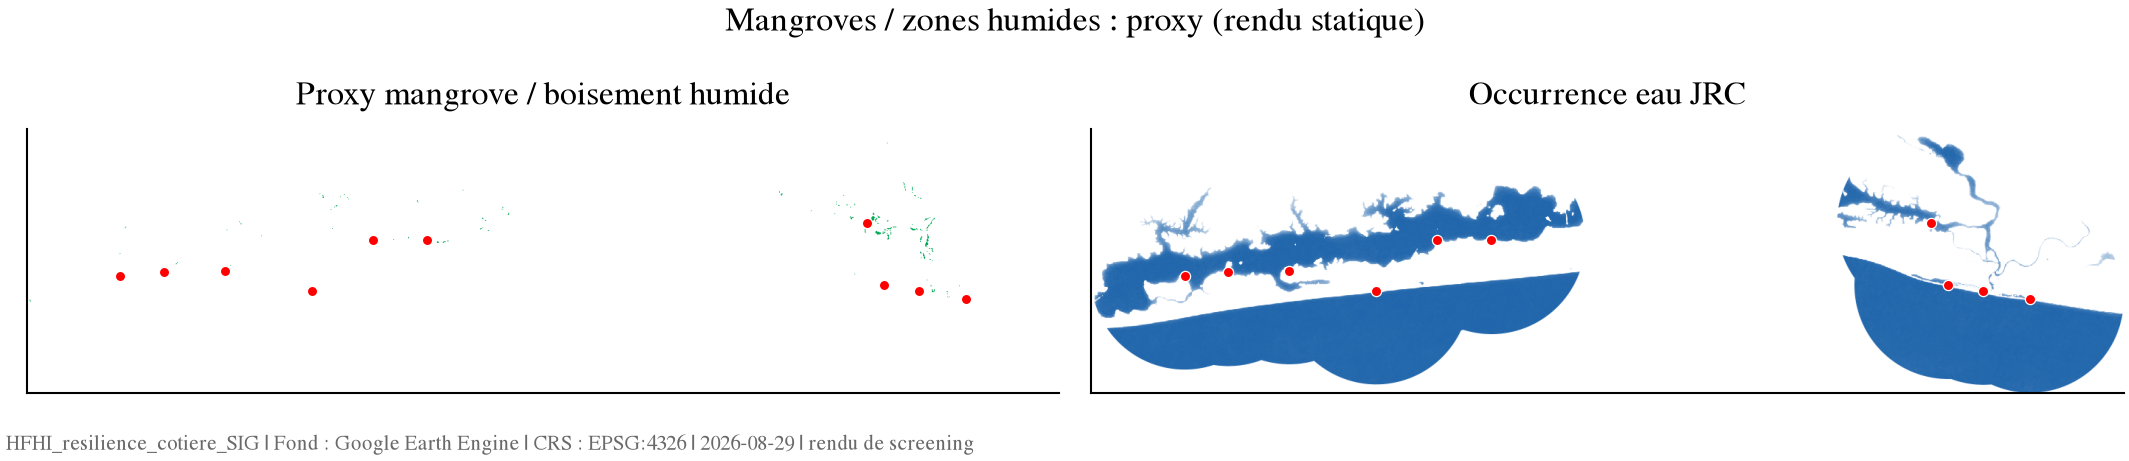

Carte statique : c:\Users\Ordinateur\OneDrive\DR NOUFOU - HFHCI - OPPORTUNITÉS DE MOYENS DE SUBSISTANCE\HFHI_resilience_cotiere_SIG\03_outputs\maps\05_mangrove_proxy_static.png


WindowsPath('c:/Users/Ordinateur/OneDrive/DR NOUFOU - HFHCI - OPPORTUNITÉS DE MOYENS DE SUBSISTANCE/HFHI_resilience_cotiere_SIG/03_outputs/maps/05_mangrove_proxy_static.png')

In [34]:
# --- Rendu statique de la carte interactive ci-dessus ---
render_static_ee_map(
    [
        (mangrove_proxy.selfMask(), {"palette": ["#00aa55"]}, "Proxy mangrove / boisement humide"),
        (water_occurrence, {"min": 0, "max": 100, "palette": ["white", "#2166ac"]}, "Occurrence eau JRC"),
    ],
    region_geometry, "Mangroves / zones humides : proxy (rendu statique)",
    FOLDERS["maps"] / "05_mangrove_proxy_static.png",
    points=localites,
)

In [35]:
def dw_probability_composite(start, end):
    c = (
        ee.ImageCollection(DW_ID)
        .filterBounds(region_geometry)
        .filterDate(start, end)
        .select(DW_CLASSES)
        .mean()
        .clip(region_geometry)
    )
    return c

dw_base_probs = dw_probability_composite(S2_BASELINE_START, S2_BASELINE_END)
dw_now_probs = dw_probability_composite(S2_RECENT_START, END_DATE)

wet_tree_base = (
    dw_base_probs.select("flooded_vegetation")
    .add(dw_base_probs.select("trees"))
    .divide(2)
    .rename("wet_tree_proxy")
)
wet_tree_now = (
    dw_now_probs.select("flooded_vegetation")
    .add(dw_now_probs.select("trees"))
    .divide(2)
    .rename("wet_tree_proxy")
)
wet_tree_change = wet_tree_now.subtract(wet_tree_base).rename("wet_tree_change")

Map_change = geemap.Map()
Map_change.centerObject(ee_region, 9)
Map_change.add_basemap("SATELLITE")
Map_change.addLayer(wet_tree_change, {"min":-0.35,"max":0.35}, "Variation proxy végétation humide")
Map_change.addLayer(ee_localites.style(**{"color":"white","pointSize":5}), {}, "Localités")
Map_change

Map(center=[5.226528750906934, -4.2184593267832655], controls=(WidgetControl(options=['position', 'transparent…

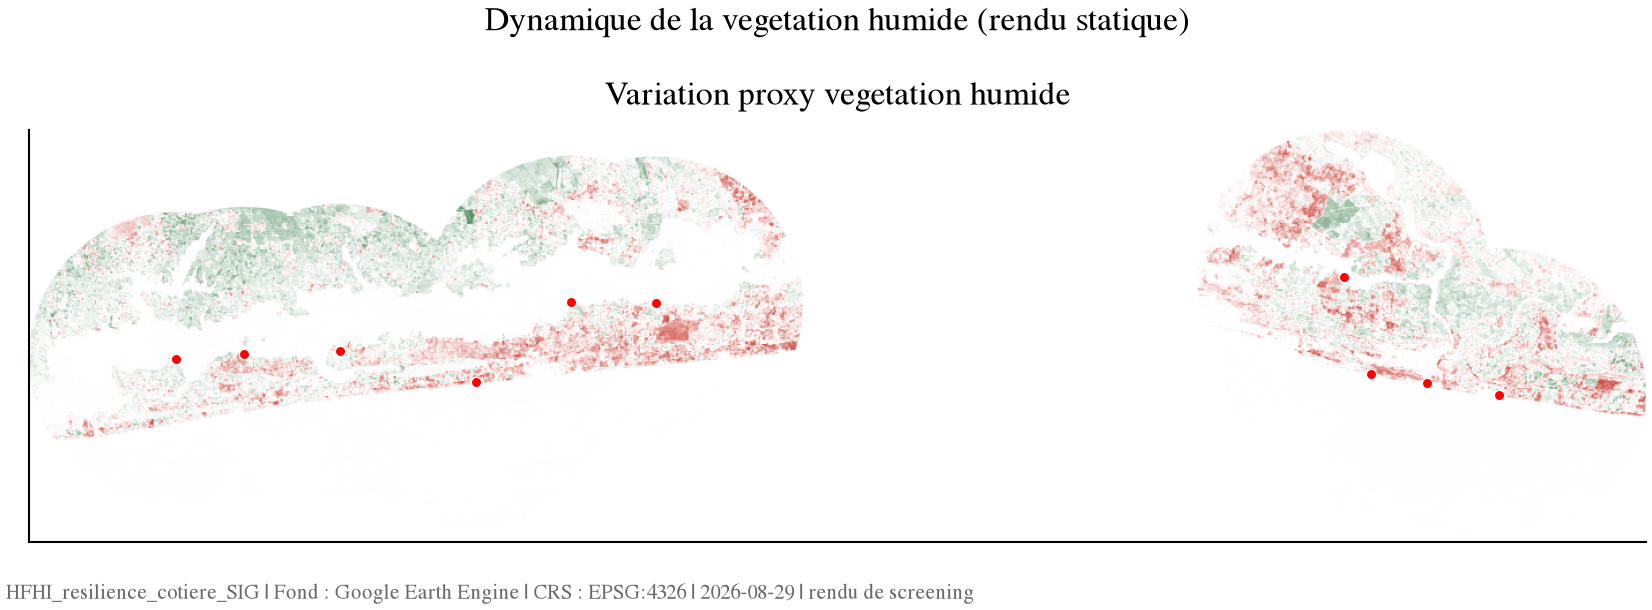

Carte statique : c:\Users\Ordinateur\OneDrive\DR NOUFOU - HFHCI - OPPORTUNITÉS DE MOYENS DE SUBSISTANCE\HFHI_resilience_cotiere_SIG\03_outputs\maps\05b_vegetation_humide_change_static.png


WindowsPath('c:/Users/Ordinateur/OneDrive/DR NOUFOU - HFHCI - OPPORTUNITÉS DE MOYENS DE SUBSISTANCE/HFHI_resilience_cotiere_SIG/03_outputs/maps/05b_vegetation_humide_change_static.png')

In [36]:
# --- Rendu statique de la carte interactive ci-dessus ---
render_static_ee_map(
    [(wet_tree_change, {"min": -0.35, "max": 0.35, "palette": ["#c4281b", "white", "#397d49"]},
      "Variation proxy vegetation humide")],
    region_geometry, "Dynamique de la vegetation humide (rendu statique)",
    FOLDERS["maps"] / "05b_vegetation_humide_change_static.png",
    points=localites,
)

## 10. Eau, littoral et dynamique hydrologique

Deux niveaux complémentaires :

1. **JRC Global Surface Water** : lecture robuste de long terme (1984–2021) à 30 m ;
2. **Sentinel-2 MNDWI** : état récent à 10–20 m.

Pour une étude d'érosion côtière réglementaire ou d'ingénierie, il faut un protocole de ligne de rivage plus strict (marée, géométrie de prise de vue, transects, incertitude positionnelle). Ici on produit un **screening de dynamique du front eau/terre**.

In [37]:
water_change_abs = jrc_gsw.select("change_abs").clip(region_geometry)
water_seasonality = jrc_gsw.select("seasonality").clip(region_geometry)
recent_water_s2 = s2_recent.select("MNDWI").gt(0.05).rename("recent_water_s2")

Map_water = geemap.Map()
Map_water.centerObject(ee_region, 9)
Map_water.add_basemap("SATELLITE")
Map_water.addLayer(water_occurrence, {"min":0,"max":100}, "Occurrence eau 1984-2021")
Map_water.addLayer(water_change_abs, {"min":-50,"max":50}, "Changement occurrence eau", False)
Map_water.addLayer(recent_water_s2.selfMask(), {"palette":["00aaff"]}, "Eau Sentinel-2 récente", False)
Map_water.addLayer(ee_localites.style(**{"color":"red","pointSize":5}), {}, "Localités")
Map_water

Map(center=[5.226528750906937, -4.218459326783267], controls=(WidgetControl(options=['position', 'transparent_…

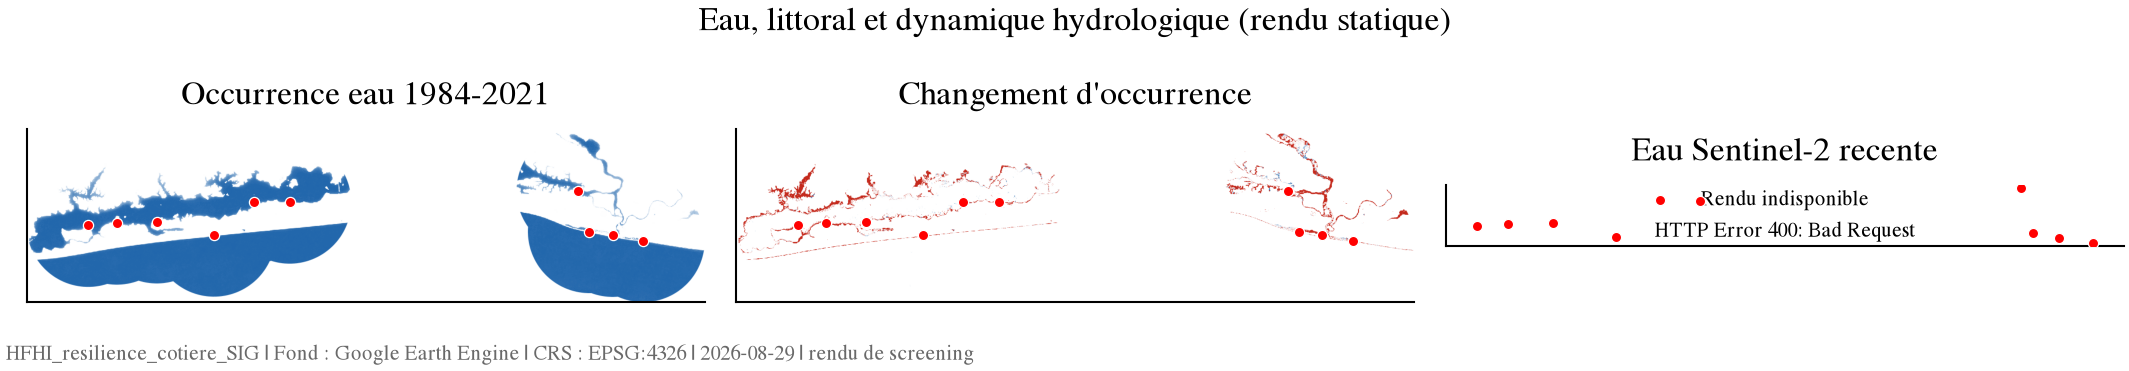

Carte statique : c:\Users\Ordinateur\OneDrive\DR NOUFOU - HFHCI - OPPORTUNITÉS DE MOYENS DE SUBSISTANCE\HFHI_resilience_cotiere_SIG\03_outputs\maps\06_eau_dynamique_static.png


WindowsPath('c:/Users/Ordinateur/OneDrive/DR NOUFOU - HFHCI - OPPORTUNITÉS DE MOYENS DE SUBSISTANCE/HFHI_resilience_cotiere_SIG/03_outputs/maps/06_eau_dynamique_static.png')

In [38]:
# --- Rendu statique de la carte interactive ci-dessus ---
render_static_ee_map(
    [
        (water_occurrence, {"min": 0, "max": 100, "palette": ["white", "#2166ac"]}, "Occurrence eau 1984-2021"),
        (water_change_abs, {"min": -50, "max": 50, "palette": ["#c4281b", "white", "#2166ac"]}, "Changement d'occurrence"),
        (recent_water_s2.selfMask(), {"palette": ["#00aaff"]}, "Eau Sentinel-2 recente"),
    ],
    region_geometry, "Eau, littoral et dynamique hydrologique (rendu statique)",
    FOLDERS["maps"] / "06_eau_dynamique_static.png",
    points=localites,
)

In [ ]:
def annual_s2_water(year, threshold=0.05):
    start = f"{year}-01-01"
    end = f"{year+1}-01-01"
    col = get_s2_collection(start, end, region_geometry)
    comp = col.map(add_spectral_indices).median()
    return comp.select("MNDWI").gt(threshold).rename("water").set("year", year)

water_years = [2018, 2021, 2024]
if LAST_COMPLETE_YEAR not in water_years:
    water_years.append(LAST_COMPLETE_YEAR)
water_years = sorted(set(water_years))

water_area_rows = []
for year in water_years:
    img = annual_s2_water(year)
    area_img = ee.Image.pixelArea().divide(1e6).updateMask(img).rename("water_km2")
    stats_fc = area_img.reduceRegions(
        collection=ee_zones,
        reducer=ee.Reducer.sum(),
        scale=20,
        tileScale=4
    )
    for feat in stats_fc.getInfo()["features"]:
        props = feat["properties"]
        water_area_rows.append({
            "year": year,
            "zone_tdr": props.get("zone_tdr"),
            "water_km2": props.get("sum")
        })

water_area_df = pd.DataFrame(water_area_rows)
display(water_area_df)

fig, ax = plt.subplots(figsize=NATURE_COL2)
for zone, grp in water_area_df.groupby("zone_tdr"):
    grp = grp.sort_values("year")
    ax.plot(grp["year"], grp["water_km2"], marker="o", label=zone)
ax.set_ylabel("Surface classée en eau dans l'emprise (km²)")
ax.set_title("Évolution indicative du front eau/terre — Sentinel-2")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(FOLDERS["figures"] / "05_dynamique_eau_sentinel2.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

### 10.1 Vectorisation optionnelle du front eau/terre

Cette opération peut être lourde. Elle est volontairement laissée comme bloc optionnel pour des années ciblées et des emprises restreintes.

In [ ]:
def water_polygons_for_year(year, zone_name, threshold=0.05, scale=20):
    zone_row = zones[zones["zone_tdr"] == zone_name].to_crs(WGS84)
    zone_ee = geemap.gdf_to_ee(zone_row)
    water = annual_s2_water(year, threshold=threshold).clip(zone_ee.geometry()).selfMask()

    vectors = water.toByte().reduceToVectors(
        geometry=zone_ee.geometry(),
        scale=scale,
        geometryType="polygon",
        eightConnected=True,
        labelProperty="water",
        maxPixels=1e10,
        tileScale=4
    )
    return vectors

# Exemple :
# v = water_polygons_for_year(2024, "Jacqueville")
# gdf_water = geemap.ee_to_gdf(v)
# gdf_water.to_file(FOLDERS["gis"] / "water_2024_jacqueville.gpkg", driver="GPKG")

# PARTIE C — Relief, inondation et climat

## 11. Relief et susceptibilité aux inondations

La susceptibilité est un **indice de screening**, pas une modélisation hydraulique.

Facteurs :
- faible altitude ;
- faible pente ;
- proximité de l'eau ;
- occurrence historique de l'eau (JRC).

Les poids doivent être discutés avec l'expert environnement/hydrologue et confrontés aux témoignages locaux.

In [ ]:
def scale_01(img, low, high):
    return img.unitScale(low, high).clamp(0, 1)

low_elevation_risk = ee.Image(1).subtract(scale_01(dem, 0, 15)).rename("low_elev")
low_slope_risk = ee.Image(1).subtract(scale_01(slope, 0, 5)).rename("low_slope")
water_proximity_risk = ee.Image(1).subtract(scale_01(dist_water_3000, 0, 3000)).rename("water_prox")
historical_water_risk = water_occurrence.divide(100).clamp(0,1).rename("water_hist")

flood_susceptibility = (
    low_elevation_risk.multiply(0.35)
    .add(low_slope_risk.multiply(0.20))
    .add(water_proximity_risk.multiply(0.25))
    .add(historical_water_risk.multiply(0.20))
    .rename("flood_susceptibility")
)

flood_class = (
    ee.Image(1)
    .where(flood_susceptibility.gte(0.20), 2)
    .where(flood_susceptibility.gte(0.40), 3)
    .where(flood_susceptibility.gte(0.60), 4)
    .where(flood_susceptibility.gte(0.80), 5)
    .rename("flood_class")
)

Map_flood = geemap.Map()
Map_flood.centerObject(ee_region, 9)
Map_flood.add_basemap("SATELLITE")
Map_flood.addLayer(dem, {"min":0,"max":50}, "Altitude", False)
Map_flood.addLayer(slope, {"min":0,"max":10}, "Pente", False)
Map_flood.addLayer(flood_susceptibility, {"min":0,"max":1}, "Susceptibilité inondation")
Map_flood.addLayer(ee_localites.style(**{"color":"white","pointSize":5}), {}, "Localités")
Map_flood

Map(center=[5.226528750906937, -4.218459326783267], controls=(WidgetControl(options=['position', 'transparent_…

In [ ]:
# --- Rendu statique de la carte interactive ci-dessus ---
render_static_ee_map(
    [
        (dem, {"min": 0, "max": 50, "palette": ["#2166ac", "#67a9cf", "#d1e5f0", "#fddbc7", "#b2182b"]}, "Altitude (m)"),
        (slope, {"min": 0, "max": 10, "palette": ["white", "#762a83"]}, "Pente (degres)"),
        (flood_susceptibility, {"min": 0, "max": 1, "palette": ["#ffffcc", "#fd8d3c", "#bd0026"]}, "Susceptibilite inondation"),
    ],
    region_geometry, "Relief et susceptibilite aux inondations (rendu statique)",
    FOLDERS["maps"] / "07_susceptibilite_inondation_static.png",
    points=localites,
)

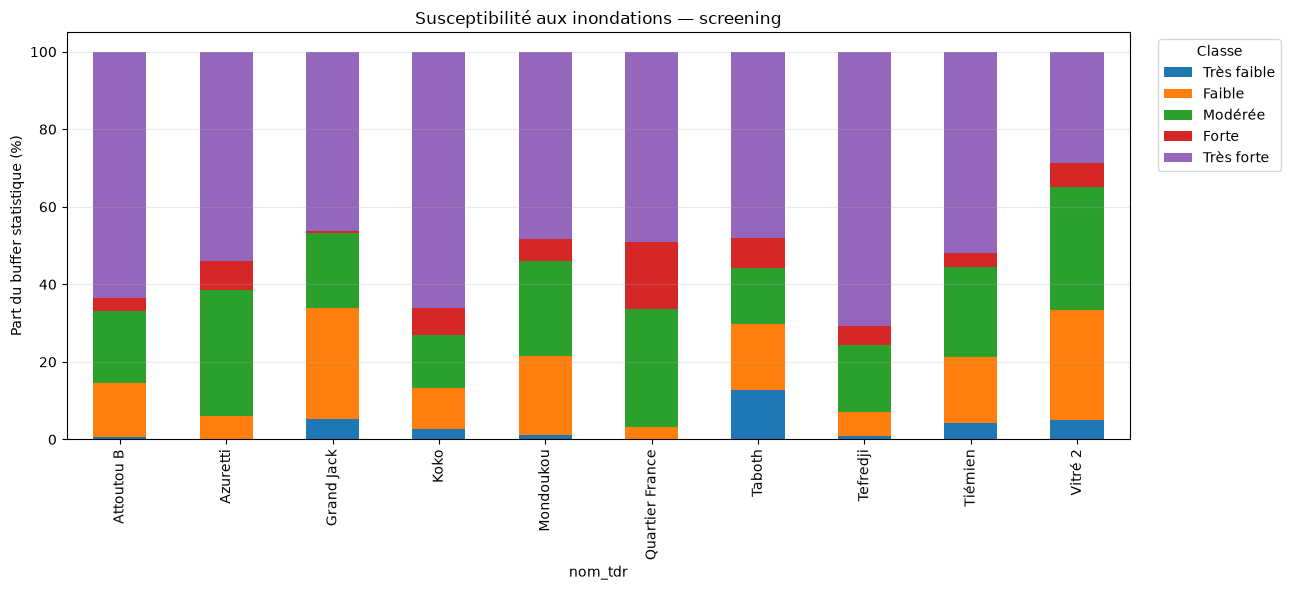

In [ ]:
flood_area_fc = grouped_class_area_fc(flood_class, ee_stats, scale=30)
flood_info = flood_area_fc.getInfo()["features"]
flood_rows = []
for feat in flood_info:
    p = feat["properties"]
    for g in (p.get("class_areas") or []):
        flood_rows.append({
            "nom_tdr": p.get("nom_tdr"),
            "zone_tdr": p.get("zone_tdr"),
            "class_id": int(g["class"]),
            "area_km2": float(g["sum"])
        })
flood_area_df = pd.DataFrame(flood_rows)
flood_area_df["classe_risque"] = flood_area_df["class_id"].map({
    1:"Très faible",2:"Faible",3:"Modérée",4:"Forte",5:"Très forte"
})
flood_area_df.to_csv(FOLDERS["tables"] / "susceptibilite_inondation_par_communaute.csv",
                     index=False, encoding="utf-8-sig")

pivot = flood_area_df.pivot_table(
    index="nom_tdr", columns="classe_risque", values="area_km2", aggfunc="sum", fill_value=0
)
order = [c for c in ["Très faible","Faible","Modérée","Forte","Très forte"] if c in pivot.columns]
pivot = pivot[order]
share = pivot.div(pivot.sum(axis=1), axis=0) * 100

ax = share.plot(kind="bar", stacked=True, figsize=NATURE_COL2)
ax.set_ylabel("Part du buffer statistique (%)")
ax.set_title("Susceptibilité aux inondations — screening")
ax.legend(title="Classe", bbox_to_anchor=(1.02,1), loc="upper left")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(FOLDERS["figures"] / "06_susceptibilite_inondation.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

## 12. Climat : CHIRPS et ERA5-Land

Objectifs :
- climatologie mensuelle de pluie ;
- tendance interannuelle de pluie ;
- climatologie mensuelle de température ;
- tendance interannuelle de température.

**Échelle :** ces données sont adaptées à une analyse climatique régionale, pas à la discrimination fine entre parcelles voisines.

In [ ]:
CHIRPS = ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY")
ERA5L = ee.ImageCollection("ECMWF/ERA5_LAND/MONTHLY_AGGR")

clim_start_year = int(CLIMATE_START[:4])
clim_end_year = LAST_COMPLETE_YEAR
baseline_end_year = int(CLIMATE_BASELINE_END[:4])

def monthly_chirps_images(start_year, end_year):
    images = []
    for year in range(start_year, end_year + 1):
        for month in range(1, 13):
            start = pd.Timestamp(year=year, month=month, day=1)
            end = start + pd.offsets.MonthBegin(1)
            img = (
                CHIRPS.filterDate(start.date().isoformat(), end.date().isoformat())
                .sum()
                .rename("rain_mm")
                .set({"year": year, "month": month, "system:time_start": int(start.timestamp()*1000)})
            )
            images.append(img)
    return ee.ImageCollection.fromImages(images)

chirps_monthly = monthly_chirps_images(clim_start_year, clim_end_year)

,zone_tdr,month,rain_mm
0,Grand-Bassam,1,20.910062
1,Jacqueville,1,21.812315
2,Grand-Bassam,2,37.709226
3,Jacqueville,2,34.242988
4,Grand-Bassam,3,95.070309


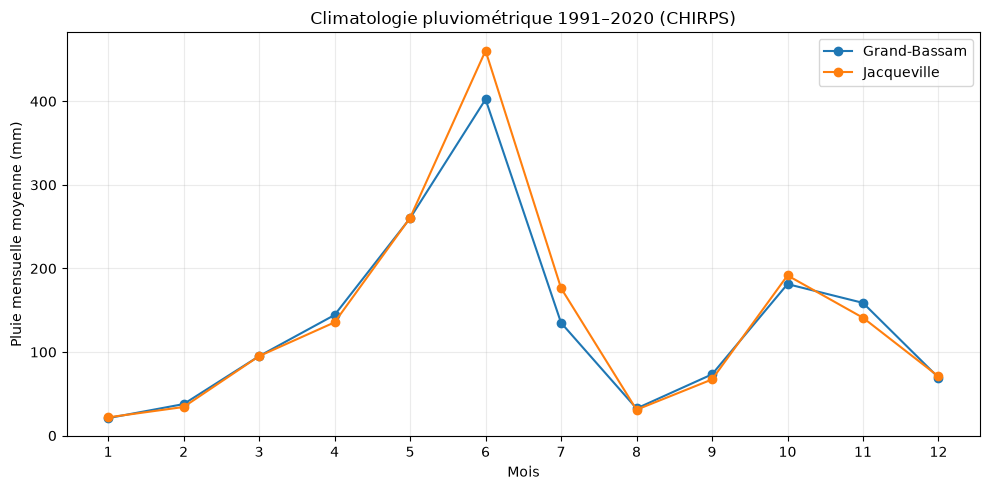

In [ ]:
# Climatologie mensuelle 1991-2020 par zone
rain_clim_rows = []
for month in range(1, 13):
    img = (
        chirps_monthly
        .filter(ee.Filter.calendarRange(clim_start_year, baseline_end_year, "year"))
        .filter(ee.Filter.eq("month", month))
        .mean()
    )
    fc = img.reduceRegions(ee_zones, ee.Reducer.mean(), 5500)
    for feat in fc.getInfo()["features"]:
        p = feat["properties"]
        rain_clim_rows.append({
            "zone_tdr": p.get("zone_tdr"),
            "month": month,
            "rain_mm": p.get("mean")
        })

rain_clim = pd.DataFrame(rain_clim_rows)
display(rain_clim.head())

fig, ax = plt.subplots(figsize=NATURE_COL2)
for zone, grp in rain_clim.groupby("zone_tdr"):
    ax.plot(grp["month"], grp["rain_mm"], marker="o", label=zone)
ax.set_xticks(range(1,13))
ax.set_xlabel("Mois")
ax.set_ylabel("Pluie mensuelle moyenne (mm)")
ax.set_title("Climatologie pluviométrique 1991–2020 (CHIRPS)")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(FOLDERS["figures"] / "07_climatologie_pluie.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

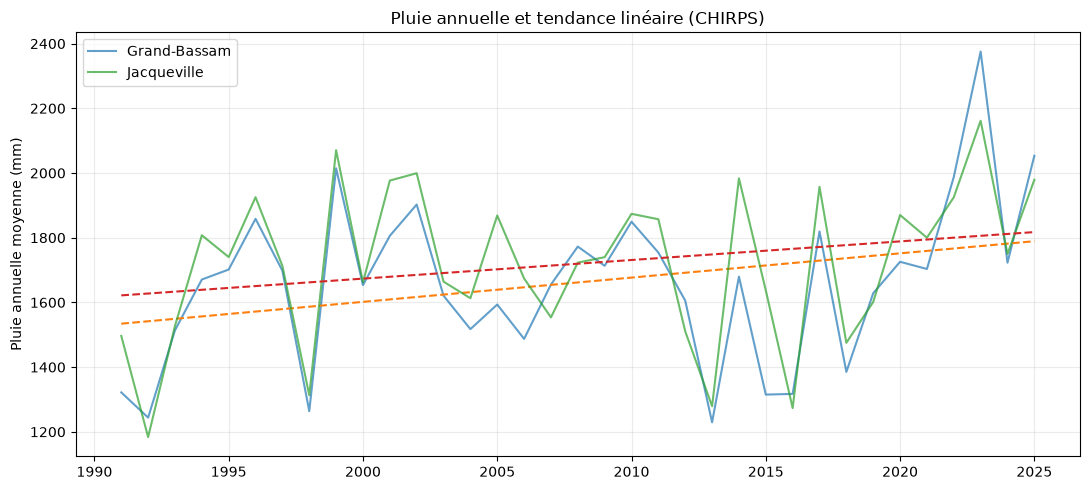

,zone_tdr,slope_mm_per_year,p_value,r2
0,Grand-Bassam,7.497958,0.073688,0.093717
1,Jacqueville,5.754713,0.153703,0.060687


In [ ]:
# Totaux annuels de pluie par zone
rain_annual_rows = []
for year in range(clim_start_year, clim_end_year + 1):
    annual = (
        CHIRPS
        .filterDate(f"{year}-01-01", f"{year+1}-01-01")
        .sum()
        .rename("rain_mm")
    )
    fc = annual.reduceRegions(ee_zones, ee.Reducer.mean(), 5500)
    for feat in fc.getInfo()["features"]:
        p = feat["properties"]
        rain_annual_rows.append({
            "year": year,
            "zone_tdr": p.get("zone_tdr"),
            "rain_mm": p.get("mean")
        })

rain_annual = pd.DataFrame(rain_annual_rows)
rain_annual.to_csv(FOLDERS["tables"] / "pluie_annuelle_chirps.csv", index=False, encoding="utf-8-sig")

fig, ax = plt.subplots(figsize=NATURE_COL2)
trend_rows = []
for zone, grp in rain_annual.groupby("zone_tdr"):
    grp = grp.dropna().sort_values("year")
    ax.plot(grp["year"], grp["rain_mm"], alpha=0.7, label=zone)
    if len(grp) >= 10:
        reg = stats.linregress(grp["year"], grp["rain_mm"])
        ax.plot(grp["year"], reg.intercept + reg.slope*grp["year"], linestyle="--")
        trend_rows.append({
            "zone_tdr": zone,
            "slope_mm_per_year": reg.slope,
            "p_value": reg.pvalue,
            "r2": reg.rvalue**2
        })

ax.set_ylabel("Pluie annuelle moyenne (mm)")
ax.set_title("Pluie annuelle et tendance linéaire (CHIRPS)")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(FOLDERS["figures"] / "08_tendance_pluie.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

rain_trends = pd.DataFrame(trend_rows)
display(rain_trends)

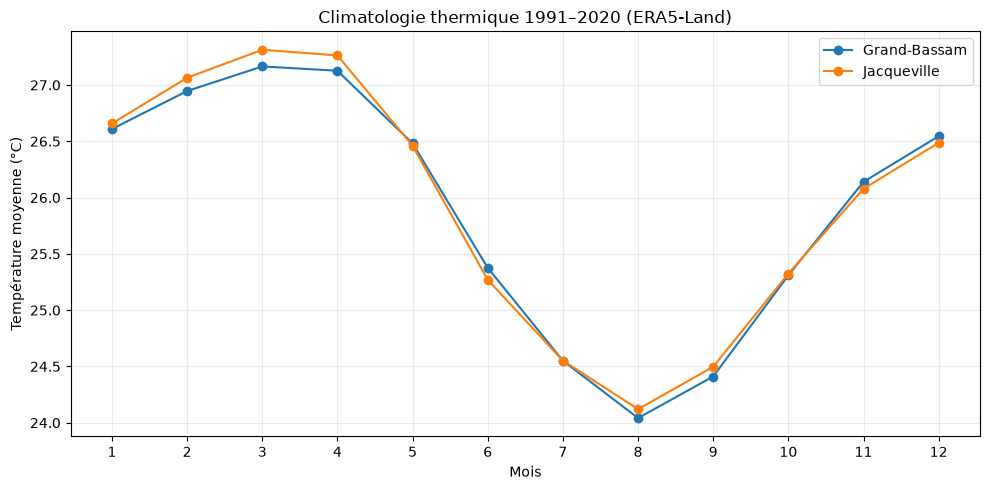

In [ ]:
# Température mensuelle moyenne — ERA5-Land
era_clim = (
    ERA5L
    .filterDate(CLIMATE_START, CLIMATE_BASELINE_END)
    .select("temperature_2m")
)

temp_clim_rows = []
for month in range(1, 13):
    img_c = (
        era_clim
        .filter(ee.Filter.calendarRange(month, month, "month"))
        .mean()
        .subtract(273.15)
        .rename("temp_c")
    )
    fc = img_c.reduceRegions(ee_zones, ee.Reducer.mean(), 10000)
    for feat in fc.getInfo()["features"]:
        p = feat["properties"]
        temp_clim_rows.append({
            "zone_tdr": p.get("zone_tdr"),
            "month": month,
            "temp_c": p.get("mean")
        })

temp_clim = pd.DataFrame(temp_clim_rows)

fig, ax = plt.subplots(figsize=NATURE_COL2)
for zone, grp in temp_clim.groupby("zone_tdr"):
    ax.plot(grp["month"], grp["temp_c"], marker="o", label=zone)
ax.set_xticks(range(1,13))
ax.set_xlabel("Mois")
ax.set_ylabel("Température moyenne (°C)")
ax.set_title("Climatologie thermique 1991–2020 (ERA5-Land)")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(FOLDERS["figures"] / "09_climatologie_temperature.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

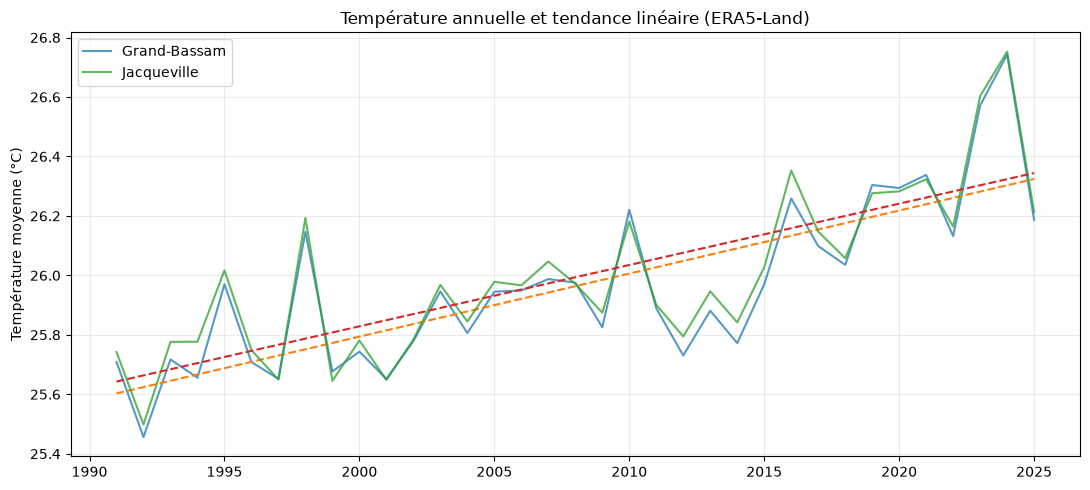

,zone_tdr,slope_degC_per_year,slope_degC_per_decade,p_value,r2
0,Grand-Bassam,0.021212,0.212125,4.888014e-08,0.599300
1,Jacqueville,0.020628,0.206277,6.055749e-08,0.594161


In [ ]:
temp_annual_rows = []
for year in range(clim_start_year, clim_end_year + 1):
    annual_c = (
        ERA5L
        .filterDate(f"{year}-01-01", f"{year+1}-01-01")
        .select("temperature_2m")
        .mean()
        .subtract(273.15)
        .rename("temp_c")
    )
    fc = annual_c.reduceRegions(ee_zones, ee.Reducer.mean(), 10000)
    for feat in fc.getInfo()["features"]:
        p = feat["properties"]
        temp_annual_rows.append({
            "year": year,
            "zone_tdr": p.get("zone_tdr"),
            "temp_c": p.get("mean")
        })

temp_annual = pd.DataFrame(temp_annual_rows)
temp_annual.to_csv(FOLDERS["tables"] / "temperature_annuelle_era5land.csv",
                   index=False, encoding="utf-8-sig")

fig, ax = plt.subplots(figsize=NATURE_COL2)
temp_trend_rows = []
for zone, grp in temp_annual.groupby("zone_tdr"):
    grp = grp.dropna().sort_values("year")
    ax.plot(grp["year"], grp["temp_c"], alpha=0.75, label=zone)
    if len(grp) >= 10:
        reg = stats.linregress(grp["year"], grp["temp_c"])
        ax.plot(grp["year"], reg.intercept + reg.slope*grp["year"], linestyle="--")
        temp_trend_rows.append({
            "zone_tdr": zone,
            "slope_degC_per_year": reg.slope,
            "slope_degC_per_decade": reg.slope * 10,
            "p_value": reg.pvalue,
            "r2": reg.rvalue**2
        })
ax.set_ylabel("Température moyenne (°C)")
ax.set_title("Température annuelle et tendance linéaire (ERA5-Land)")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(FOLDERS["figures"] / "10_tendance_temperature.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

temp_trends = pd.DataFrame(temp_trend_rows)
display(temp_trends)

# PARTIE D — Réseaux, marchés et accessibilité

## 13. OpenStreetMap avec OSMnx

Le workflow télécharge et met en cache :

- réseau routier carrossable ;
- marchés (`amenity=marketplace`) ;
- points de transport utiles, si disponibles.

**Attention :** l'absence d'un objet dans OSM n'implique pas son absence réelle. Les marchés et débarcadères doivent être complétés par les données terrain/projet.

In [ ]:
if ox is None or nx is None:
    print("OSMnx/NetworkX non installés — cette partie sera à exécuter après installation.")
else:
    ox.settings.use_cache = True
    ox.settings.cache_folder = str(FOLDERS["raw_osm"] / "cache")
    ox.settings.log_console = False

OSM_GPKG = FOLDERS["raw_osm"] / "osm_context.gpkg"

def safe_osm_features(polygon_wgs84, tags):
    try:
        gdf = ox.features.features_from_polygon(polygon_wgs84, tags)
        if gdf is None or gdf.empty:
            return gpd.GeoDataFrame(geometry=[], crs=WGS84)
        return gdf.reset_index().to_crs(WGS84)
    except Exception as exc:
        print("OSM features erreur :", exc)
        return gpd.GeoDataFrame(geometry=[], crs=WGS84)

osm_graphs = {}
osm_edges_all = []
osm_nodes_all = []
markets_all = []

if ox is not None:
    for _, zone_row in zones.to_crs(WGS84).iterrows():
        zone_name = zone_row["zone_tdr"]
        poly = zone_row.geometry
        print("Téléchargement OSM :", zone_name)

        try:
            G = ox.graph.graph_from_polygon(poly, network_type="drive", simplify=True, retain_all=True)
            G = ox.routing.add_edge_speeds(G, fallback=30)
            G = ox.routing.add_edge_travel_times(G)
            osm_graphs[zone_name] = G

            nodes, edges = ox.convert.graph_to_gdfs(G)
            nodes = nodes.reset_index()
            edges = edges.reset_index()
            nodes["zone_tdr"] = zone_name
            edges["zone_tdr"] = zone_name
            osm_nodes_all.append(nodes)
            osm_edges_all.append(edges)
        except Exception as exc:
            print("Réseau routier indisponible pour", zone_name, ":", exc)

        markets = safe_osm_features(poly, {"amenity":"marketplace"})
        if not markets.empty:
            markets["zone_tdr"] = zone_name
            markets_all.append(markets)

    roads_nodes = pd.concat(osm_nodes_all, ignore_index=True) if osm_nodes_all else gpd.GeoDataFrame(geometry=[], crs=WGS84)
    roads_edges = pd.concat(osm_edges_all, ignore_index=True) if osm_edges_all else gpd.GeoDataFrame(geometry=[], crs=WGS84)
    markets = pd.concat(markets_all, ignore_index=True) if markets_all else gpd.GeoDataFrame(geometry=[], crs=WGS84)

    if not roads_nodes.empty:
        roads_nodes = gpd.GeoDataFrame(roads_nodes, geometry="geometry", crs=WGS84)
        roads_nodes.to_file(OSM_GPKG, layer="road_nodes", driver="GPKG")
    if not roads_edges.empty:
        roads_edges = gpd.GeoDataFrame(roads_edges, geometry="geometry", crs=WGS84)
        roads_edges.to_file(OSM_GPKG, layer="road_edges", driver="GPKG")
    if not markets.empty:
        markets = gpd.GeoDataFrame(markets, geometry="geometry", crs=WGS84)
        markets.to_file(OSM_GPKG, layer="markets_osm", driver="GPKG")

    print("OSM sauvegardé :", OSM_GPKG)

Téléchargement OSM : Grand-Bassam
Téléchargement OSM : Jacqueville
OSM sauvegardé : c:\Users\Ordinateur\OneDrive\DR NOUFOU - HFHCI - OPPORTUNITÉS DE MOYENS DE SUBSISTANCE\HFHI_resilience_cotiere_SIG\01_data\raw\osm\osm_context.gpkg


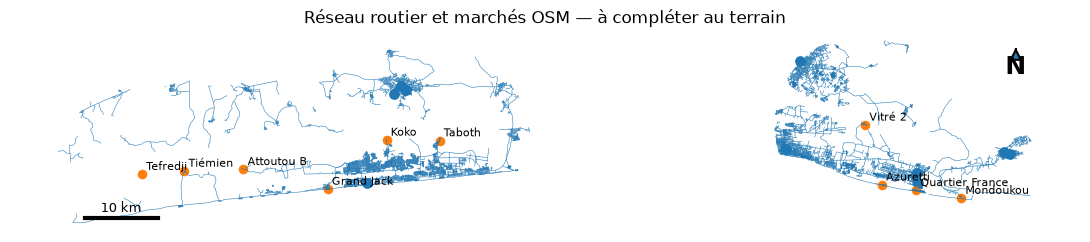

In [ ]:
# Carte statique des routes et marchés
if ox is not None and "roads_edges" in globals() and not roads_edges.empty:
    fig, ax = plt.subplots(figsize=MAP_FIGSIZE)
    roads_edges.to_crs(METRIC_CRS).plot(ax=ax, linewidth=0.35, alpha=0.6)
    if "markets" in globals() and not markets.empty:
        mk = markets.copy()
        # Pour les polygones, on utilise un point représentatif pour l'affichage.
        mk["geometry"] = mk.geometry.representative_point()
        mk.to_crs(METRIC_CRS).plot(ax=ax, markersize=45)
    localites_utm.plot(ax=ax, markersize=35)
    for _, row in localites_utm.iterrows():
        ax.annotate(row["nom_tdr"], (row.geometry.x,row.geometry.y),
                    xytext=(3,3), textcoords="offset points", fontsize=8)
    add_north_arrow(ax)
    add_scalebar(ax, 10)
    ax.set_title("Réseau routier et marchés OSM — à compléter au terrain")
    ax.set_axis_off()
    plt.tight_layout()
    plt.savefig(FOLDERS["maps"] / "11_routes_marches_osm.png", dpi=FIG_DPI, bbox_inches="tight")
    plt.show()

## 14. Temps d'accès aux marchés

Le calcul utilise le réseau routier OSM et des vitesses imputées. Il représente un **temps de trajet théorique en circulation libre**.

Il faut compléter la couche des marchés avec les marchés réels identifiés par l'équipe agroéconomique.

,nom_tdr,zone_tdr,market_time_min
0,Quartier France,Grand-Bassam,1.502191
3,Azuretti,Grand-Bassam,6.193905
1,Mondoukou,Grand-Bassam,8.746717
9,Grand Jack,Jacqueville,11.280030
6,Koko,Jacqueville,15.231128
4,Taboth,Jacqueville,16.548477
2,Vitré 2,Grand-Bassam,21.845546
5,Attoutou B,Jacqueville,39.299497
8,Tiémien,Jacqueville,58.765309
7,Tefredji,Jacqueville,NaN


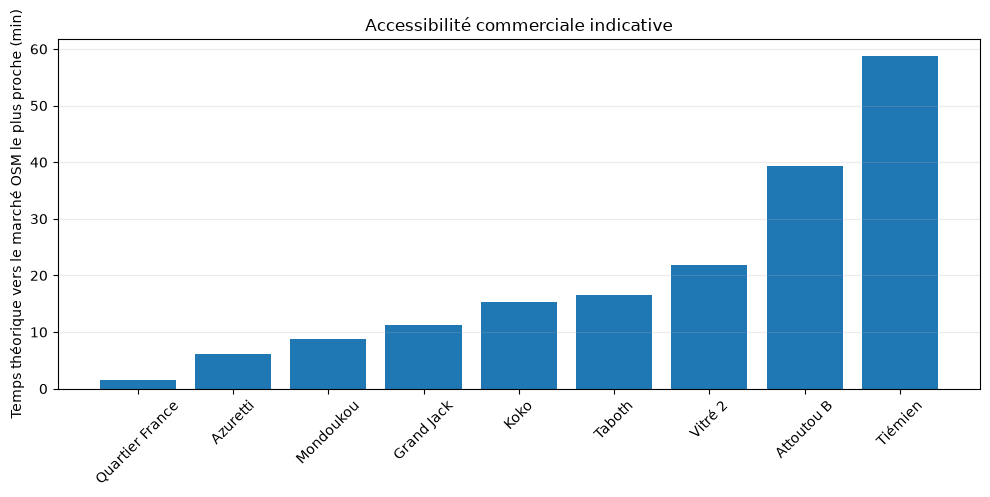

In [ ]:
def point_from_any_geometry(geom):
    if geom is None or geom.is_empty:
        return None
    if geom.geom_type == "Point":
        return geom
    return geom.representative_point()

access_rows = []

if ox is not None and "markets" in globals() and not markets.empty:
    market_pts = markets.copy()
    market_pts["geometry"] = market_pts.geometry.apply(point_from_any_geometry)

    for zone_name, G in osm_graphs.items():
        locs = localites[localites["zone_tdr"] == zone_name].copy()
        mk = market_pts[market_pts["zone_tdr"] == zone_name].copy()

        if locs.empty or mk.empty:
            continue

        market_nodes = ox.distance.nearest_nodes(
            G,
            X=mk.geometry.x.to_numpy(),
            Y=mk.geometry.y.to_numpy()
        )
        market_nodes = list(np.atleast_1d(market_nodes))

        for _, row in locs.iterrows():
            origin = ox.distance.nearest_nodes(G, X=row.geometry.x, Y=row.geometry.y)
            lengths = nx.single_source_dijkstra_path_length(G, origin, weight="travel_time")
            feasible = [lengths.get(n) for n in market_nodes if n in lengths]
            best_sec = min(feasible) if feasible else np.nan

            access_rows.append({
                "nom_tdr": row["nom_tdr"],
                "zone_tdr": zone_name,
                "market_time_min": best_sec / 60 if pd.notna(best_sec) else np.nan
            })

market_access = pd.DataFrame(access_rows)
if not market_access.empty:
    market_access.to_csv(FOLDERS["tables"] / "temps_acces_marche_osm.csv",
                         index=False, encoding="utf-8-sig")
    display(market_access.sort_values("market_time_min"))

    fig, ax = plt.subplots(figsize=NATURE_COL2)
    d = market_access.sort_values("market_time_min")
    ax.bar(d["nom_tdr"], d["market_time_min"])
    ax.set_ylabel("Temps théorique vers le marché OSM le plus proche (min)")
    ax.set_title("Accessibilité commerciale indicative")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.savefig(FOLDERS["figures"] / "12_accessibilite_marche.png",
                dpi=FIG_DPI, bbox_inches="tight")
    plt.show()
else:
    print("Aucun marché OSM exploitable. Importer une couche terrain de marchés avant le calcul.")

## 15. Rasterisation de l'accessibilité pour l'analyse multicritère

Les routes sont dissoutes/simplifiées avant conversion dans Earth Engine afin de limiter le volume d'objets.

Si OSM est incomplet, remplacer les couches par des données projet ou terrain.

In [ ]:
road_dist = None
market_dist = None


def points_gdf_to_ee_fc(gdf, id_field="name"):
    """Convertit un GeoDataFrame de points (WGS84) en FeatureCollection EE.

    Contourne un bug d'incompatibilite de version entre geemap.gdf_to_ee()
    et l'API Earth Engine actuelle : geojson_to_ee(..., geodesic=True) leve
    `Unrecognized arguments {'geodesic'} to function:
    GeometryConstructors.MultiPoint` pour des geometries ponctuelles avec
    les versions recentes du serveur EE. On construit ici directement un
    ee.Geometry.MultiPoint (sans argument geodesic) a partir des
    coordonnees, ce qui evite l'appel problematique.
    """
    gdf = gdf.to_crs(WGS84)
    coords = [[float(g.x), float(g.y)] for g in gdf.geometry if g is not None and not g.is_empty]
    if not coords:
        raise ValueError("Aucune geometrie ponctuelle valide a convertir.")
    geom_ee = ee.Geometry.MultiPoint(coords)
    label = gdf[id_field].iloc[0] if id_field in gdf.columns and len(gdf) else "points"
    return ee.FeatureCollection([ee.Feature(geom_ee, {"name": label})])


if ox is not None and "roads_edges" in globals() and not roads_edges.empty:
    major_roads = roads_edges.to_crs(METRIC_CRS).copy()

    # Dissolution en une géométrie simplifiée pour transfert vers GEE.
    road_union = unary_union(major_roads.geometry).simplify(20)
    road_gdf = gpd.GeoDataFrame({"name":["roads"]}, geometry=[road_union], crs=METRIC_CRS).to_crs(WGS84)
    road_fc = geemap.gdf_to_ee(road_gdf)

    road_source = ee.Image(0).byte().paint(road_fc, 1, 2)
    road_dist = (
        road_source.distance(ee.Kernel.euclidean(10000, "meters"), skipMasked=False)
        .unmask(10000)
        .rename("road_dist_m")
    )

if "markets" in globals() and not markets.empty:
    mk = markets.copy()
    mk["geometry"] = mk.geometry.apply(point_from_any_geometry)
    mk["name"] = "markets"
    # Conversion directe en MultiPoint EE : evite l'erreur
    # "Unrecognized arguments {'geodesic'}" produite par geemap.gdf_to_ee()
    # sur ce type de geometrie avec les versions recentes de l'API EE.
    market_fc = points_gdf_to_ee_fc(mk)

    market_source = ee.Image(0).byte().paint(market_fc, 1)
    market_dist = (
        market_source.distance(ee.Kernel.euclidean(30000, "meters"), skipMasked=False)
        .unmask(30000)
        .rename("market_dist_m")
    )

print("road_dist :", road_dist is not None)
print("market_dist :", market_dist is not None)

# PARTIE E — Population, terrain, analyses multicritères et opportunités

## 16. Pression/demande humaine — GHSL

La population 2025 de GHSL est une **projection raster**, utile comme variable de contexte. Elle ne remplace pas les recensements ou données communautaires.

In [ ]:
ghsl_pop_2025 = ee.Image("JRC/GHSL/P2023A/GHS_POP/2025").select("population_count").clip(region_geometry)

def population_table(pop_img, features):
    def fn(ft):
        val = pop_img.reduceRegion(
            ee.Reducer.sum(), ft.geometry(), 100,
            maxPixels=1e10, tileScale=4
        ).get("population_count")
        return ft.set("population_2025_proxy", val)
    info = features.map(fn).getInfo()["features"]
    return pd.DataFrame([f["properties"] for f in info])

pop_df = population_table(ghsl_pop_2025, ee_stats)
pop_df[["nom_tdr","zone_tdr","population_2025_proxy"]].to_csv(
    FOLDERS["tables"] / "population_proxy_ghsl.csv",
    index=False, encoding="utf-8-sig"
)
display(pop_df[["nom_tdr","zone_tdr","population_2025_proxy"]]
        .sort_values("population_2025_proxy", ascending=False))

,nom_tdr,zone_tdr,population_2025_proxy
6,Quartier France,Grand-Bassam,47602.644119
9,Azuretti,Grand-Bassam,14855.576019
0,Taboth,Jacqueville,4117.440746
1,Attoutou B,Jacqueville,3429.533268
2,Koko,Jacqueville,2163.153108
7,Mondoukou,Grand-Bassam,1671.560995
8,Vitré 2,Grand-Bassam,1380.139746
5,Grand Jack,Jacqueville,996.449841
3,Tefredji,Jacqueville,259.478923
4,Tiémien,Jacqueville,236.241212


## 17. Matrice spatiale multicritère (MCE)

### Principe

Tous les facteurs sont ramenés à l'intervalle `[0, 1]` :
- `0` = défavorable ;
- `1` = favorable.

Les poids sont **explicites et modifiables**. Ils ne doivent pas être présentés comme des vérités universelles : ils servent à rendre les arbitrages transparents.

### Options cartographiées

1. maraîchage ;
2. manioc ;
3. aquaculture — screening ;
4. unité de transformation / coco — **facteur ressource coco à compléter** ;
5. services verts / restauration de zones humides-mangroves.

Le résultat sert à **prioriser les visites et vérifications**, pas à autoriser une implantation.

### 17.1 Ressources coco : couche terrain à intégrer

Aucun produit global utilisé ici ne permet de distinguer de manière suffisamment fiable les **cocoteraies** ou les **gisements de résidus de coco** à l'échelle décisionnelle de la mission.

Créer ou fournir :

`01_data/raw/field/coconut_resources.gpkg`

avec au minimum :
- géométrie ;
- `resource_type` ;
- `estimated_volume` si disponible ;
- `seasonality` ;
- `access_notes`.

Si cette couche existe, le notebook remplace le facteur neutre `0.5` par un score de proximité aux ressources.

In [ ]:
COCONUT_RESOURCE_FILE = FOLDERS["raw_field"] / "coconut_resources.gpkg"

def coconut_resource_factor(max_distance_m=15000):
    if not COCONUT_RESOURCE_FILE.exists():
        print(
            "Ressources coco non cartographiées : facteur neutre 0.5. "
            "Ne pas finaliser l'aptitude transformation/coco dans cet état."
        )
        return ee.Image.constant(0.5).rename("coconut_resource_score")

    coco = gpd.read_file(COCONUT_RESOURCE_FILE)
    if coco.crs is None:
        raise ValueError("La couche coconut_resources.gpkg n'a pas de CRS.")
    coco = coco.to_crs(WGS84)

    # Convertir polygones/lignes en points représentatifs pour un facteur de proximité.
    coco["geometry"] = coco.geometry.apply(point_from_any_geometry)
    coco["name"] = "coconut_resources"
    # points_gdf_to_ee_fc() (définie section 15) contourne le même bug
    # geemap.gdf_to_ee() / argument "geodesic" que pour les marchés.
    coco_fc = points_gdf_to_ee_fc(coco)

    source = ee.Image(0).byte().paint(coco_fc, 1)
    distance = (
        source.distance(
            ee.Kernel.euclidean(max_distance_m, "meters"),
            skipMasked=False
        )
        .unmask(max_distance_m)
        .rename("coco_resource_dist_m")
    )
    return ee.Image(1).subtract(distance.divide(max_distance_m)).clamp(0,1).rename("coconut_resource_score")

In [ ]:
def inverse_distance_score(distance_img, max_distance):
    if distance_img is None:
        return ee.Image.constant(0.5)
    return ee.Image(1).subtract(distance_img.divide(max_distance)).clamp(0,1)

road_access = inverse_distance_score(road_dist, 10000).rename("road_access")
market_access_img = inverse_distance_score(market_dist, 30000).rename("market_access")
water_access = inverse_distance_score(dist_water_3000, 3000).rename("water_access")
slope_score = ee.Image(1).subtract(scale_01(slope, 0, 8)).rename("slope_score")
flood_safety = ee.Image(1).subtract(flood_susceptibility).rename("flood_safety")

open_land_score = (
    dw_probs.select("crops").multiply(0.45)
    .add(dw_probs.select("grass").multiply(0.20))
    .add(dw_probs.select("shrub_and_scrub").multiply(0.20))
    .add(dw_probs.select("bare").multiply(0.15))
    .rename("open_land_score")
)

# Population environnante ~2 km : facteur d'accès à la main-d'œuvre / demande locale
pop_near = ghsl_pop_2025.reduceNeighborhood(
    reducer=ee.Reducer.sum(),
    kernel=ee.Kernel.circle(radius=2000, units="meters")
).rename("pop_2km")

settlement_access = pop_near.add(1).log().unitScale(0, 10).clamp(0,1).rename("settlement_access")

hard_exclusion = water_mask.Or(built_mask).Or(mangrove_proxy)
agri_mask = spatial_candidate.And(mangrove_proxy.Not())

# Dégradation humide : valeur positive quand le proxy était plus fort au baseline qu'au récent.
wet_degradation = wet_tree_base.subtract(wet_tree_now).unitScale(0, 0.35).clamp(0,1).rename("wet_degradation")
seasonal_water = water_seasonality.unitScale(1,12).clamp(0,1).rename("seasonal_water")

In [ ]:
WEIGHTS = {
    "maraichage": {
        "open_land": 0.25, "water": 0.20, "road": 0.15,
        "market": 0.15, "flood_safety": 0.15, "slope": 0.10
    },
    "manioc": {
        "open_land": 0.30, "water": 0.10, "road": 0.15,
        "market": 0.15, "flood_safety": 0.15, "slope": 0.15
    },
    "aquaculture": {
        "water": 0.30, "road": 0.15, "market": 0.15,
        "flood_safety": 0.10, "slope": 0.10, "open_land": 0.20
    },
    "transformation_coco": {
        "road": 0.25, "market": 0.25, "settlement": 0.20,
        "flood_safety": 0.20, "resource_coco": 0.10
    },
    "services_verts": {
        "wet_degradation": 0.30, "water": 0.20, "seasonal_water": 0.20,
        "low_built": 0.15, "flooded_veg": 0.15
    }
}

# Facteur coco : calculé depuis une couche terrain si disponible, sinon neutre 0.5.
coconut_resource_score = coconut_resource_factor(max_distance_m=15000)
low_built_score = ee.Image(1).subtract(ghsl_built.unitScale(0,100).clamp(0,1)).rename("low_built")
flooded_veg_score = dw_probs.select("flooded_vegetation").rename("flooded_veg_score")

maraichage = (
    open_land_score.multiply(0.25)
    .add(water_access.multiply(0.20))
    .add(road_access.multiply(0.15))
    .add(market_access_img.multiply(0.15))
    .add(flood_safety.multiply(0.15))
    .add(slope_score.multiply(0.10))
    .updateMask(agri_mask)
    .rename("maraichage")
)

manioc = (
    open_land_score.multiply(0.30)
    .add(water_access.multiply(0.10))
    .add(road_access.multiply(0.15))
    .add(market_access_img.multiply(0.15))
    .add(flood_safety.multiply(0.15))
    .add(slope_score.multiply(0.15))
    .updateMask(agri_mask)
    .rename("manioc")
)

aquaculture = (
    water_access.multiply(0.30)
    .add(road_access.multiply(0.15))
    .add(market_access_img.multiply(0.15))
    .add(flood_safety.multiply(0.10))
    .add(slope_score.multiply(0.10))
    .add(open_land_score.multiply(0.20))
    .updateMask(hard_exclusion.Not())
    .rename("aquaculture")
)

transformation_coco = (
    road_access.multiply(0.25)
    .add(market_access_img.multiply(0.25))
    .add(settlement_access.multiply(0.20))
    .add(flood_safety.multiply(0.20))
    .add(coconut_resource_score.multiply(0.10))
    .updateMask(water_mask.Or(mangrove_proxy).Not())
    .rename("transformation_coco")
)

services_verts = (
    wet_degradation.multiply(0.30)
    .add(water_access.multiply(0.20))
    .add(seasonal_water.multiply(0.20))
    .add(low_built_score.multiply(0.15))
    .add(flooded_veg_score.multiply(0.15))
    .updateMask(built_mask.Not())
    .rename("services_verts")
)

SUITABILITY = {
    "maraichage": maraichage,
    "manioc": manioc,
    "aquaculture": aquaculture,
    "transformation_coco": transformation_coco,
    "services_verts": services_verts,
}

Ressources coco non cartographiées : facteur neutre 0.5. Ne pas finaliser l'aptitude transformation/coco dans cet état.


In [ ]:
Map_mce = geemap.Map()
Map_mce.centerObject(ee_region, 9)
Map_mce.add_basemap("SATELLITE")
for i, (name, image) in enumerate(SUITABILITY.items()):
    Map_mce.addLayer(image, {"min":0,"max":1}, name, shown=(i == 0))
Map_mce.addLayer(ee_localites.style(**{"color":"white","pointSize":5}), {}, "Localités")
Map_mce

Map(center=[5.226528750906934, -4.2184593267832655], controls=(WidgetControl(options=['position', 'transparent…

In [ ]:
# --- Rendu statique de la carte interactive ci-dessus ---
render_static_ee_map(
    [(img, {"min": 0, "max": 1, "palette": ["#f7f7f7", "#fee08b", "#1a9850"]}, name)
     for name, img in SUITABILITY.items()],
    region_geometry, "Aptitude spatiale par option - MCE (rendu statique)",
    FOLDERS["maps"] / "10_15_aptitude_options_static.png",
    points=localites,
)

## 18. Scores moyens par communauté et heatmap

Les scores moyens servent à rapprocher l'analyse spatiale de la **matrice d'opportunités** des TDR.

Ne pas confondre :
- score spatial ;
- rentabilité économique ;
- faisabilité juridique ;
- acceptabilité sociale ;
- préférence femmes/jeunes.

Ces dimensions doivent rester séparées puis combinées dans la matrice finale.

In [ ]:
def scores_for_image(image, score_name, features, scale=20, tile_scale=8):
    """Calcule la moyenne d'une image de score sur chaque entité en un seul
    reduceRegions() par image, plutôt que par un enchaînement de .map()
    imbriqués (source du `Computation timed out` observé à l'exécution :
    chaque option ajoutait une couche supplémentaire au graphe de calcul
    cumulé avant un unique getInfo() final)."""
    try:
        fc = image.reduceRegions(
            collection=features,
            reducer=ee.Reducer.mean(),
            scale=scale,
            tileScale=tile_scale,
        )
        info = fc.getInfo()["features"]
    except Exception as exc:
        print(f"  -> échec à tileScale={tile_scale} pour {score_name} ({exc}); "
              "nouvelle tentative à échelle réduite / tileScale plus élevé.")
        fc = image.reduceRegions(
            collection=features,
            reducer=ee.Reducer.mean(),
            scale=scale * 2,
            tileScale=16,
        )
        info = fc.getInfo()["features"]

    rows = []
    for feat in info:
        p = feat["properties"]
        rows.append({
            "nom_tdr": p.get("nom_tdr"),
            "zone_tdr": p.get("zone_tdr"),
            score_name: p.get("mean"),
        })
    return pd.DataFrame(rows)


score_table = None
for name, img in SUITABILITY.items():
    print("Calcul du score moyen par communauté :", name)
    df = scores_for_image(img, name, ee_stats, scale=20)
    score_table = df if score_table is None else score_table.merge(df, on=["nom_tdr", "zone_tdr"], how="outer")

score_cols = list(SUITABILITY.keys())
for c in score_cols:
    score_table[c] = pd.to_numeric(score_table[c], errors="coerce")

score_table.to_csv(FOLDERS["tables"] / "scores_spatiaux_opportunites.csv",
                   index=False, encoding="utf-8-sig")
display(score_table)

In [ ]:
# Heatmap Matplotlib sans seaborn
matrix = score_table.set_index("nom_tdr")[score_cols]

fig, ax = plt.subplots(figsize=NATURE_COL2_TALL)
im = ax.imshow(matrix.to_numpy(dtype=float), aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(len(score_cols)))
ax.set_xticklabels(score_cols, rotation=30, ha="right")
ax.set_yticks(range(len(matrix.index)))
ax.set_yticklabels(matrix.index)

for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        val = matrix.iloc[i, j]
        if pd.notna(val):
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=ax, label="Score spatial moyen 0–1")
ax.set_title("Screening spatial des options par communauté")
plt.tight_layout()
plt.savefig(FOLDERS["figures"] / "13_heatmap_scores_opportunites.png",
            dpi=FIG_DPI, bbox_inches="tight")
plt.show()

## 19. Classes de priorité spatiale et surfaces favorables

Catégories indicatives :

- 0–0,20 : très faible ;
- 0,20–0,40 : faible ;
- 0,40–0,60 : modérée ;
- 0,60–0,80 : forte ;
- 0,80–1,00 : très forte.

Pour le terrain, on recommande d'échantillonner principalement les classes **forte** et **très forte**, tout en visitant quelques sites défavorables pour tester les faux positifs/faux négatifs.

In [ ]:
def score_to_class(score_img, name):
    return (
        ee.Image(1)
        .where(score_img.gte(0.20), 2)
        .where(score_img.gte(0.40), 3)
        .where(score_img.gte(0.60), 4)
        .where(score_img.gte(0.80), 5)
        .rename(name + "_class")
        .updateMask(score_img.mask())
    )

SUITABILITY_CLASSES = {name: score_to_class(img, name) for name, img in SUITABILITY.items()}

high_area_rows = []
for name, class_img in SUITABILITY_CLASSES.items():
    high = class_img.gte(4)
    table = binary_area_table(high, ee_stats, f"{name}_high", scale=20)
    for _, r in table.iterrows():
        high_area_rows.append({
            "nom_tdr": r.get("nom_tdr"),
            "zone_tdr": r.get("zone_tdr"),
            "option": name,
            "high_suitability_ha": r.get(f"{name}_high_ha", 0),
            "total_buffer_ha": r.get("total_ha")
        })

high_area_df = pd.DataFrame(high_area_rows)
high_area_df.to_csv(FOLDERS["tables"] / "surfaces_forte_tres_forte_aptitude.csv",
                    index=False, encoding="utf-8-sig")
display(high_area_df.head(15))

## 20. Priorisation spatiale des foyers améliorés / énergie propre

L'option « foyers améliorés » n'est pas une aptitude parcellaire classique.

On peut prioriser les communautés selon :
- population/demande potentielle ;
- proximité/importance des zones de mangrove ou végétation humide ;
- indication de dégradation ;
- accessibilité logistique.

Ce score doit ensuite être combiné aux enquêtes sur les combustibles, pratiques et acceptabilité.

In [ ]:
# Statistiques communautaires nécessaires au score énergie
mang_area_df = binary_area_table(mangrove_proxy, ee_stats, "mangrove_proxy", 20)
deg_fc = reduce_mean_over_features(wet_degradation, ee_stats, "wet_degradation", 20)
deg_df = pd.DataFrame([f["properties"] for f in deg_fc.getInfo()["features"]])

energy = (
    pop_df[["nom_tdr","zone_tdr","population_2025_proxy"]]
    .merge(mang_area_df[["nom_tdr","mangrove_proxy_ha"]], on="nom_tdr", how="left")
    .merge(deg_df[["nom_tdr","wet_degradation_mean"]], on="nom_tdr", how="left")
)

if not market_access.empty:
    energy = energy.merge(market_access[["nom_tdr","market_time_min"]], on="nom_tdr", how="left")
else:
    energy["market_time_min"] = np.nan

def minmax(series, inverse=False):
    s = pd.to_numeric(series, errors="coerce")
    if s.notna().sum() <= 1 or s.max() == s.min():
        out = pd.Series(0.5, index=s.index)
    else:
        out = (s - s.min()) / (s.max() - s.min())
    return 1-out if inverse else out

energy["pop_score"] = minmax(energy["population_2025_proxy"])
energy["mangrove_score"] = minmax(energy["mangrove_proxy_ha"])
energy["degradation_score"] = minmax(energy["wet_degradation_mean"])
energy["access_score"] = minmax(energy["market_time_min"], inverse=True).fillna(0.5)

energy["clean_energy_priority"] = (
    0.35*energy["pop_score"] +
    0.25*energy["mangrove_score"] +
    0.25*energy["degradation_score"] +
    0.15*energy["access_score"]
)

energy = energy.sort_values("clean_energy_priority", ascending=False)
energy.to_csv(FOLDERS["tables"] / "priorite_foyers_ameliores_screening.csv",
              index=False, encoding="utf-8-sig")
display(energy[["nom_tdr","zone_tdr","clean_energy_priority"]])

In [ ]:
fig, ax = plt.subplots(figsize=NATURE_COL2)
ax.bar(energy["nom_tdr"], energy["clean_energy_priority"])
ax.set_ylabel("Score de priorité 0–1")
ax.set_title("Priorisation indicative — foyers améliorés / énergie propre")
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(FOLDERS["figures"] / "14_priorite_energie_propre.png",
            dpi=FIG_DPI, bbox_inches="tight")
plt.show()

# PARTIE F — Terrain, validation et export

## 21. Modèle de collecte terrain

Le fichier généré peut être converti en XLSForm/Kobo ou importé dans QField/Survey123.

La **faisabilité foncière réelle** nécessite au minimum :
- statut déclaré et détenteur/gestionnaire ;
- preuve ou document disponible ;
- conflits ou revendications ;
- superficie réellement accessible ;
- durée/conditions d'accès ;
- compatibilité avec l'activité ;
- risques d'inondation/salinité observés ;
- eau, route, marché ;
- photos et GPS ;
- préférences des femmes et des jeunes.

In [ ]:
field_columns = [
    "site_id","survey_date","enqueteur","zone_tdr","nom_tdr",
    "latitude","longitude","accuracy_m",
    "activity_option","current_land_use","estimated_area_ha",
    "land_status_reported","owner_or_manager","tenure_evidence",
    "access_conditions","conflict_or_claim_risk",
    "water_available","water_type","salinity_issue",
    "road_access_quality","market_access_notes",
    "flood_history","erosion_observed","mangrove_nearby",
    "women_interest_1_5","youth_interest_1_5",
    "technical_constraints","economic_constraints",
    "photo_1","photo_2","comments"
]

field_template = pd.DataFrame(columns=field_columns)
field_template_path = FOLDERS["raw_field"] / "field_sites_template.csv"
field_template.to_csv(field_template_path, index=False, encoding="utf-8-sig")
print("Template terrain :", field_template_path)

In [ ]:
FIELD_RESULTS = FOLDERS["raw_field"] / "field_sites_filled.csv"

def load_field_sites(path=FIELD_RESULTS):
    path = Path(path)
    if not path.exists():
        print("Fichier terrain non encore disponible :", path)
        return None
    df = pd.read_csv(path)
    required = {"latitude","longitude","nom_tdr"}
    assert required.issubset(df.columns), f"Colonnes requises : {required}"
    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df["longitude"], df["latitude"]),
        crs=WGS84
    )
    return gdf

field_sites = load_field_sites()
if field_sites is not None:
    out = FOLDERS["processed"] / "field_sites.gpkg"
    field_sites.to_file(out, driver="GPKG")
    print(out)

## 22. Échantillonnage de validation des cartes d'aptitude

Exemple : génération de points stratifiés à partir des 5 classes d'aptitude maraîchage.

À compléter par :
- accessibilité physique ;
- autorisation communautaire ;
- équilibre géographique ;
- sites positifs **et** négatifs.

In [ ]:
def generate_stratified_validation_points(class_image, region_geom, n_per_class=10, scale=20, seed=42):
    sample = class_image.stratifiedSample(
        numPoints=n_per_class,
        classBand=class_image.bandNames().get(0),
        region=region_geom,
        scale=scale,
        seed=seed,
        geometries=True,
        dropNulls=True
    )
    return sample


def build_all_validation_samples(class_images=None, n_per_class=10, scale=20, seed=42):
    """Génère et exporte un échantillon de points stratifiés (classes 1 à 5,
    donc points favorables ET défavorables, conformément à la note de la
    section 22) pour CHAQUE option d'aptitude, afin d'alimenter le
    protocole de vérification terrain plutôt qu'un seul exemple isolé."""
    class_images = class_images if class_images is not None else SUITABILITY_CLASSES
    validation_layers = {}
    for option_name, class_img in class_images.items():
        out_path = FOLDERS["gis"] / f"validation_{option_name}.gpkg"
        try:
            sample = generate_stratified_validation_points(
                class_img, region_geometry, n_per_class=n_per_class, scale=scale, seed=seed
            )
            validation_gdf = geemap.ee_to_gdf(sample)
            validation_gdf["option"] = option_name
            validation_gdf.to_file(out_path, driver="GPKG")
            validation_layers[option_name] = validation_gdf
            print(f"{option_name:22s} -> {len(validation_gdf):3d} points -> {out_path.name}")
        except Exception as exc:
            print(f"{option_name:22s} -> échec de l'échantillonnage : {exc}")
    return validation_layers

# Décommenter une fois les cartes d'aptitude validées (peut prendre plusieurs
# minutes selon le nombre d'options x classes) :
# validation_samples = build_all_validation_samples(n_per_class=12)
# if validation_samples:
#     all_validation = pd.concat(
#         [gdf.assign(option=name) for name, gdf in validation_samples.items()],
#         ignore_index=True
#     )
#     all_validation.to_csv(
#         FOLDERS["tables"] / "points_validation_terrain_toutes_options.csv", index=False
#     )

## 23. Exports raster et cartes de rapport

Pour limiter les échecs d'export, exporter **par zone**.

Produits recommandés :
- occupation du sol ;
- screening foncier ;
- mangrove/zone humide proxy ;
- susceptibilité inondation ;
- aptitude par option.

Les GeoTIFF sont ensuite utilisables sous QGIS/ArcGIS pour une mise en page finale si nécessaire.

In [ ]:
REPORT_PRODUCTS = {
    "occupation_sol_dw": (dw_label, 10),
    "screening_potentiel_spatial": (spatial_candidate.toByte(), 20),
    "mangrove_proxy": (mangrove_proxy.toByte(), 20),
    "flood_susceptibility": (flood_susceptibility, 30),
    "maraichage": (maraichage, 20),
    "manioc": (manioc, 20),
    "aquaculture": (aquaculture, 20),
    "transformation_coco": (transformation_coco, 20),
    "services_verts": (services_verts, 20),
}

def export_report_products(products=REPORT_PRODUCTS):
    for _, zone_row in zones.to_crs(WGS84).iterrows():
        zone_name = zone_row["zone_tdr"]
        zone_slug = zone_name.lower().replace(" ","_").replace("-","_")
        zone_ee = geemap.gdf_to_ee(
            gpd.GeoDataFrame({"zone_tdr":[zone_name]}, geometry=[zone_row.geometry], crs=WGS84)
        )
        geom = zone_ee.geometry()

        for product_name, (image, scale) in products.items():
            out = FOLDERS["gee_exports"] / f"{zone_slug}_{product_name}.tif"
            print("Export :", out.name)
            try:
                geemap.ee_export_image(
                    image.clip(geom),
                    filename=str(out),
                    scale=scale,
                    region=geom,
                    crs=METRIC_CRS,
                    file_per_band=False
                )
            except Exception as exc:
                print("  -> échec direct :", exc)
                print("  -> utiliser export_ee_image_drive pour ce produit.")

# Décommenter lorsque les analyses sont validées.
# export_report_products()

In [ ]:
# Fonction de carte statique à partir d'un GeoTIFF exporté.
import rasterio
from rasterio.plot import show as rio_show

def plot_geotiff(path, title, output_png=None, cmap=None, vmin=None, vmax=None):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)

    with rasterio.open(path) as src:
        arr = src.read(1, masked=True)
        extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]

    fig, ax = plt.subplots(figsize=MAP_FIGSIZE)
    im = ax.imshow(arr, extent=extent, origin="upper", cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    fig.colorbar(im, ax=ax, shrink=0.75)
    add_north_arrow(ax)
    add_scalebar(ax, 5)
    plt.tight_layout()

    if output_png:
        fig.savefig(output_png, dpi=FIG_DPI, bbox_inches="tight")
    plt.show()
    return fig, ax

# Exemple après export :
# plot_geotiff(
#     FOLDERS["gee_exports"] / "jacqueville_flood_susceptibility.tif",
#     "Susceptibilité aux inondations — Jacqueville",
#     FOLDERS["maps"] / "flood_jacqueville.png",
#     vmin=0, vmax=1
# )

## 24. Tableau de synthèse pour la matrice d'opportunités

Cette table est conçue pour être fusionnée avec l'analyse agroéconomique.

Le SIG ne renseigne que les dimensions qu'il peut défendre :
- score spatial ;
- surface à forte/très forte aptitude ;
- exposition aux risques ;
- accessibilité ;
- pression foncière/contraintes ;
- besoin de validation.

Les colonnes économiques, sociales, foncières juridiques et de gouvernance doivent être complétées par les autres experts.

In [ ]:
summary = score_table.copy()

# Surface forte/très forte : pivot
high_pivot = high_area_df.pivot_table(
    index="nom_tdr", columns="option", values="high_suitability_ha", aggfunc="sum"
)
high_pivot.columns = [f"{c}_high_ha" for c in high_pivot.columns]
high_pivot = high_pivot.reset_index()

summary = summary.merge(high_pivot, on="nom_tdr", how="left")
summary = summary.merge(
    candidate_df[["nom_tdr","candidate_ha","share_candidate_pct"]],
    on="nom_tdr", how="left"
)
summary = summary.merge(
    pop_df[["nom_tdr","population_2025_proxy"]],
    on="nom_tdr", how="left"
)

if not market_access.empty:
    summary = summary.merge(
        market_access[["nom_tdr","market_time_min"]],
        on="nom_tdr", how="left"
    )

summary = summary.merge(
    energy[["nom_tdr","clean_energy_priority"]],
    on="nom_tdr", how="left"
)

summary_path = FOLDERS["tables"] / "synthese_SIG_pour_matrice_opportunites.xlsx"
summary.to_excel(summary_path, index=False)
display(summary)
print(summary_path)

## 25. Contrôles qualité à exécuter avant restitution

### Géométrie
- CRS correct ;
- géométries valides ;
- aucune distance calculée en degrés ;
- aucune surface calculée en EPSG:4326.

### Télédétection
- vérification visuelle des composites ;
- couverture nuageuse acceptable ;
- comparaison Dynamic World / image RGB ;
- contrôle terrain de classes ambiguës ;
- dates documentées.

### Risques
- présenter le flood index comme **susceptibilité** ;
- ne pas présenter le proxy mangrove comme inventaire officiel ;
- ne pas présenter le screening foncier comme titre ou disponibilité légale.

### MCE
- poids explicités ;
- analyse de sensibilité ;
- poids revus avec les experts ;
- facteurs manquants signalés ;
- facteur coco remplacé par une donnée réelle avant recommandation finale.

### Terrain
- vérifier les localités à confiance moyenne ;
- collecter coordonnées et précision GPS ;
- photographier les sites ;
- documenter les droits/contraintes foncières ;
- confirmer les marchés et voies d'accès.

- ne pas inclure une **année incomplète** dans les tendances annuelles de pluie/température ;
- distinguer les composites récents multi-annuels d'un état à une date précise.

## 26. Analyse de sensibilité des poids

La robustesse d'une option doit être testée. Une manière simple consiste à faire varier les poids de ±10–20 % puis à vérifier si le classement des communautés reste stable.

Le bloc suivant prépare une fonction générique pour recalculer un score à partir d'images facteurs.

In [ ]:
def weighted_sum(factors: dict[str, ee.Image], weights: dict[str, float], name="score"):
    total = sum(weights.values())
    if not np.isclose(total, 1.0):
        weights = {k: v/total for k,v in weights.items()}

    score = None
    for key, weight in weights.items():
        term = factors[key].multiply(float(weight))
        score = term if score is None else score.add(term)
    return score.rename(name)


# Facteurs disponibles pour l'ensemble des options (mêmes clés que celles
# utilisées dans WEIGHTS), et masque d'exclusion propre à chaque option —
# repris tel quel de la construction de SUITABILITY (section 17).
ALL_FACTORS = {
    "open_land": open_land_score,
    "water": water_access,
    "road": road_access,
    "market": market_access_img,
    "flood_safety": flood_safety,
    "slope": slope_score,
    "settlement": settlement_access,
    "resource_coco": coconut_resource_score,
    "wet_degradation": wet_degradation,
    "seasonal_water": seasonal_water,
    "low_built": low_built_score,
    "flooded_veg": flooded_veg_score,
}

OPTION_MASKS = {
    "maraichage": agri_mask,
    "manioc": agri_mask,
    "aquaculture": hard_exclusion.Not(),
    "transformation_coco": water_mask.Or(mangrove_proxy).Not(),
    "services_verts": built_mask.Not(),
}


def perturb_weights(base_weights, rng=np.random.default_rng(42), amplitude=0.15):
    vals = {}
    for k, w in base_weights.items():
        vals[k] = max(0.001, w * (1 + rng.uniform(-amplitude, amplitude)))
    s = sum(vals.values())
    return {k: v/s for k, v in vals.items()}


def sensitivity_for_option(option_name, n_scenarios=8, amplitude=0.15, scale=20, seed=42):
    """Fait varier les poids de ±`amplitude` (défaut 15 %) sur `n_scenarios`
    tirages, recalcule le score communautaire moyen à chaque tirage (via
    scores_for_image(), section 18), puis mesure la stabilité du classement
    des communautés par corrélation de rang de Spearman entre le classement
    de référence et chaque scénario. Un indice proche de 1 signale un
    classement robuste au choix des poids ; un indice proche de 0 (ou
    négatif) signale une option à revoir avec les experts avant toute
    décision opérationnelle."""
    base_weights = WEIGHTS[option_name]
    mask = OPTION_MASKS[option_name]
    rng = np.random.default_rng(seed)

    baseline_img = weighted_sum(ALL_FACTORS, base_weights, f"{option_name}_baseline").updateMask(mask)
    baseline_df = scores_for_image(baseline_img, "baseline", ee_stats, scale=scale)
    ranking = baseline_df.set_index("nom_tdr")["baseline"].rank(ascending=False)

    correlations = []
    for i in range(n_scenarios):
        scenario_weights = perturb_weights(base_weights, rng=rng, amplitude=amplitude)
        scenario_img = weighted_sum(ALL_FACTORS, scenario_weights, f"{option_name}_s{i}").updateMask(mask)
        scenario_df = scores_for_image(scenario_img, "scenario", ee_stats, scale=scale)
        scenario_rank = scenario_df.set_index("nom_tdr")["scenario"].rank(ascending=False)
        common = ranking.index.intersection(scenario_rank.index)
        if len(common) >= 3:
            rho = stats.spearmanr(ranking.loc[common], scenario_rank.loc[common]).correlation
            correlations.append(rho)

    return {
        "option": option_name,
        "n_scenarios": len(correlations),
        "rank_stability_mean": float(np.mean(correlations)) if correlations else np.nan,
        "rank_stability_min": float(np.min(correlations)) if correlations else np.nan,
    }


# Décommenter pour exécuter l'analyse de sensibilité sur les 5 options
# (coûteux en appels Earth Engine : ~ (n_scenarios+1) x 5 options getInfo()) :
# sensitivity_results = pd.DataFrame(
#     [sensitivity_for_option(opt, n_scenarios=8) for opt in WEIGHTS]
# )
# display(sensitivity_results)
#
# fig, ax = plt.subplots(figsize=NATURE_COL2)
# ax.bar(
#     sensitivity_results["option"], sensitivity_results["rank_stability_mean"],
#     yerr=(sensitivity_results["rank_stability_mean"] - sensitivity_results["rank_stability_min"]),
#     capsize=3,
# )
# ax.axhline(0.7, color="grey", linestyle="--", linewidth=0.8,
#            label="Seuil indicatif de robustesse (0,70)")
# ax.set_ylim(0, 1)
# ax.set_ylabel("Stabilité du classement (corrélation de Spearman)")
# ax.set_title("Analyse de sensibilité des poids MCE — robustesse par option")
# ax.legend()
# plt.tight_layout()
# plt.savefig(FOLDERS["figures"] / "15_sensibilite_poids_mce.png", dpi=FIG_DPI, bbox_inches="tight")
# plt.show()
#
# sensitivity_results.to_csv(FOLDERS["tables"] / "analyse_sensibilite_poids.csv", index=False)

## 27. Manifeste de reproductibilité

Ce fichier conserve :
- date d'exécution ;
- paramètres ;
- versions Python ;
- identifiants des principaux jeux de données ;
- seuils et poids MCE.

In [ ]:
manifest = {
    "project": PROJECT_NAME,
    "generated_at_utc": datetime.utcnow().isoformat() + "Z",
    "python": sys.version,
    "crs_metric": METRIC_CRS,
    "ee_project": EE_PROJECT,
    "dates": {
        "s2_recent_start": S2_RECENT_START,
        "s2_baseline_start": S2_BASELINE_START,
        "s2_baseline_end": S2_BASELINE_END,
        "analysis_end": END_DATE,
        "climate_start": CLIMATE_START,
        "climate_baseline_end": CLIMATE_BASELINE_END,
    },
    "thresholds": {
        "cloud_clear_threshold": CLOUD_CLEAR_THRESHOLD,
        "community_context_buffer_km": COMMUNITY_CONTEXT_BUFFER_KM,
        "community_stats_buffer_km": COMMUNITY_STATS_BUFFER_KM,
        "mndwi_water_threshold": 0.05,
    },
    "datasets": {
        "sentinel2": S2_SR,
        "cloud_score": CLOUD_SCORE,
        "dynamic_world": DW_ID,
        "dem": DEM_ID,
        "jrc_water": "JRC/GSW1_4/GlobalSurfaceWater",
        "chirps": "UCSB-CHG/CHIRPS/DAILY",
        "era5_land": "ECMWF/ERA5_LAND/MONTHLY_AGGR",
        "ghsl_built": "JRC/GHSL/P2023A/GHS_BUILT_S_10m/2018",
        "ghsl_pop": "JRC/GHSL/P2023A/GHS_POP/2025",
    },
    "weights": WEIGHTS,
    "versions": {
        "geopandas": gpd.__version__,
        "pandas": pd.__version__,
        "numpy": np.__version__,
        "earthengine_api": getattr(ee, "__version__", None),
        "geemap": getattr(geemap, "__version__", None),
        "osmnx": getattr(ox, "__version__", None) if ox is not None else None,
    }
}

manifest_path = FOLDERS["config"] / "analysis_manifest.json"
with open(manifest_path, "w", encoding="utf-8") as f:
    json.dump(manifest, f, ensure_ascii=False, indent=2)

print(manifest_path)

# PARTIE F bis — Rédaction assistée des résultats d'analyse

Cette partie complète le plan de rédaction de la Partie G : elle **génère automatiquement, à partir des
tables et scores déjà calculés plus haut dans ce notebook**, un premier jet des paragraphes de résultats
en français, prêts à être relus puis intégrés aux livrables L2/L3/L4.

**Principe :** aucun chiffre n'est inventé ici — chaque phrase est produite par du code qui lit les
`DataFrame` déjà produits (`dw_area`, `unc_df`, `candidate_df`, `mang_area_df`, `water_area_df`,
`flood_area_df`, `rain_trends`, `temp_trends`, `market_access`, `score_table`, `high_area_df`, `energy`,
`summary`). Si une section amont n'a pas encore été exécutée, le paragraphe correspondant l'indique
explicitement au lieu d'improviser un résultat.

Le texte assemblé est exporté vers `04_report/sections/resultats_SIG_redaction_auto.md`.

> Ce texte est un **brouillon assisté**, pas un résultat validé : chaque affirmation doit être relue,
> nuancée (niveau de preuve — observé/estimé/proxy/à valider, cf. section 0) et complétée par l'équipe
> avant intégration au rapport.

In [ ]:
from IPython.display import Markdown, display

REPORT_SECTIONS = {}  # nom de section -> texte Markdown assemblé automatiquement


def md(text, key=None):
    """Affiche un bloc Markdown et le conserve pour l'assemblage final."""
    if key:
        REPORT_SECTIONS[key] = text
    display(Markdown(text))


def _has_df(name):
    obj = globals().get(name)
    return isinstance(obj, pd.DataFrame) and not obj.empty


def narrate_land_cover():
    if not _has_df("dw_area"):
        md("_Occupation du sol : données non disponibles — exécuter la section 7 avant la rédaction._")
        return
    tot = dw_area.groupby("classe")["area_km2"].sum().sort_values(ascending=False)
    dominant = tot.index[0]
    dominant_pct = 100 * tot.iloc[0] / tot.sum()
    lines = [
        "### Occupation du sol (Dynamic World, composite récent)",
        "",
        f"Sur l'ensemble des buffers statistiques des 10 communautés, la classe **{dominant}** "
        f"domine avec environ **{dominant_pct:.0f} %** de la surface classée. "
        "Le détail par communauté (table `occupation_sol_aires_par_communaute.csv`) doit être confronté "
        "aux observations de terrain, en particulier pour les mosaïques agricoles et les cocoteraies, "
        "que Dynamic World ne distingue pas explicitement.",
    ]
    if _has_df("unc_df"):
        most_uncertain = unc_df.sort_values("dw_uncertainty_mean", ascending=False).iloc[0]
        lines.append(
            f"\nLa communauté présentant l'incertitude de classification moyenne la plus élevée est "
            f"**{most_uncertain['nom_tdr']}** (incertitude moyenne "
            f"{most_uncertain['dw_uncertainty_mean']:.2f} sur 1), ce qui en fait une priorité pour le "
            "contrôle terrain de l'occupation du sol."
        )
    md("\n".join(lines), key="occupation_sol")


def narrate_land_pressure():
    if not _has_df("candidate_df") or "share_candidate_pct" not in candidate_df.columns:
        md("_Screening foncier : données non disponibles — exécuter la section 8 avant la rédaction._")
        return
    d = candidate_df.dropna(subset=["share_candidate_pct"]).sort_values("share_candidate_pct", ascending=False)
    if d.empty:
        md("_Screening foncier : données non disponibles — exécuter la section 8 avant la rédaction._")
        return
    best, worst = d.iloc[0], d.iloc[-1]
    lines = [
        "### Pression foncière et potentiel spatial (screening)",
        "",
        f"La part de surface potentiellement mobilisable (hors bâti, hors eau, pente admissible) varie de "
        f"**{worst['share_candidate_pct']:.0f} %** ({worst['nom_tdr']}) à "
        f"**{best['share_candidate_pct']:.0f} %** ({best['nom_tdr']}) selon les communautés. "
        f"**{best['nom_tdr']}** apparaît comme la localité disposant du potentiel spatial théorique le "
        f"plus étendu, tandis que **{worst['nom_tdr']}** présente la pression foncière apparente la plus "
        "forte et nécessite une vérification prioritaire des marges de manœuvre disponibles. "
        "Ce résultat reste un **screening spatial**, à confronter systématiquement au statut foncier réel "
        "relevé sur le terrain.",
    ]
    md("\n".join(lines), key="foncier")


def narrate_water_mangrove():
    parts = ["### Zones humides, mangroves et dynamique de l'eau", ""]
    wrote = False
    if _has_df("mang_area_df") and "mangrove_proxy_ha" in mang_area_df.columns:
        d = mang_area_df.dropna(subset=["mangrove_proxy_ha"]).sort_values("mangrove_proxy_ha", ascending=False)
        if not d.empty:
            top = d.iloc[0]
            parts.append(
                f"Le proxy mangrove/zone humide couvre une surface maximale à **{top['nom_tdr']}** "
                f"(≈ {top['mangrove_proxy_ha']:.0f} ha dans le buffer statistique). Il s'agit d'un "
                "**proxy spectral**, pas d'un inventaire officiel : toute conclusion de conservation ou "
                "de restauration doit être validée au terrain."
            )
            wrote = True
    if _has_df("water_area_df"):
        yrs = sorted(water_area_df["year"].unique())
        if len(yrs) >= 2:
            first, last = yrs[0], yrs[-1]
            d0 = water_area_df.loc[water_area_df.year == first].set_index("zone_tdr")["water_km2"]
            d1 = water_area_df.loc[water_area_df.year == last].set_index("zone_tdr")["water_km2"]
            delta = (d1 - d0).dropna()
            if not delta.empty:
                zone_max = delta.idxmax()
                parts.append(
                    f"\nEntre {first} et {last}, la surface classée en eau (Sentinel-2, seuil MNDWI) "
                    f"progresse le plus dans la zone **{zone_max}** ({delta.max():+.2f} km²) — un signal "
                    "à interpréter avec prudence (saisonnalité, qualité des composites disponibles) mais "
                    "pertinent pour prioriser un suivi du trait de côte."
                )
                wrote = True
    if not wrote:
        parts.append("_Données non disponibles — exécuter les sections 9 et 10 avant la rédaction._")
    md("\n".join(parts), key="eau_mangrove")


def narrate_flood():
    if not _has_df("flood_area_df"):
        md("_Susceptibilité aux inondations : données non disponibles — exécuter la section 11._")
        return
    pivot = flood_area_df.pivot_table(
        index="nom_tdr", columns="classe_risque", values="area_km2", aggfunc="sum", fill_value=0
    )
    share = pivot.div(pivot.sum(axis=1), axis=0) * 100
    high_cols = [c for c in ["Forte", "Très forte"] if c in share.columns]
    if not high_cols:
        md("_Susceptibilité aux inondations : classes de risque insuffisamment renseignées._")
        return
    high_share = share[high_cols].sum(axis=1).sort_values(ascending=False)
    top = high_share.index[0]
    lines = [
        "### Susceptibilité aux inondations (screening topographique/hydrologique)",
        "",
        f"La communauté **{top}** présente la part la plus élevée de son buffer statistique en classes "
        f"de susceptibilité « Forte » ou « Très forte » (**{high_share.iloc[0]:.0f} %**). Cet indice "
        "combine relief et proximité de l'eau ; il ne remplace pas une modélisation hydraulique et doit "
        "être qualifié comme tel dans le rapport (cf. contrôles qualité, section 25).",
    ]
    md("\n".join(lines), key="inondation")


def narrate_climate():
    parts = ["### Tendances climatiques (CHIRPS, ERA5-Land)", ""]
    wrote = False
    if _has_df("rain_trends") and "p_value" in rain_trends.columns:
        sig = rain_trends[rain_trends["p_value"] < 0.10]
        if not sig.empty:
            row = sig.loc[sig["slope_mm_per_year"].abs().idxmax()]
            direction = "hausse" if row["slope_mm_per_year"] > 0 else "baisse"
            parts.append(
                f"La tendance pluviométrique annuelle la plus marquée (p < 0,10) est une {direction} "
                f"d'environ {abs(row['slope_mm_per_year']):.1f} mm/an dans la zone **{row['zone_tdr']}** "
                f"(R² = {row['r2']:.2f})."
            )
        else:
            parts.append(
                "Aucune tendance pluviométrique annuelle ne ressort comme statistiquement significative "
                "(p < 0,10) sur la période analysée ; la variabilité interannuelle domine le signal."
            )
        wrote = True
    if _has_df("temp_trends") and "slope_degC_per_decade" in temp_trends.columns:
        row = temp_trends.loc[temp_trends["slope_degC_per_decade"].abs().idxmax()]
        parts.append(
            f"\nCôté température, la zone **{row['zone_tdr']}** affiche la tendance la plus marquée : "
            f"environ {row['slope_degC_per_decade']:+.2f} °C par décennie (R² = {row['r2']:.2f})."
        )
        wrote = True
    if not wrote:
        parts.append("_Données non disponibles — exécuter la section 12._")
    md("\n".join(parts), key="climat")


def narrate_accessibility():
    if not _has_df("market_access"):
        md("_Accessibilité : données non disponibles ou réseau OSM incomplet — exécuter les sections 13-14._")
        return
    d = market_access.dropna(subset=["market_time_min"]).sort_values("market_time_min")
    if d.empty:
        md("_Accessibilité : aucun temps d'accès calculable — vérifier la couverture OSM._")
        return
    best, worst = d.iloc[0], d.iloc[-1]
    lines = [
        "### Accessibilité routière et commerciale (indicative, réseau OSM)",
        "",
        f"Le temps théorique d'accès au marché OSM le plus proche varie de "
        f"**{best['market_time_min']:.0f} min** ({best['nom_tdr']}) à "
        f"**{worst['market_time_min']:.0f} min** ({worst['nom_tdr']}). **{worst['nom_tdr']}** apparaît "
        "comme la communauté la moins bien reliée aux marchés répertoriés dans OpenStreetMap ; ce "
        "résultat dépend fortement de la complétude du réseau routier numérisé et doit être "
        "confirmé/complété au terrain.",
    ]
    md("\n".join(lines), key="accessibilite")


def narrate_mce():
    parts = ["### Aptitude spatiale multicritère (MCE) par option de moyens de subsistance", ""]
    wrote = False
    if _has_df("score_table"):
        opt_cols = [c for c in score_table.columns if c not in ("nom_tdr", "zone_tdr")]
        for opt in opt_cols:
            s = score_table[["nom_tdr", opt]].dropna().sort_values(opt, ascending=False)
            if not s.empty:
                top = s.iloc[0]
                parts.append(
                    f"- **{opt}** : score spatial moyen le plus favorable à **{top['nom_tdr']}** "
                    f"({top[opt]:.2f}/1,00)."
                )
                wrote = True
    if _has_df("high_area_df"):
        totals = high_area_df.groupby("option")["high_suitability_ha"].sum().sort_values(ascending=False)
        if not totals.empty:
            second = (
                f"**{totals.index[1]}** (≈ {totals.iloc[1]:.0f} ha)."
                if len(totals) > 1 else "aucune autre option comparable."
            )
            parts.append(
                f"\nToutes communautés confondues, l'option **{totals.index[0]}** totalise la plus grande "
                f"surface en classe d'aptitude forte/très forte (≈ {totals.iloc[0]:.0f} ha), suivie de "
                + second
            )
            wrote = True
    if not wrote:
        parts.append("_Données non disponibles — exécuter les sections 17 à 19._")
    md("\n".join(parts), key="mce_opportunites")


def narrate_energy():
    if not _has_df("energy"):
        md("_Priorisation foyers améliorés/énergie propre : données non disponibles — exécuter la section 20._")
        return
    d = energy.dropna(subset=["clean_energy_priority"]).sort_values("clean_energy_priority", ascending=False)
    if d.empty:
        md("_Priorisation foyers améliorés/énergie propre : scores non calculables._")
        return
    top = d.iloc[0]
    lines = [
        "### Priorisation spatiale — foyers améliorés / énergie propre",
        "",
        f"Sur la base du score combiné (population, mangrove, dégradation, accès), la communauté "
        f"**{top['nom_tdr']}** ressort comme prioritaire pour un premier ciblage (score "
        f"{top['clean_energy_priority']:.2f}/1,00). Ce classement doit être combiné aux enquêtes sur les "
        "combustibles utilisés, les pratiques de cuisson et l'acceptabilité sociale avant toute décision "
        "d'implantation.",
    ]
    md("\n".join(lines), key="energie_propre")


def narrate_synthesis():
    if not _has_df("summary"):
        md("_Synthèse : données non disponibles — exécuter la section 24 (tableau de synthèse)._")
        return
    n = len(summary)
    lines = [
        "### Synthèse pour la matrice d'opportunités",
        "",
        f"Le tableau de synthèse SIG couvre les **{n} communautés** ciblées et rassemble, pour chacune : "
        "les scores spatiaux par option, les surfaces en forte/très forte aptitude, la part de surface "
        "candidate au foncier, la population proxy GHSL, le temps d'accès au marché et le score de "
        "priorité énergie propre. Ce tableau (`synthese_SIG_pour_matrice_opportunites.xlsx`) est prêt à "
        "être fusionné avec les dimensions économiques, sociales, foncières-juridiques et de gouvernance "
        "renseignées par les autres experts de la mission, conformément à la structure recommandée en "
        "Partie G.",
    ]
    md("\n".join(lines), key="synthese")

In [ ]:
NARRATION_FUNCTIONS = [
    narrate_land_cover,
    narrate_land_pressure,
    narrate_water_mangrove,
    narrate_flood,
    narrate_climate,
    narrate_accessibility,
    narrate_mce,
    narrate_energy,
    narrate_synthesis,
]

for fn in NARRATION_FUNCTIONS:
    fn()

_report_intro = (
    "# Résultats d'analyse SIG/télédétection — rédaction assistée\n\n"
    f"*Généré automatiquement le {datetime.utcnow():%Y-%m-%d %H:%M} UTC à partir des sorties "
    "effectivement calculées dans ce notebook. Chaque paragraphe doit être relu, nuancé et complété par "
    "l'équipe avant intégration au rapport (L2/L3/L4) — voir le plan de rédaction, Partie G.*\n"
)

_section_order = [
    "occupation_sol", "foncier", "eau_mangrove", "inondation", "climat",
    "accessibilite", "mce_opportunites", "energie_propre", "synthese",
]
report_text = _report_intro + "\n\n".join(
    REPORT_SECTIONS[k] for k in _section_order if k in REPORT_SECTIONS
)

report_path = FOLDERS["report_sections"] / "resultats_SIG_redaction_auto.md"
report_path.write_text(report_text, encoding="utf-8")
print("Rédaction assistée exportée :", report_path)
print(f"{len(REPORT_SECTIONS)}/{len(_section_order)} sections disponibles "
      "(les autres nécessitent d'exécuter les sections amont correspondantes).")

# PARTIE G — Structure de rédaction SIG/télédétection

## 28. Plan conseillé pour la contribution au rapport

### 1. Rôle du SIG et de la télédétection dans l'étude
Relier explicitement l'analyse spatiale :
- à la faisabilité foncière ;
- à la résilience climatique ;
- à l'accessibilité ;
- à la sélection des sites ;
- à la matrice d'opportunités.

### 2. Données et méthodes
- zones et unités d'analyse ;
- imagerie et produits ;
- traitements ;
- périodes ;
- terrain ;
- analyses multicritères ;
- limites et incertitudes.

### 3. Diagnostic territorial
- contexte des 10 communautés ;
- occupation du sol ;
- pression bâtie et foncière ;
- végétation humide/mangroves ;
- eau et dynamique côtière.

### 4. Risques climatiques et environnementaux
- relief ;
- susceptibilité aux inondations ;
- pluie ;
- température ;
- implications sur les options économiques.

### 5. Accessibilité et marchés
- réseau ;
- temps d'accès ;
- limites OSM ;
- marchés validés au terrain.

### 6. Faisabilité spatiale des options
Une sous-section par option :
- critères ;
- poids ;
- carte ;
- surfaces ;
- communautés prioritaires ;
- contraintes ;
- vérifications nécessaires.

### 7. Intégration à la matrice d'opportunités
Le SIG apporte des champs comme :
- score spatial ;
- surface potentielle ;
- risque d'inondation ;
- accessibilité ;
- sensibilité écosystémique ;
- niveau de confiance.

### 8. Limites
- foncier juridique non déductible de l'imagerie ;
- incertitude des classifications ;
- résolution climatique ;
- OSM incomplet ;
- proxy mangrove ;
- indice d'inondation non hydraulique ;
- facteur coco à compléter.

### 9. Recommandations opérationnelles
- sites à visiter ;
- données manquantes ;
- analyses à approfondir ;
- critères de passage pilote → mise à l'échelle.

## 29. Bibliographie et documentation technique à citer

Sources à documenter dans le rapport et/ou la note méthodologique :

- Google Earth Engine — authentification/initialisation Python ;
- Earth Engine Data Catalog — Sentinel-2 SR Harmonized ;
- Cloud Score+ S2 Harmonized ;
- Dynamic World V1 ;
- Copernicus DEM GLO-30 ;
- JRC Global Surface Water v1.4 ;
- CHIRPS ;
- ERA5-Land ;
- GHSL ;
- documentation geemap ;
- documentation GeoPandas ;
- documentation OSMnx ;
- OpenStreetMap et date d'extraction.

**Principe :** les références bibliographiques scientifiques doivent être ajoutées à partir des publications originales de chaque produit, pas uniquement à partir des pages web.

## 30. Checklist de fin de mission SIG

- [ ] Les 10 localités ont été validées.
- [ ] Les emprises de travail ont été validées au cadrage.
- [ ] Les données HFHI existantes ont été intégrées.
- [ ] Les marchés/débarcadères/infrastructures ont été complétés au terrain.
- [ ] La classification d'occupation du sol a été contrôlée.
- [ ] Le screening foncier est clairement distingué du foncier légal.
- [ ] Les zones sensibles/mangroves ont été validées.
- [ ] Les cartes de risques sont qualifiées comme screenings.
- [ ] Les poids MCE ont été discutés avec l'équipe.
- [ ] Une analyse de sensibilité a été effectuée.
- [ ] Les sites prioritaires ont fait l'objet de vérifications terrain.
- [ ] Les figures et cartes ont source, date, échelle, projection et légende.
- [ ] Les tables ont été exportées pour la matrice d'opportunités.
- [ ] Le manifeste de reproductibilité est archivé.
- [ ] Les limites et incertitudes sont explicitement rédigées.